In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

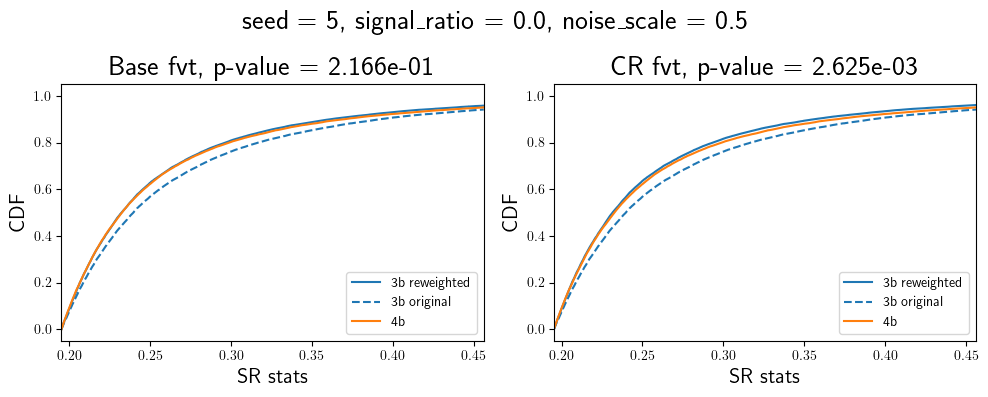

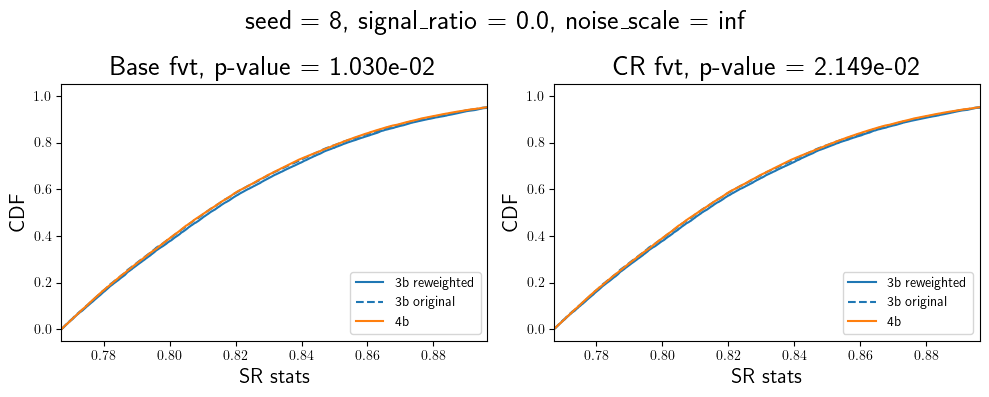

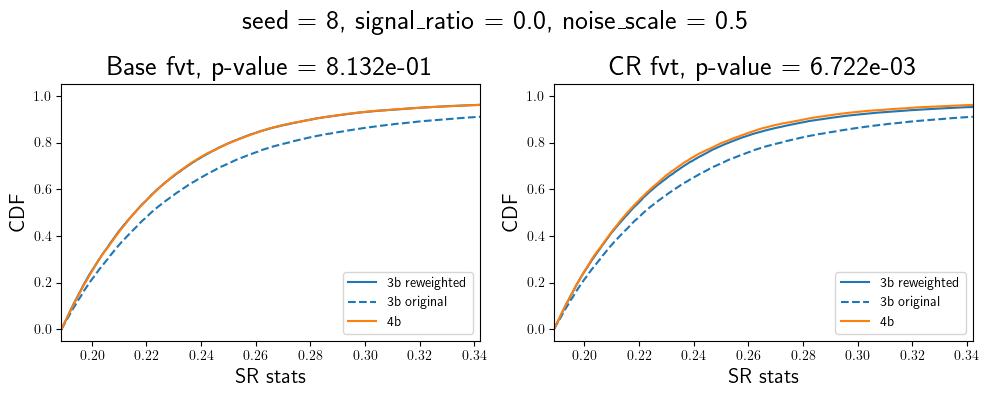

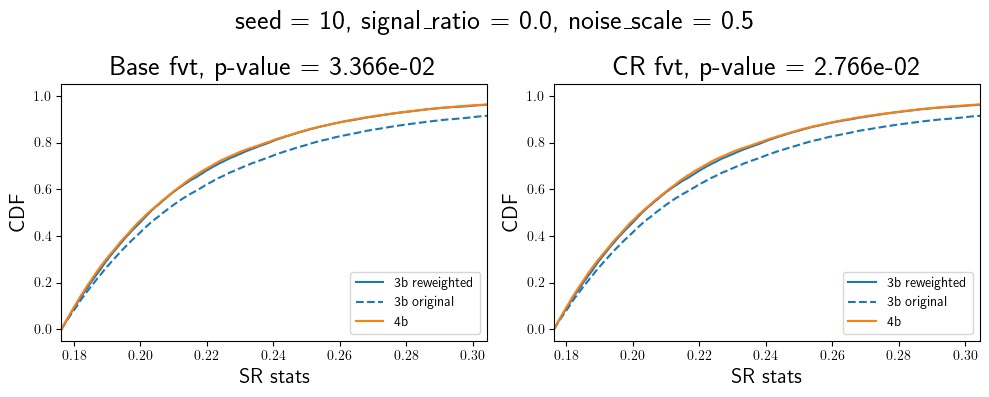

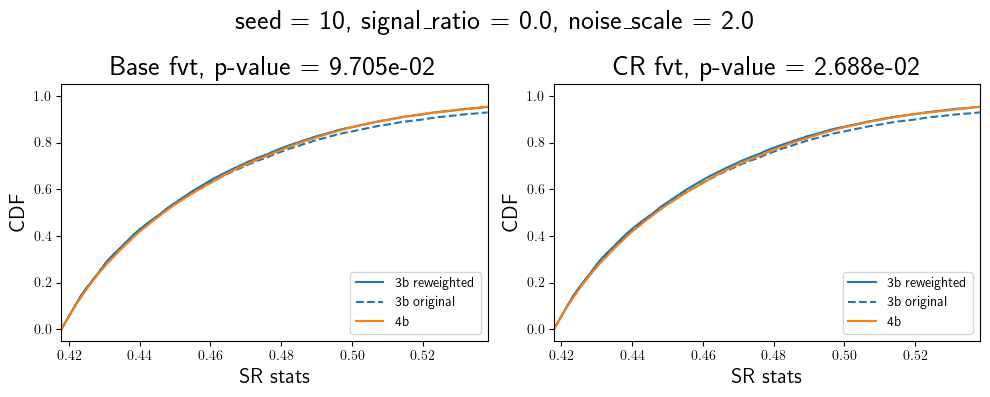

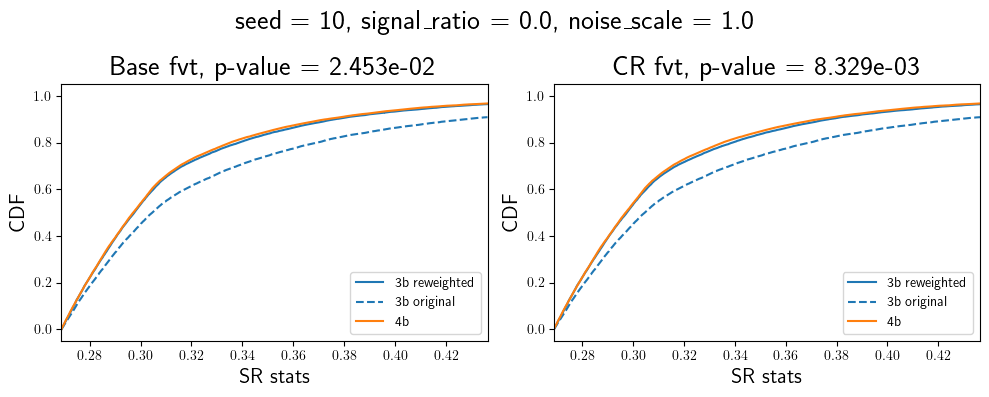

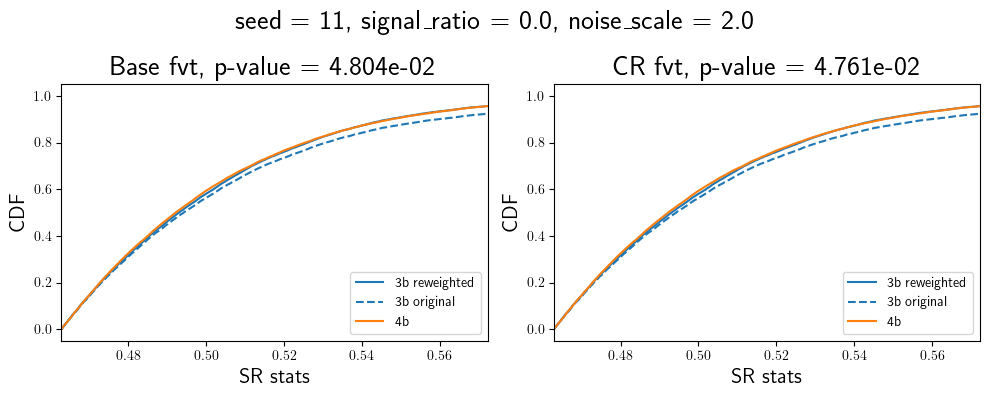

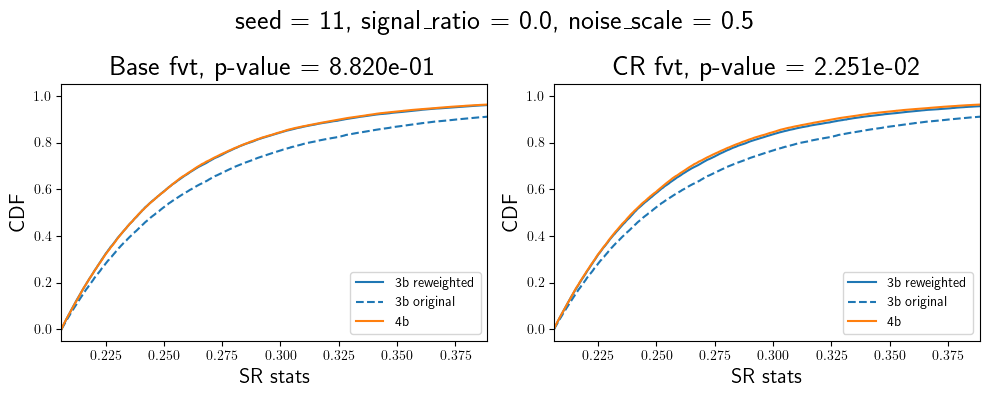

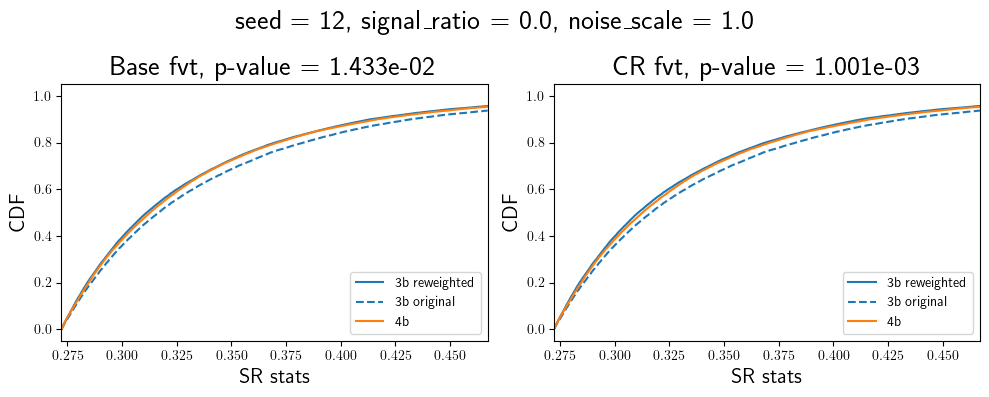

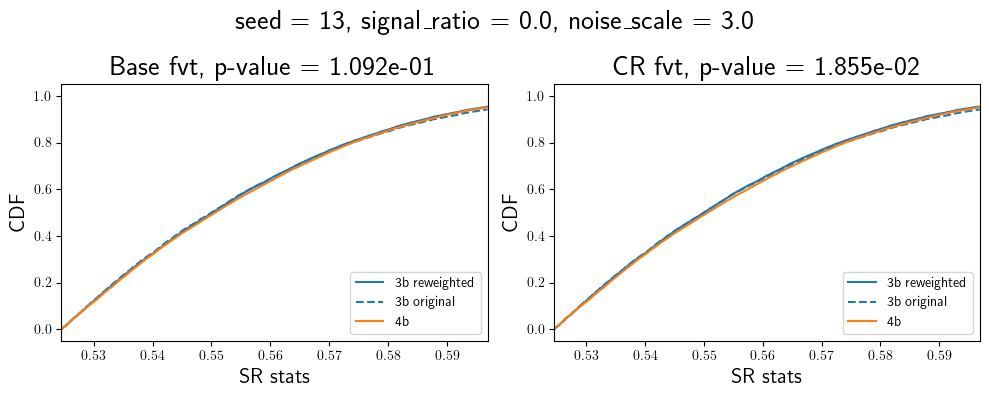

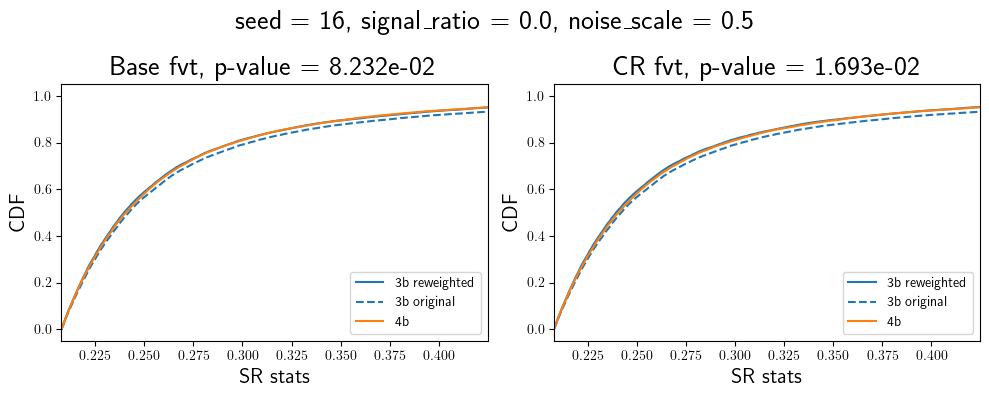

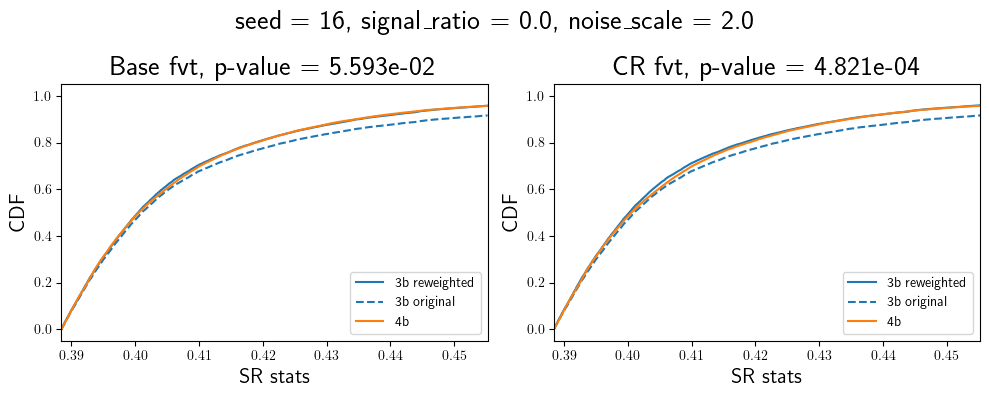

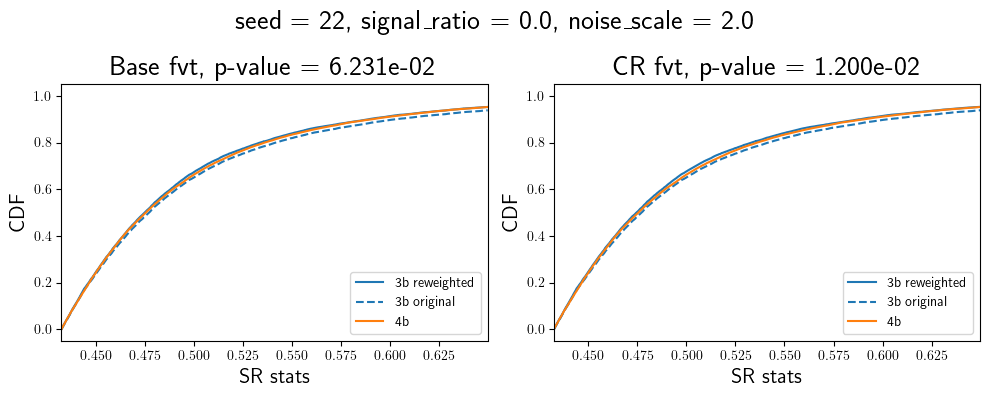

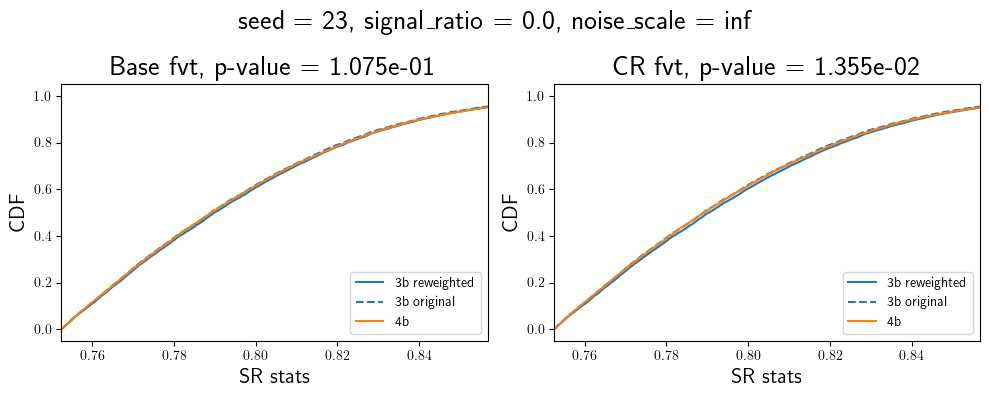

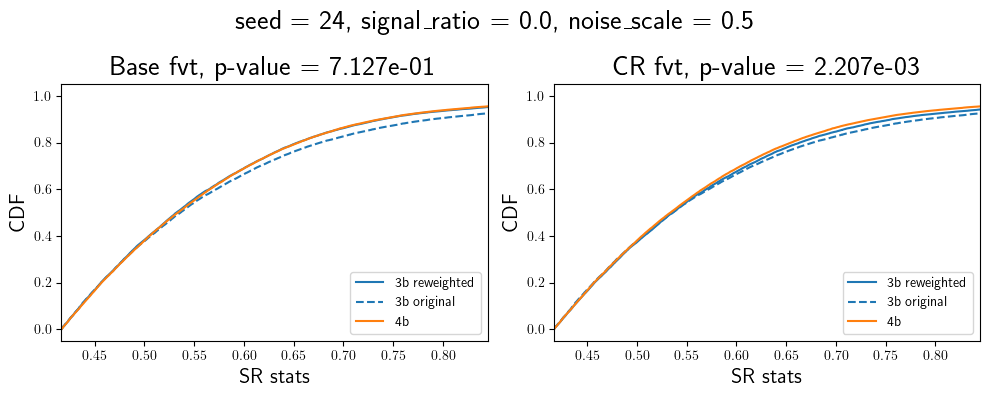

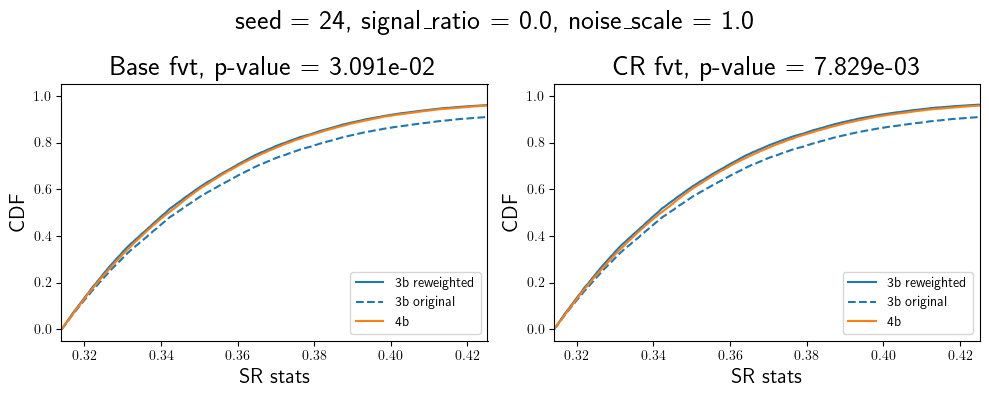

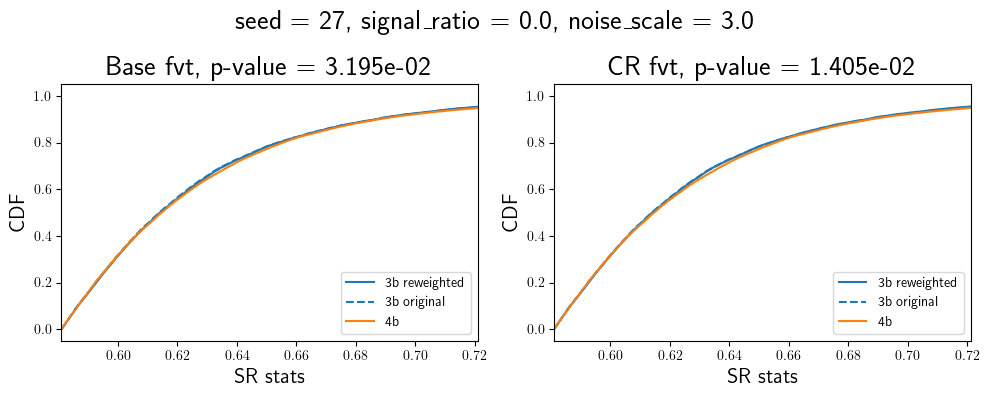

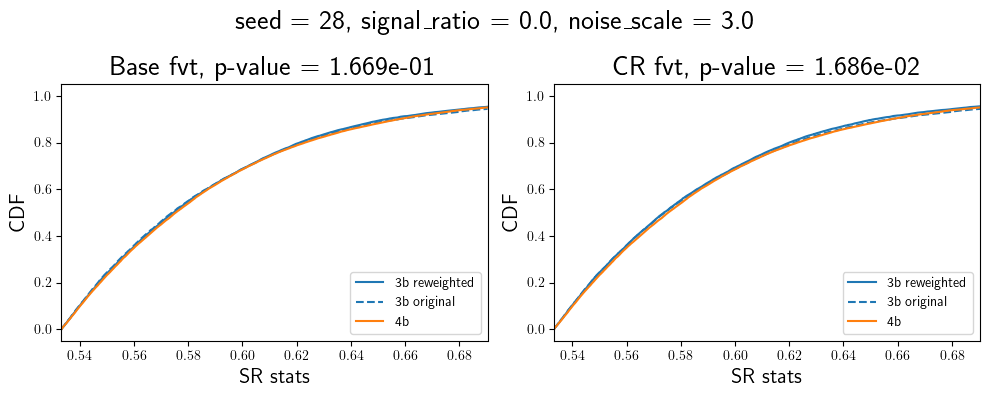

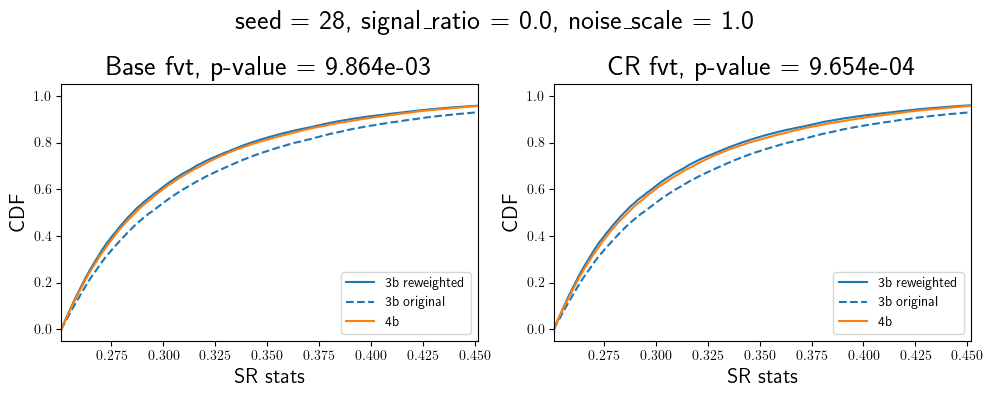

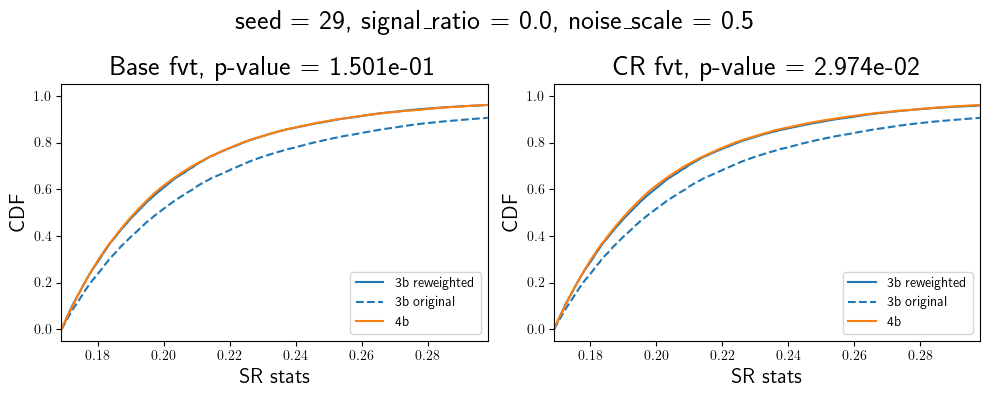

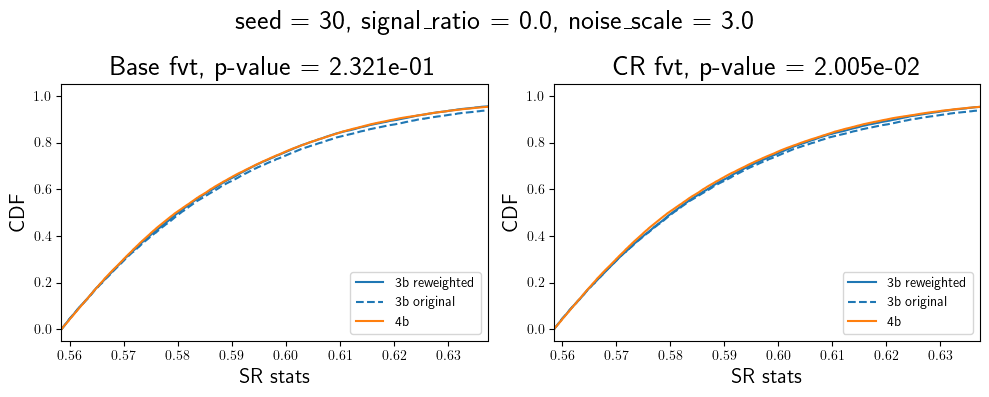

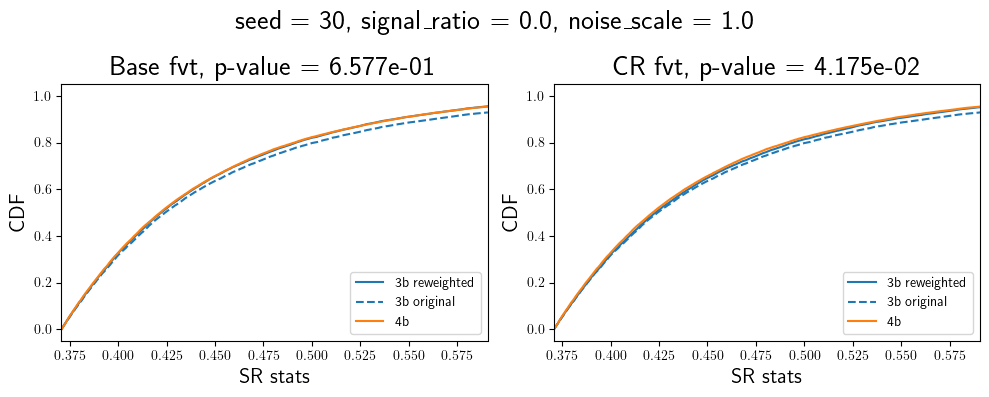

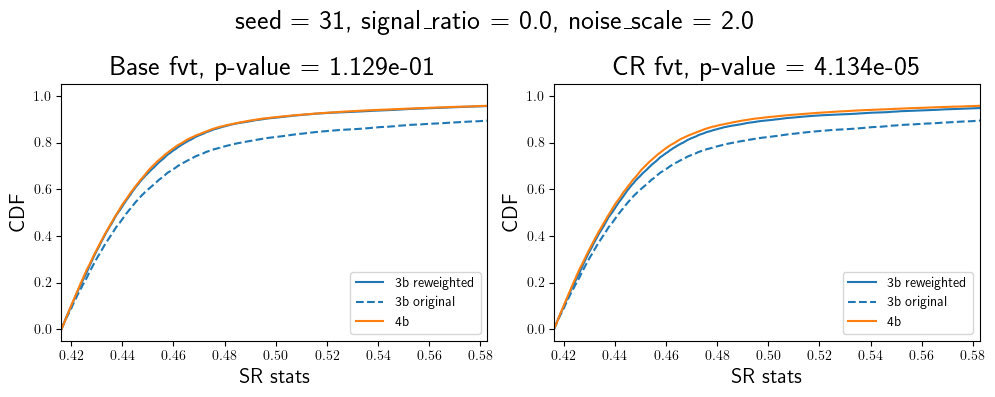

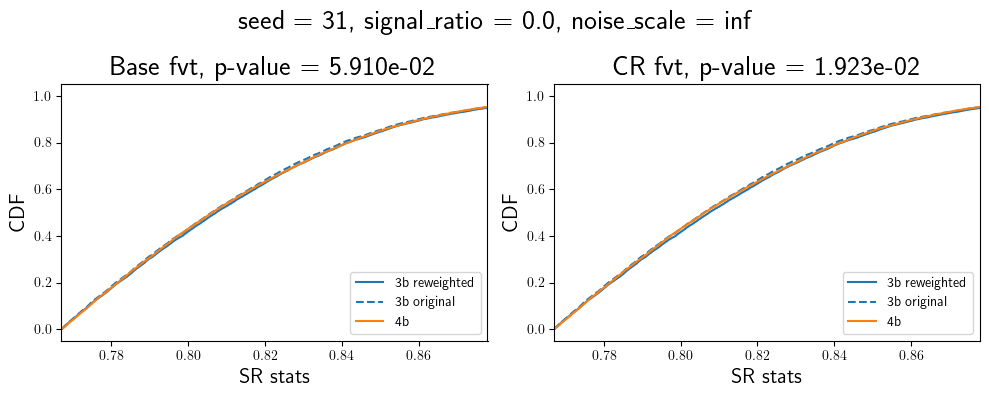

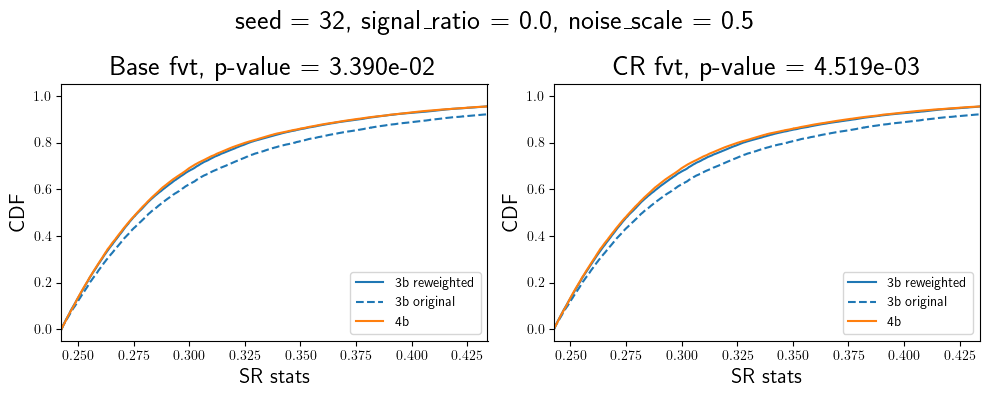

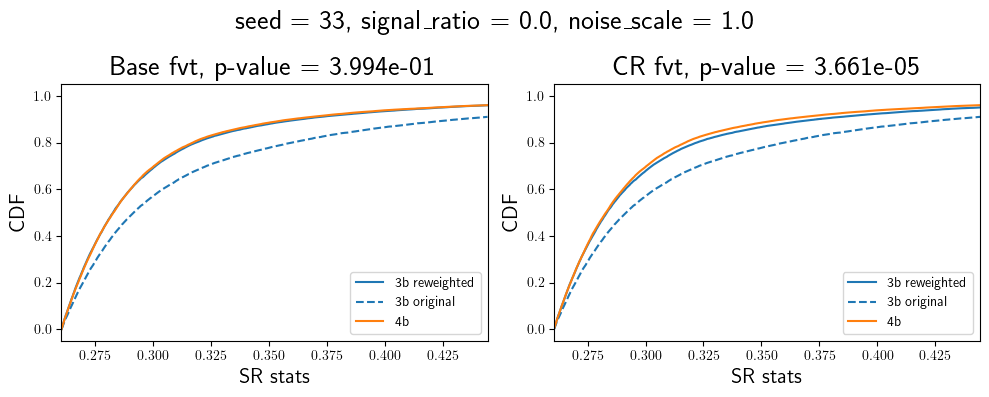

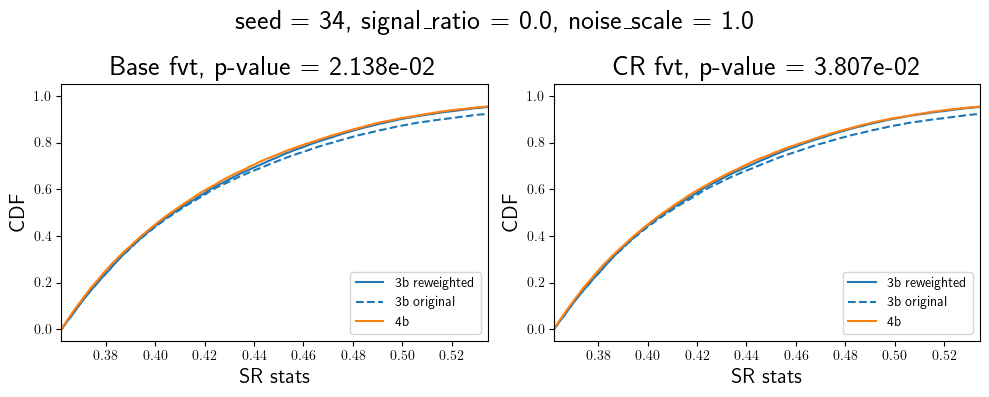

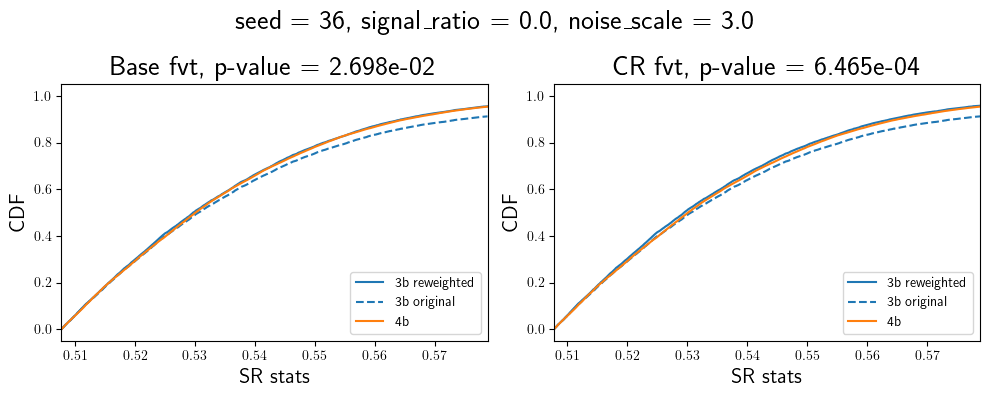

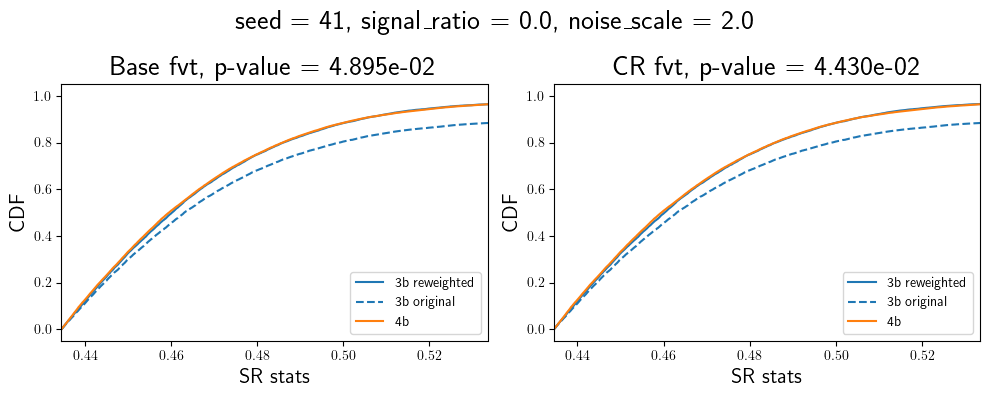

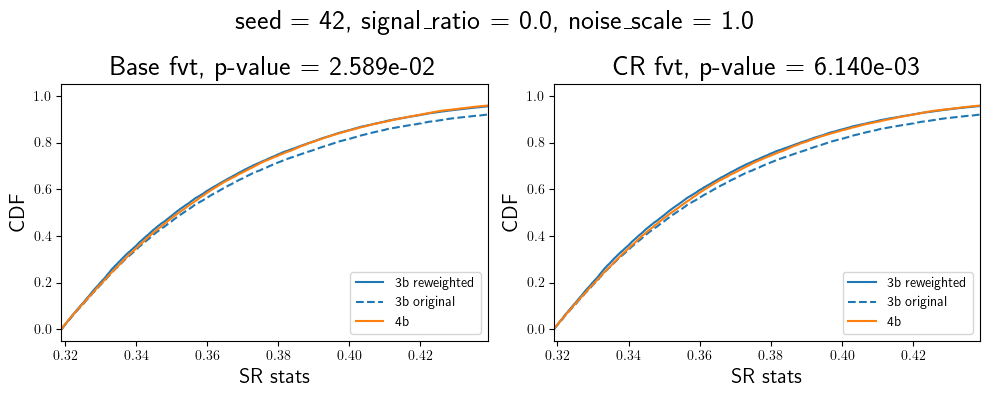

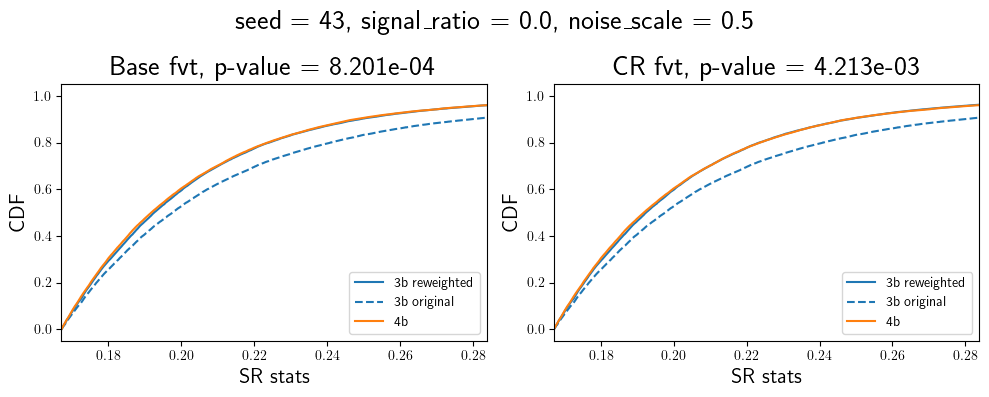

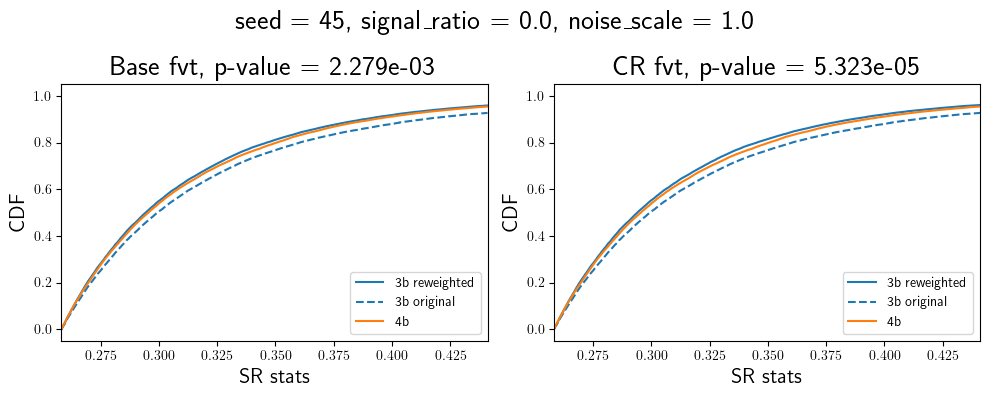

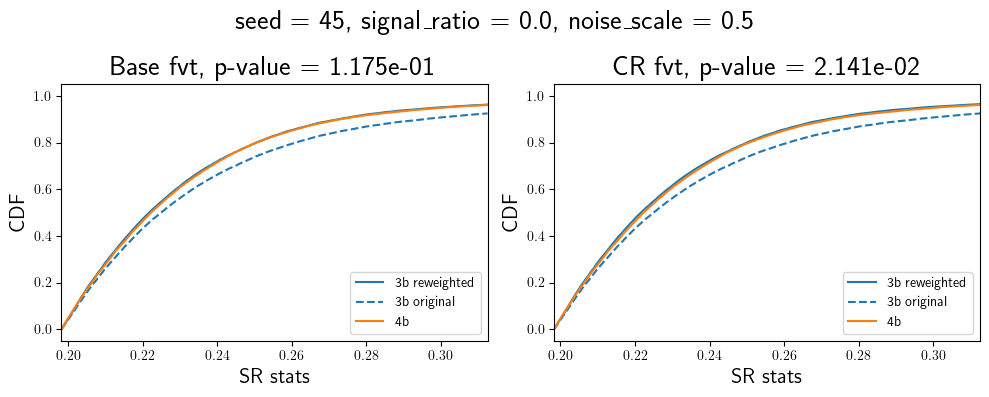

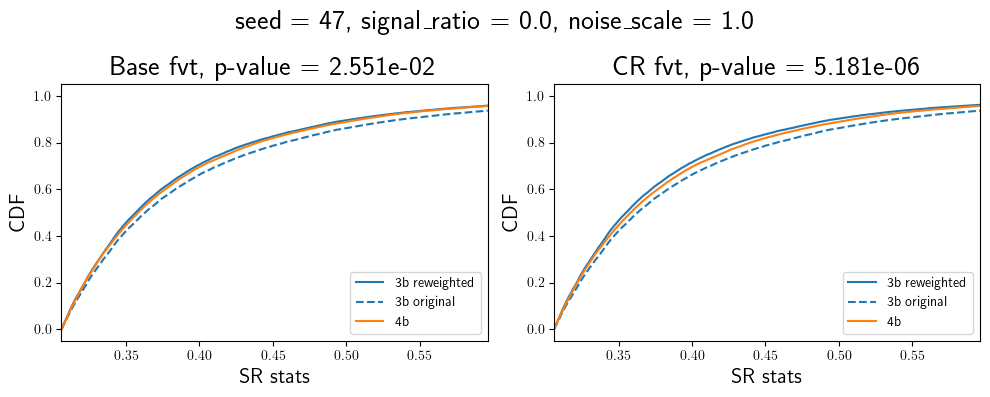

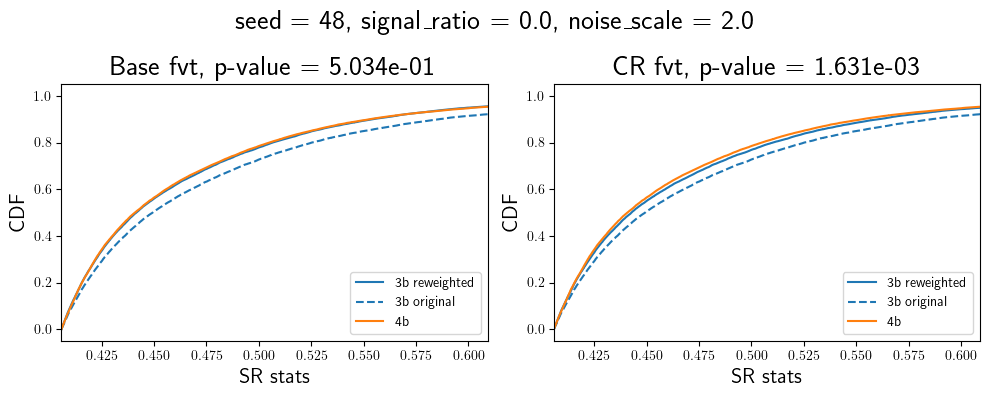

In [4]:
from plots import plot_cdf
from ks_test import max_cdf_diff
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio, 
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

max_diff_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
tmp_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
p_value_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    base_fvt_score_tst_mean = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        "mean",
        "fvt",
    )[1]
    base_fvt_score_tst_mean = 1 - 1 / (1 + np.exp(base_fvt_score_tst_mean))
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    base_fvt_score_tst_SR = base_fvt_score_tst_mean[SR_idx]
    reweights_tst_SR_base = base_fvt_score_tst_SR / (1 - base_fvt_score_tst_SR)
    rw_tst_SR_base = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR_base * events_tst_SR.weights)
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    # x_stats_SR = get_m4j(events_tst_SR.X_torch)
    x_stats_SR = SR_stats_tst_SR
    
    max_diff_base = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR_base[is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR])
    max_diff = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    
    
    n_SR_4b = np.sum(is_4b_tst_SR)
    n_SR_3b = np.sum(~is_4b_tst_SR)
    tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
    p_value_base = min(1.0, 2 * np.exp(-2 * (max_diff_base / tmp)**2))
    
    # print("max CDF diff with base fvt (mean of 15 ensemble): ", max_diff_base)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value_base)
    
    p_value = min(1.0, 2 * np.exp(-2 * (max_diff / tmp)**2))
    
    # print("max CDF diff with CR fvt (1 ensemble): ", max_diff)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value) 
    
    if p_value < sig_level:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
        fig.suptitle(f"seed = {seed}, signal_ratio = {signal_ratio}, noise_scale = {noise_scale}")
        ax[0].set_title(f"Base fvt, p-value = {p_value_base:.3e}")
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[is_4b_tst_SR], rw_tst_SR_base[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        
        ax[1].set_title(f"CR fvt, p-value = {p_value:.3e}")
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        for a in ax:
            a.legend(loc="lower right")
            a.set_xlabel("SR stats")
            a.set_ylabel("CDF")
            xmin = np.min(x_stats_SR)
            xmax = np.quantile(x_stats_SR, 0.95)
            a.set_xlim(xmin, xmax)
        
        plt.tight_layout()
        plt.show()
    
    max_diff_list[noise_scale]["base"].append(max_diff_base)
    max_diff_list[noise_scale]["CR"].append(max_diff)
    tmp_list[noise_scale]["base"].append(tmp)
    tmp_list[noise_scale]["CR"].append(tmp)
    p_value_list[noise_scale]["base"].append(p_value_base)
    p_value_list[noise_scale]["CR"].append(p_value)
    
tmp_data = {"max_cdf_diff": max_diff_list, "tmp": tmp_list, "p_value": p_value_list}
pickle.dump(tmp_data, open("./data/tmp/max_cdf_data.pkl", "wb"))

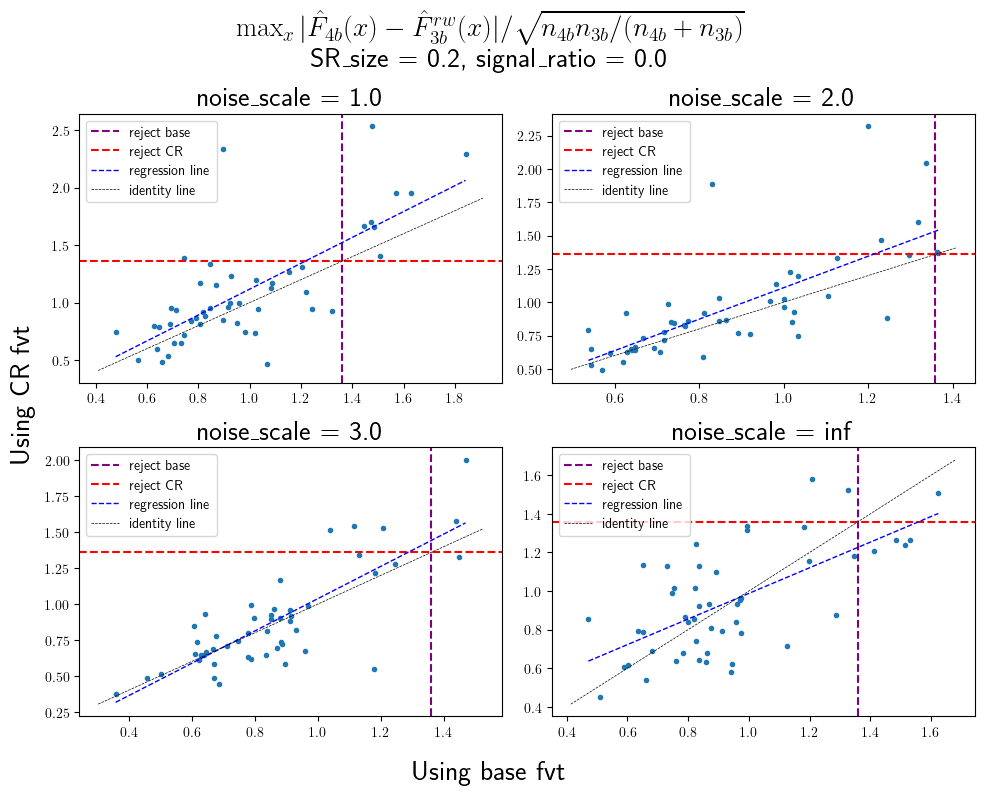

In [ ]:
from scipy import stats

signal_ratio = 0.0
tmp_data = pickle.load(open("./data/tmp/max_cdf_data_null.pkl", "rb"))

SR_size = 0.05

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle(r"$\max_x |\hat{F}_{4b}(x) - \hat{F}_{3b}^{rw}(x)| / \sqrt{n_{4b} n_{3b} / (n_{4b} + n_{3b})}$" + 
             f"\nSR_size = {SR_size}, signal_ratio = {signal_ratio}")
fig.supxlabel("Using base fvt")
fig.supylabel("Using CR fvt")

for i, noise_scale in enumerate([1.0, 2.0, 3.0, np.inf]):
    ax = axs.flatten()[i]
    ax.set_title(f"noise_scale = {noise_scale}")
    plot_x = np.array(tmp_data["max_cdf_diff"][noise_scale]["base"]) / np.array(tmp_data["tmp"][noise_scale]["base"])
    plot_y = np.array(tmp_data["max_cdf_diff"][noise_scale]["CR"]) / np.array(tmp_data["tmp"][noise_scale]["CR"])
    ax.plot(plot_x, plot_y, "o")

    ax.axvline(x=c_alpha(sig_level), color="purple", linestyle="--", label="reject base")
    ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label="reject CR")
    # plot regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(plot_x, plot_y)
    ax.plot([np.min(plot_x), np.max(plot_x)], 
            [slope * np.min(plot_x) + intercept, slope * np.max(plot_x) + intercept], 
            "b--", linewidth=1, label="regression line")
    xmin = ax.get_xlim()[0]
    xmax = ax.get_xlim()[1]
    ymin = ax.get_ylim()[0]
    ymax = ax.get_ylim()[1]
    ax.plot([xmin, xmax], [xmin, xmax], "--", color="black", linewidth=0.5, label="identity line")
    ax.legend()
plt.tight_layout()
plt.show()

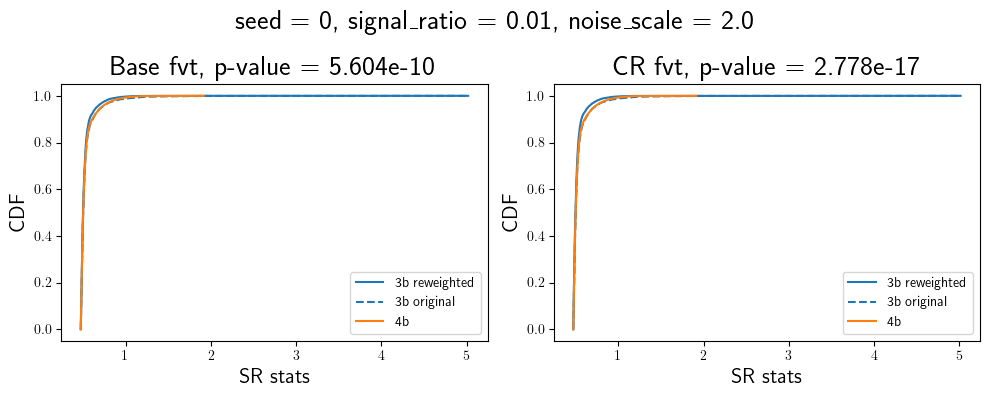

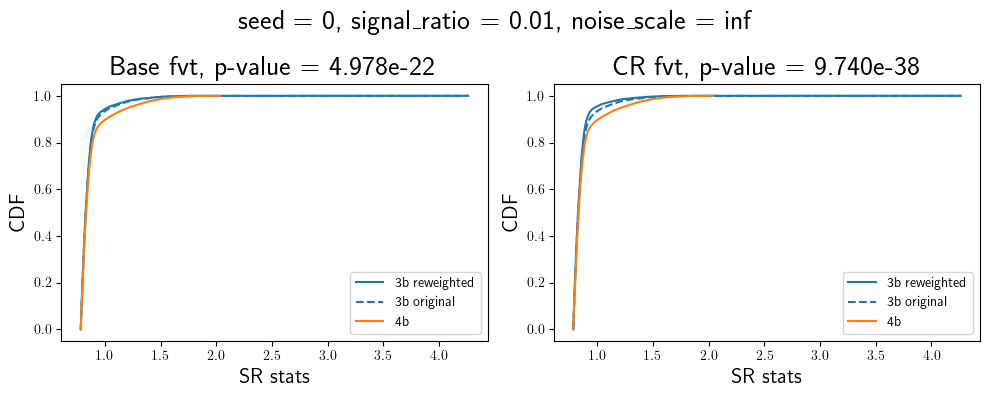

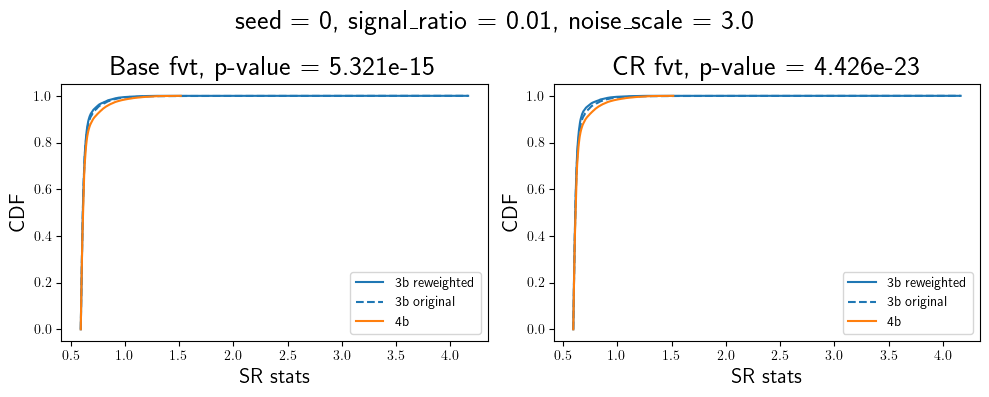

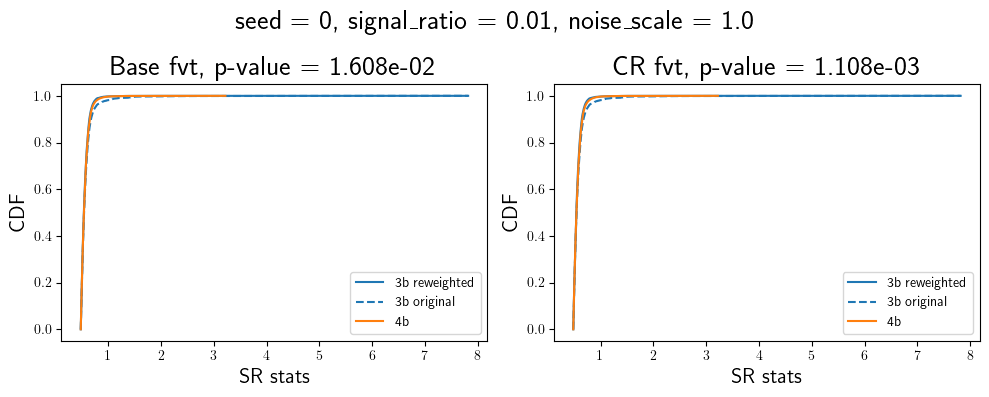

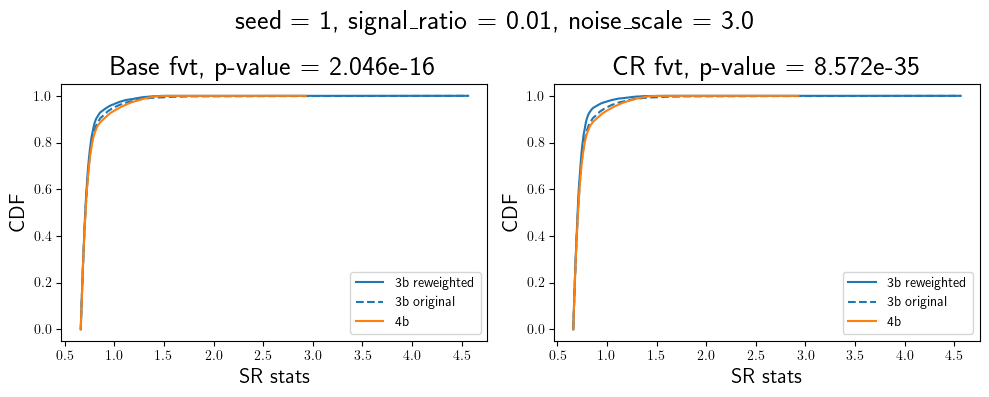

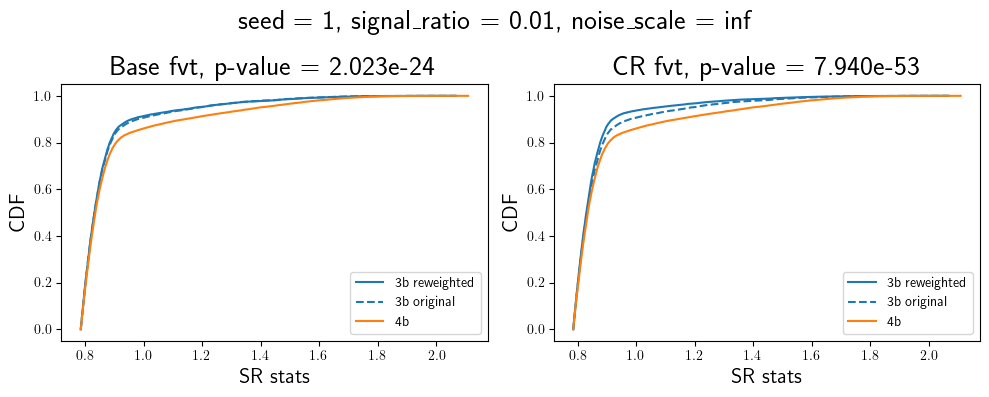

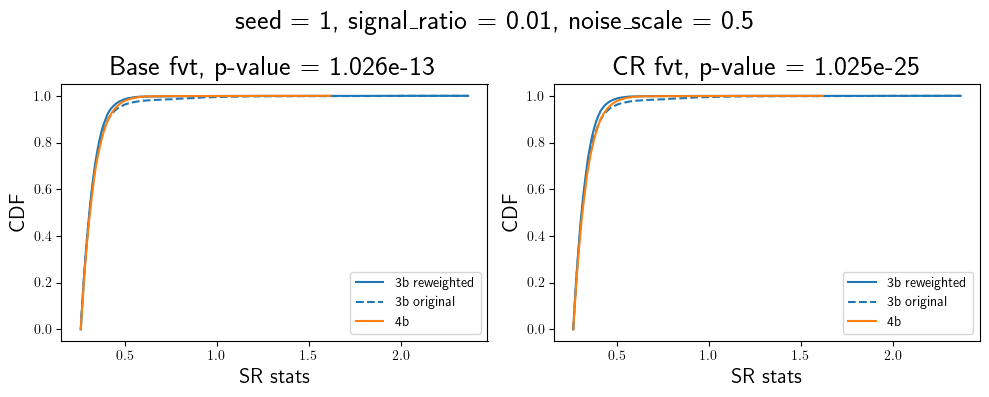

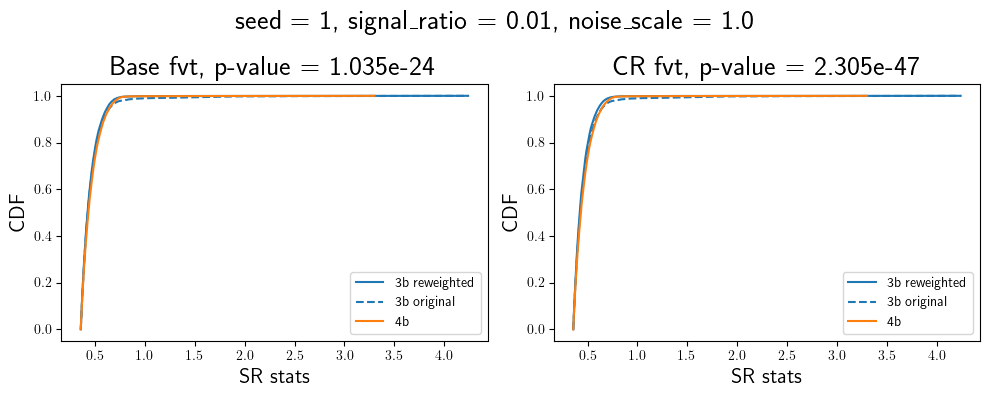

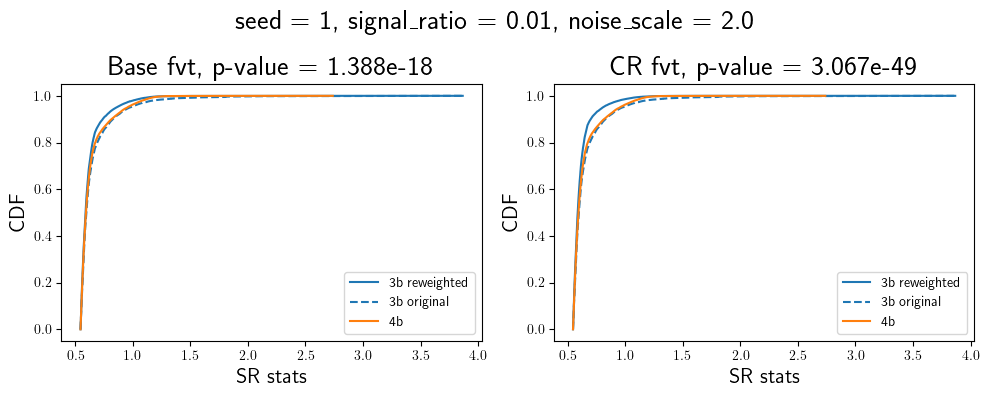

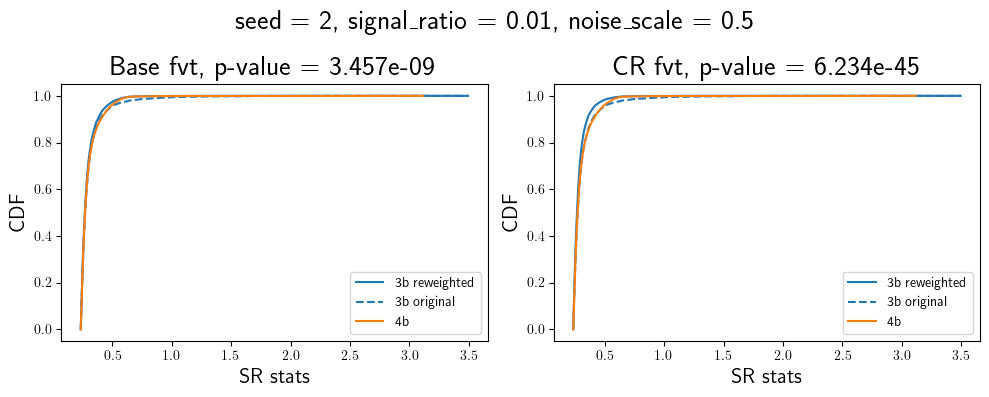

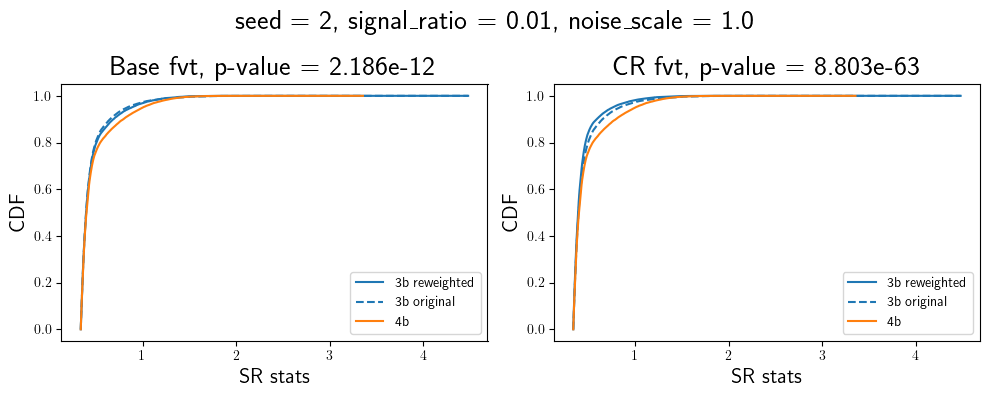

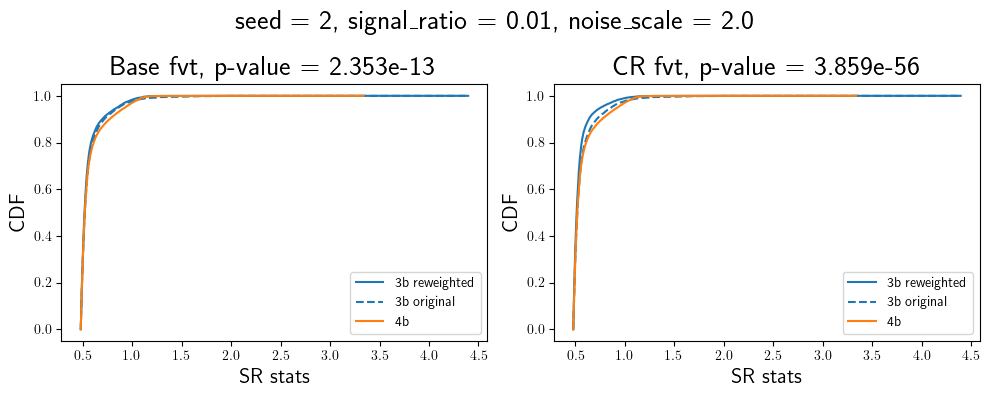

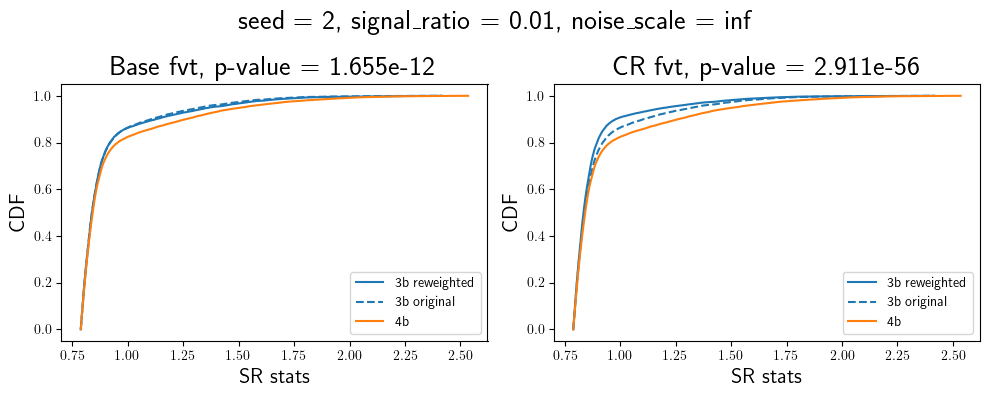

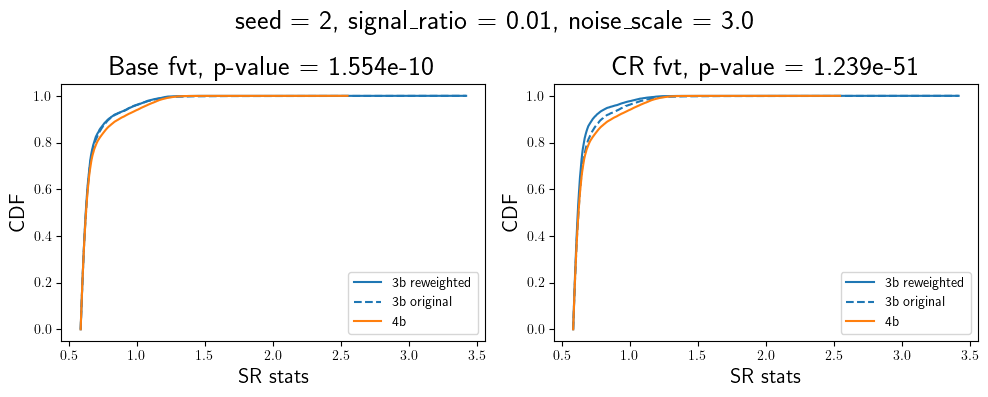

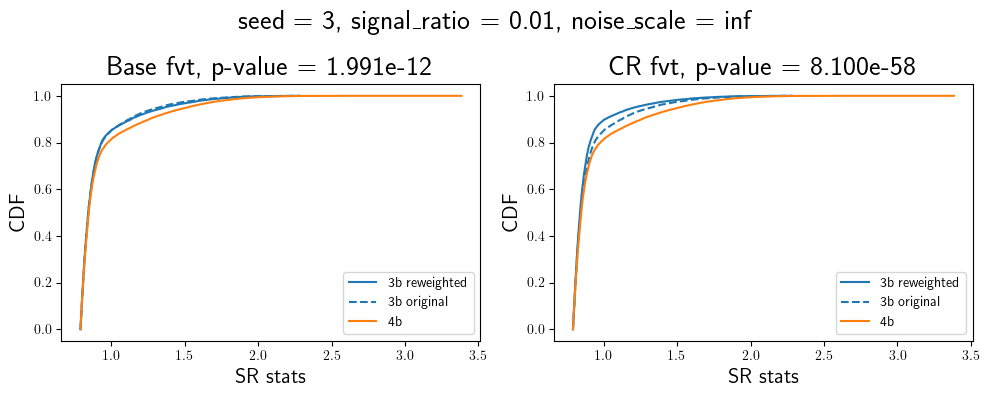

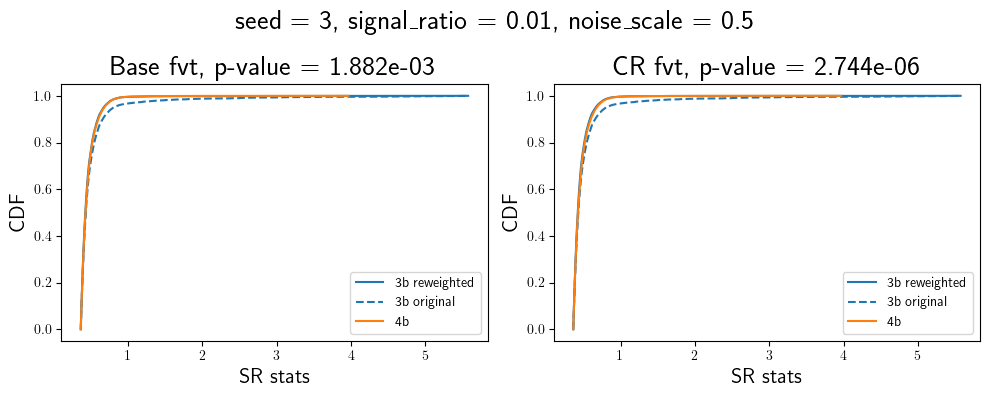

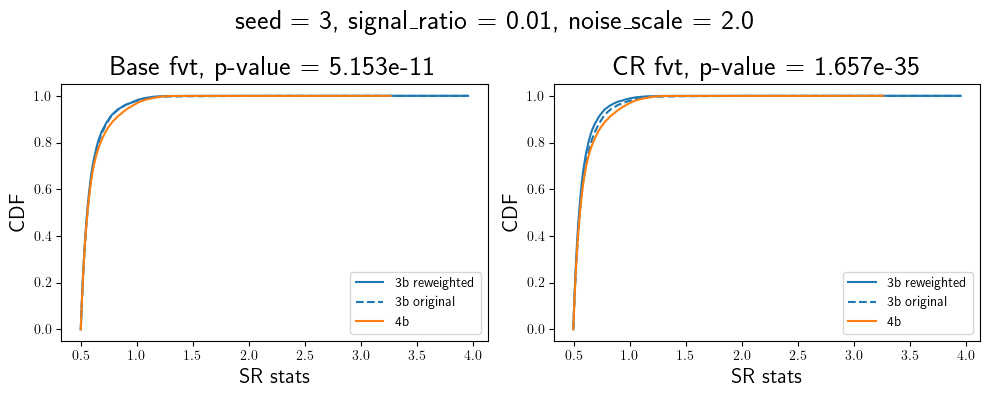

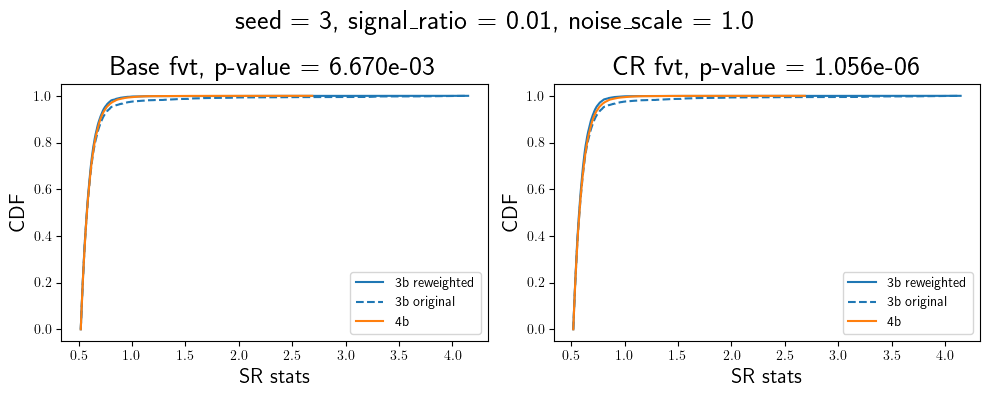

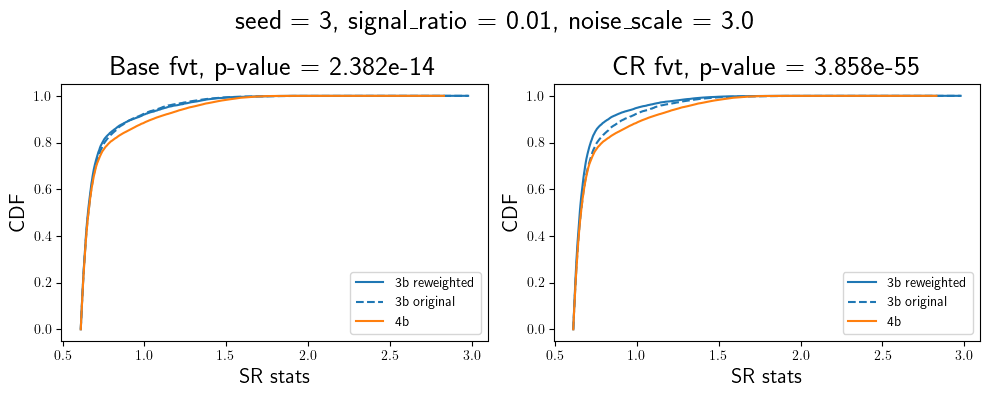

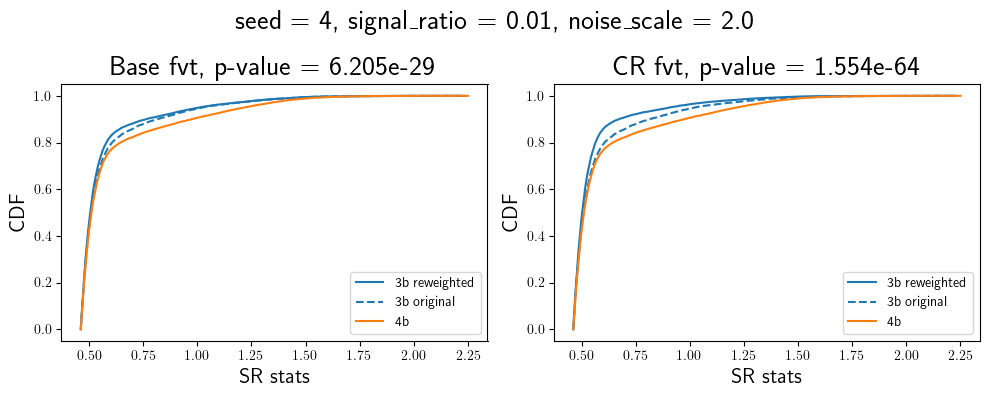

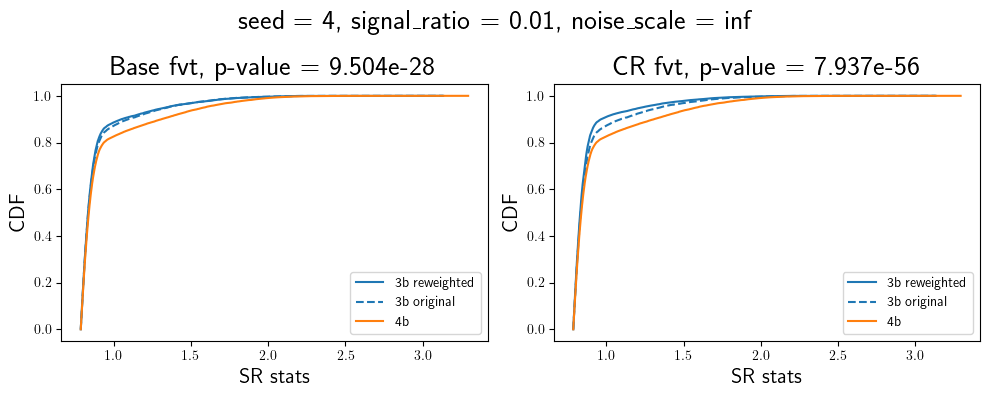

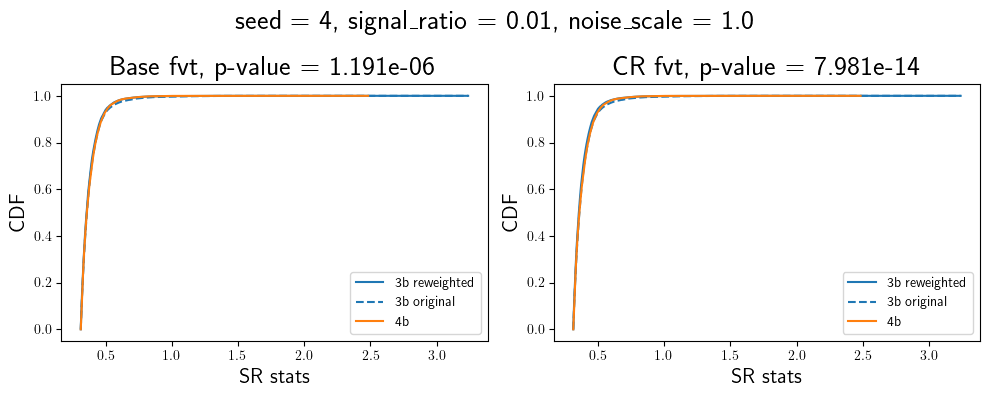

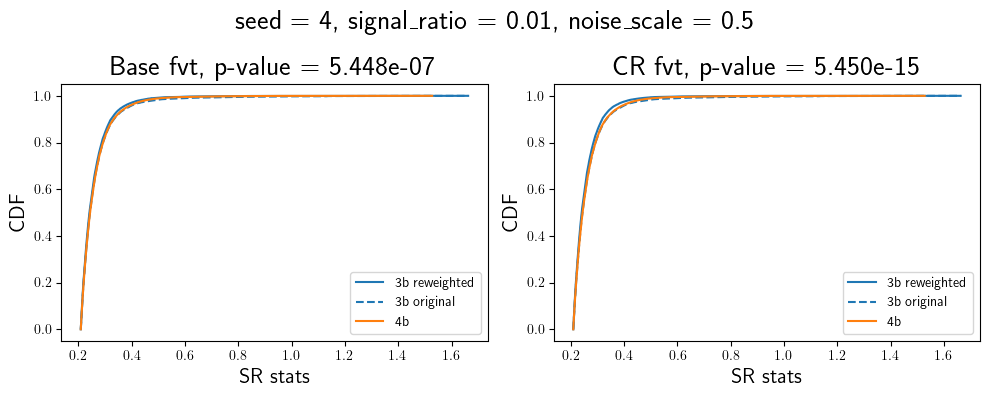

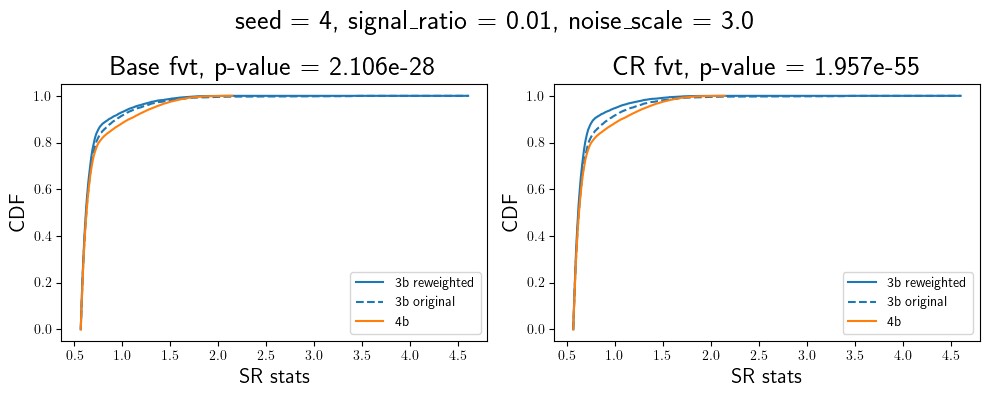

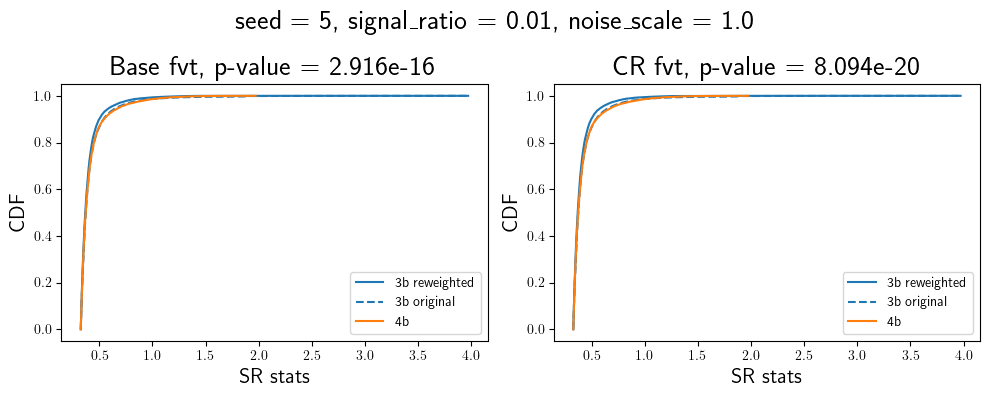

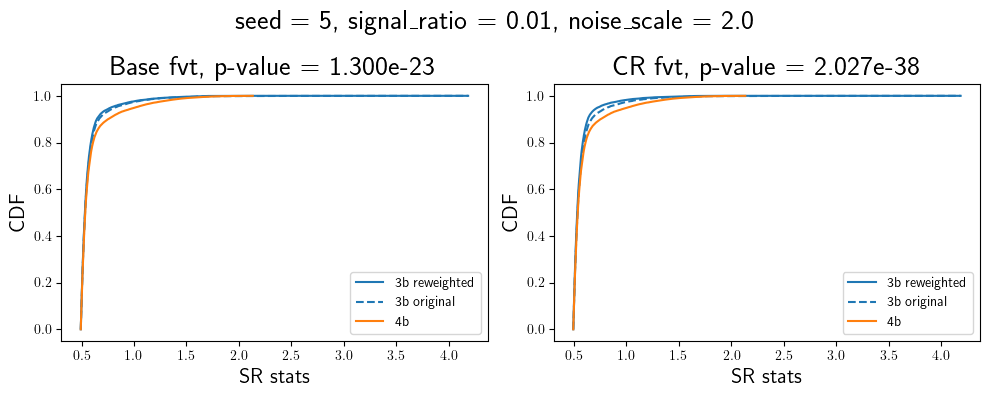

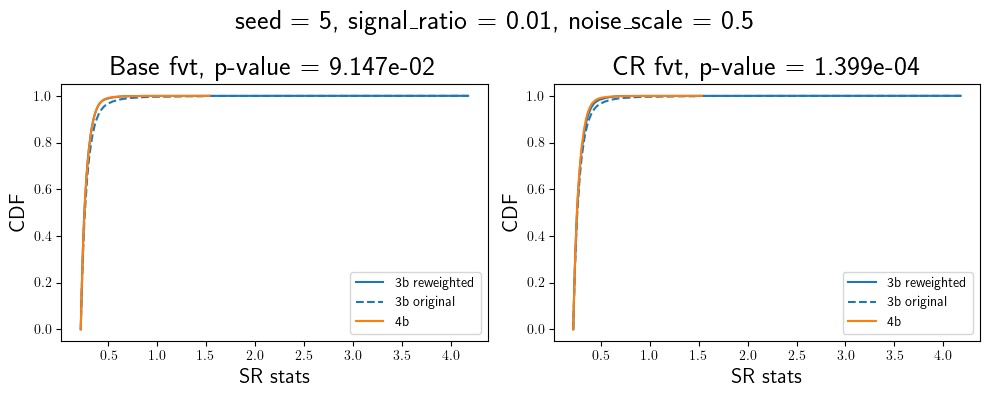

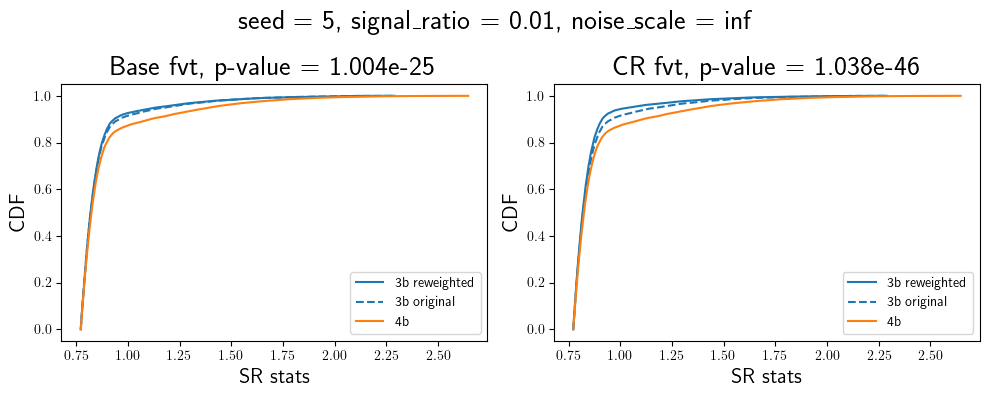

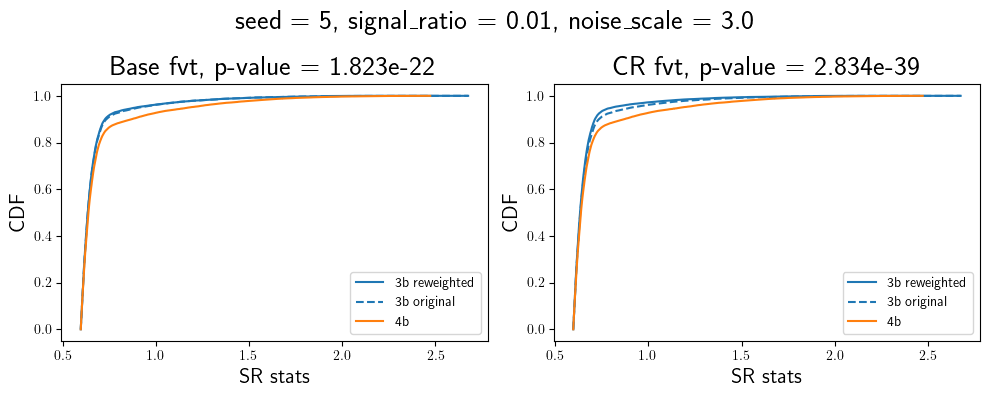

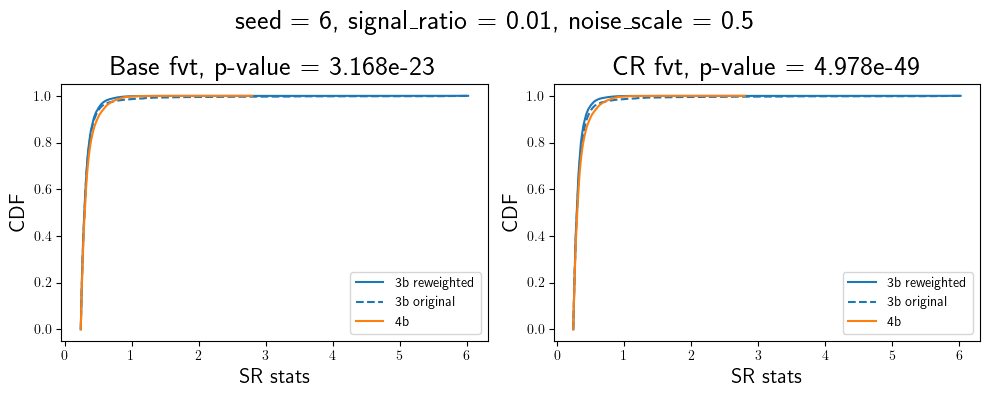

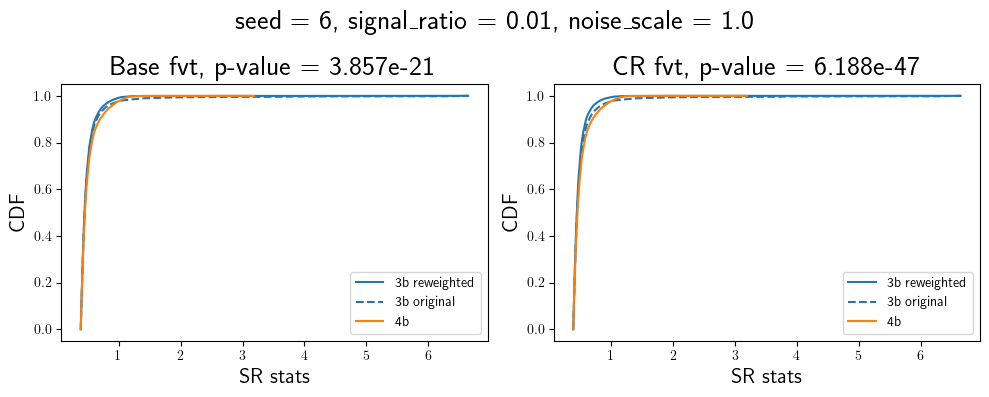

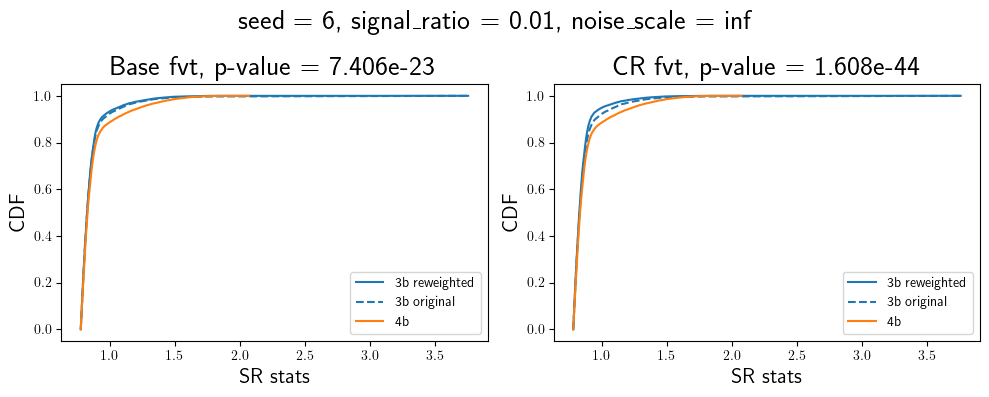

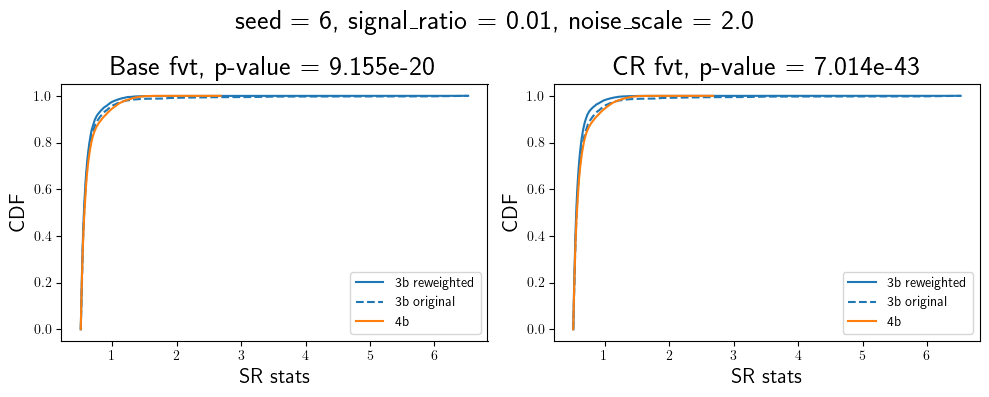

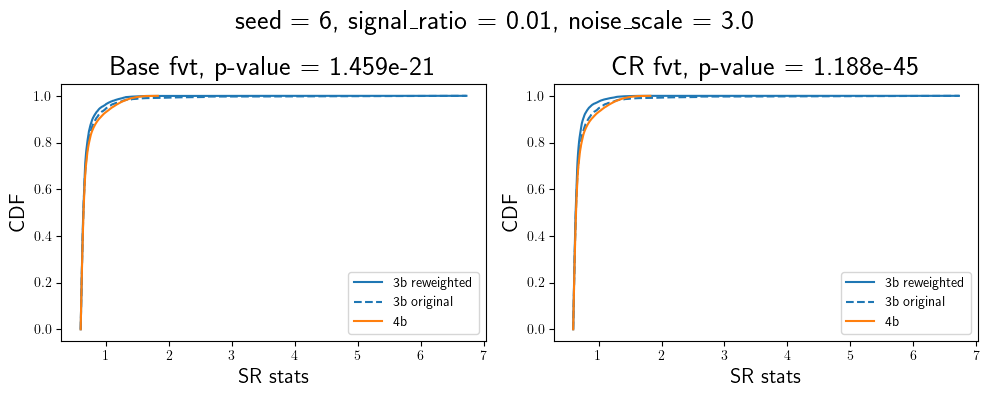

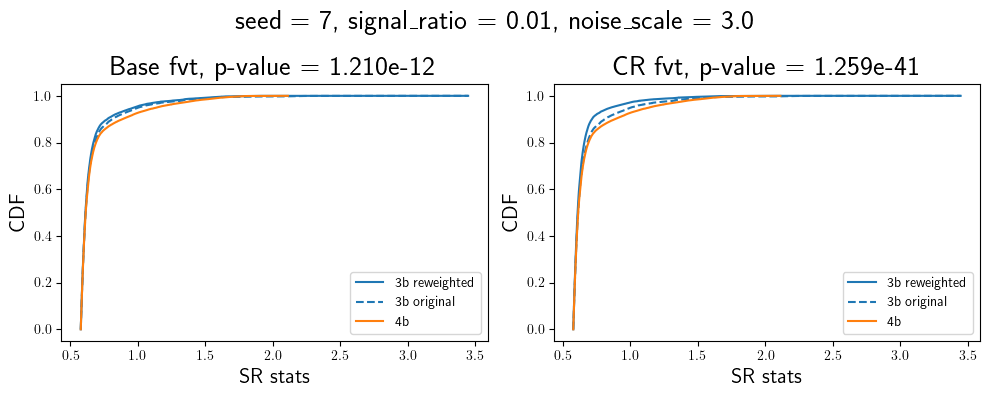

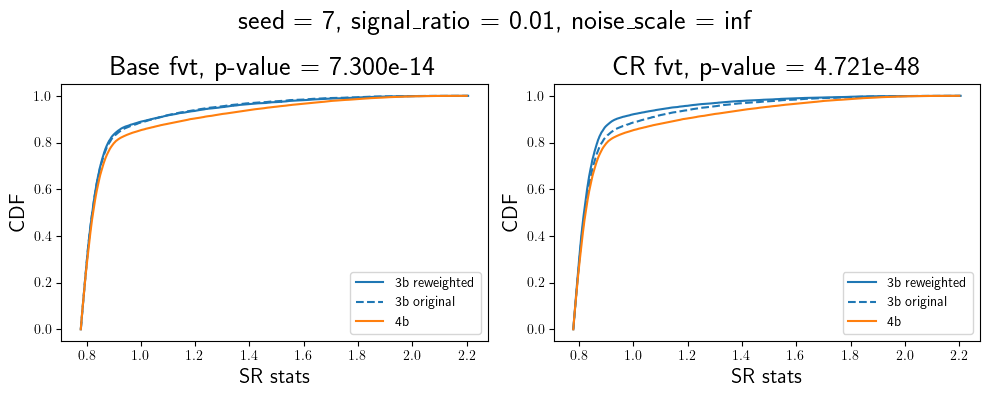

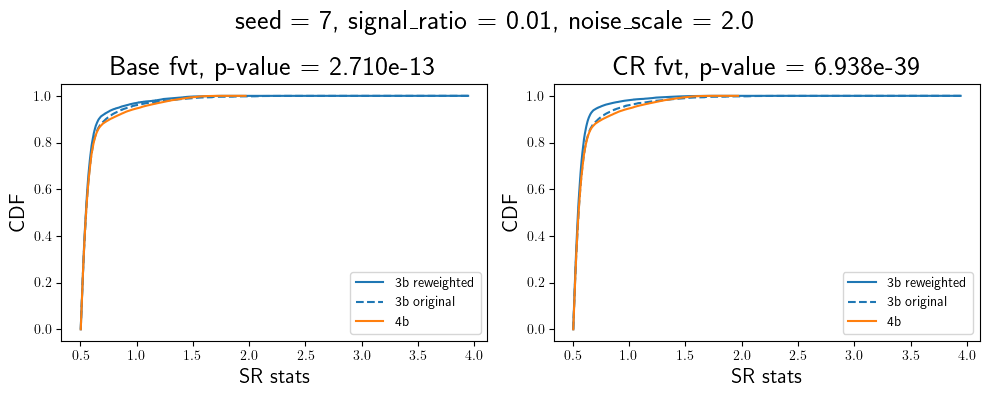

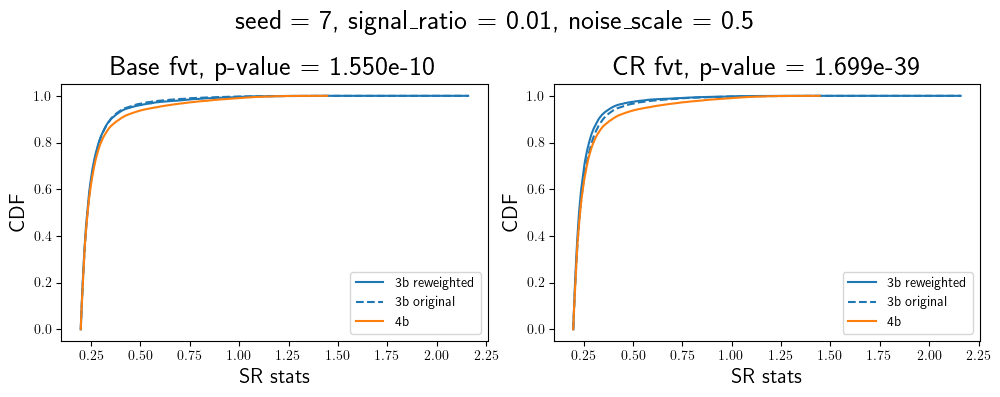

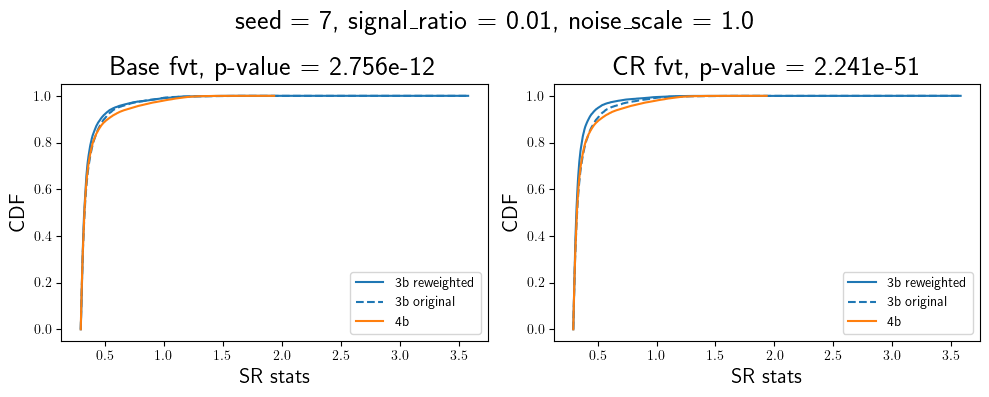

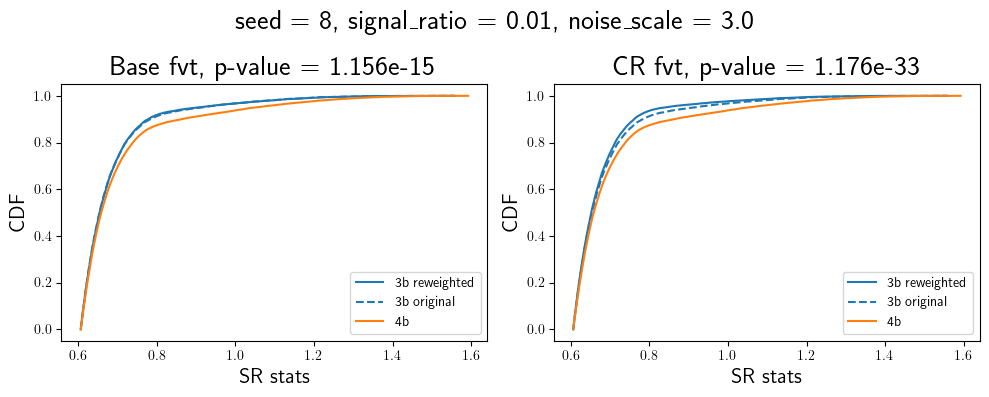

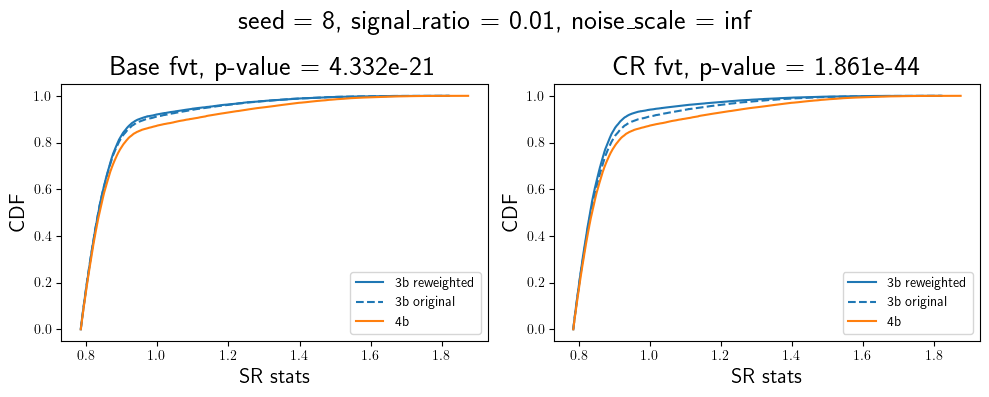

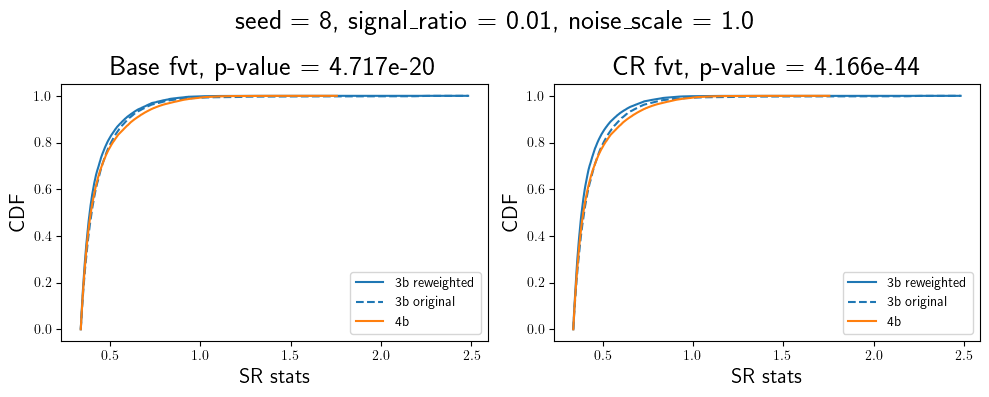

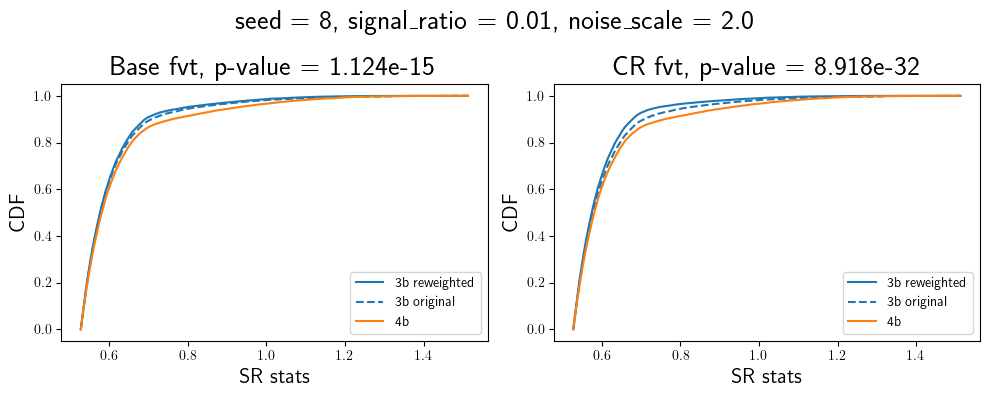

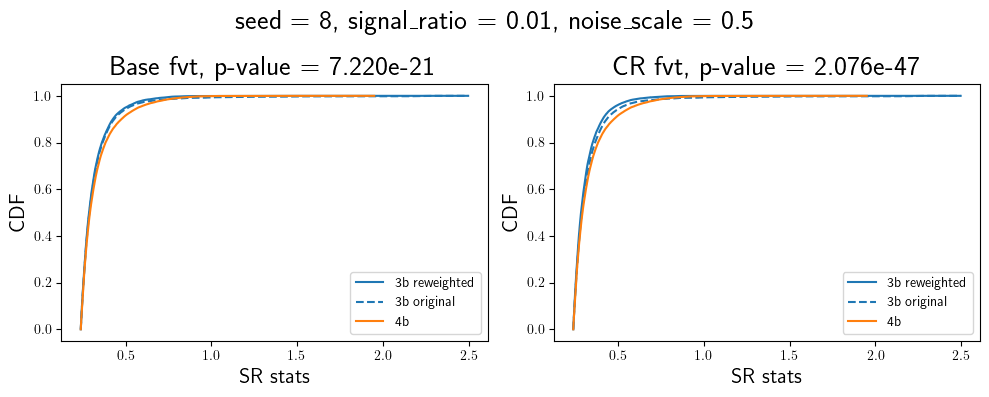

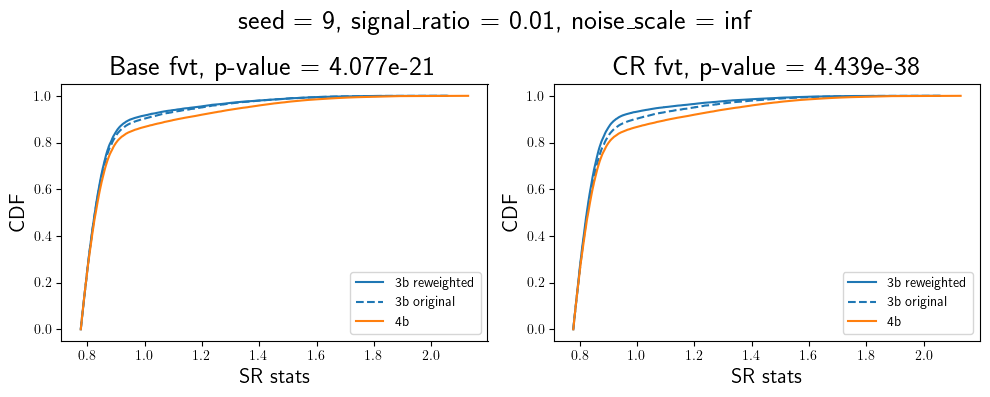

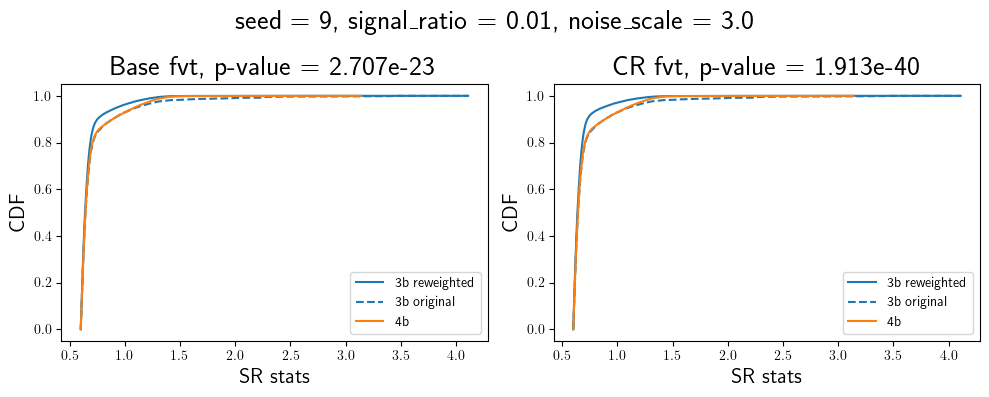

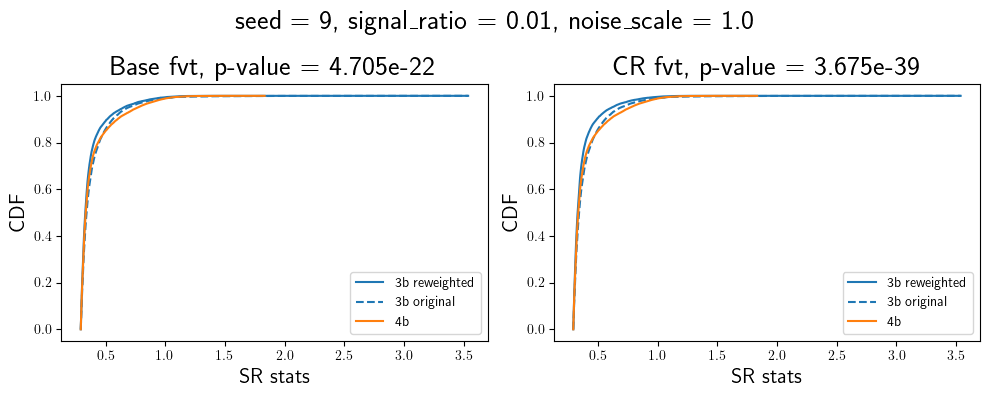

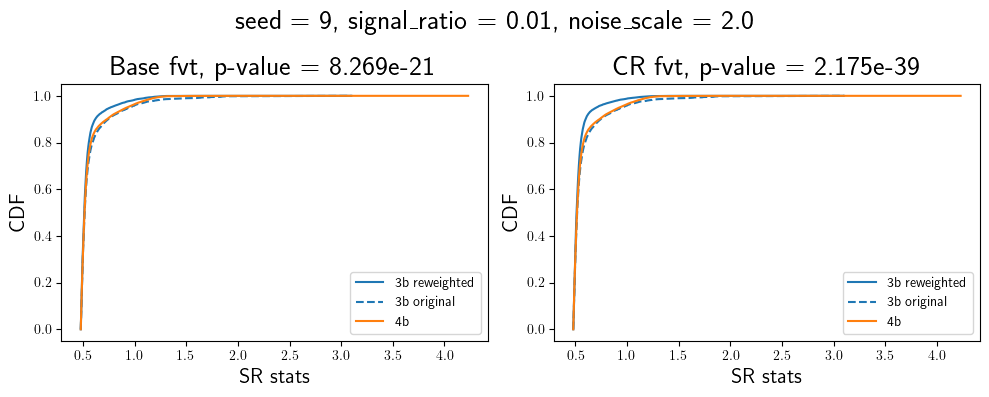

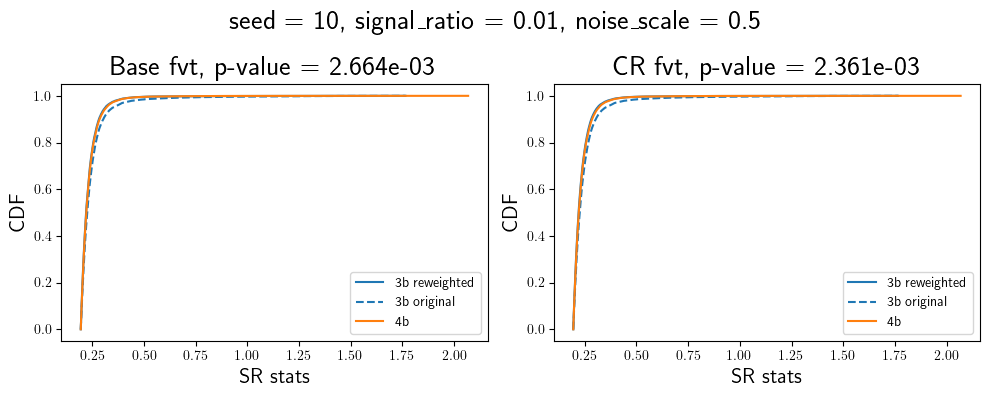

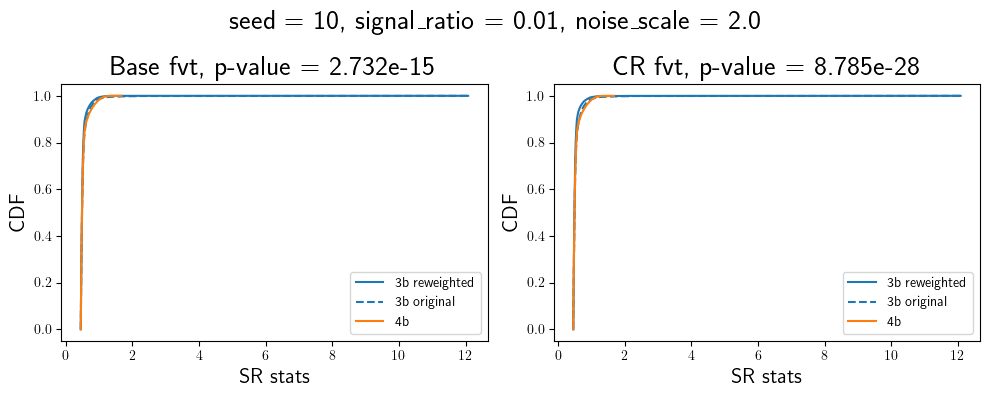

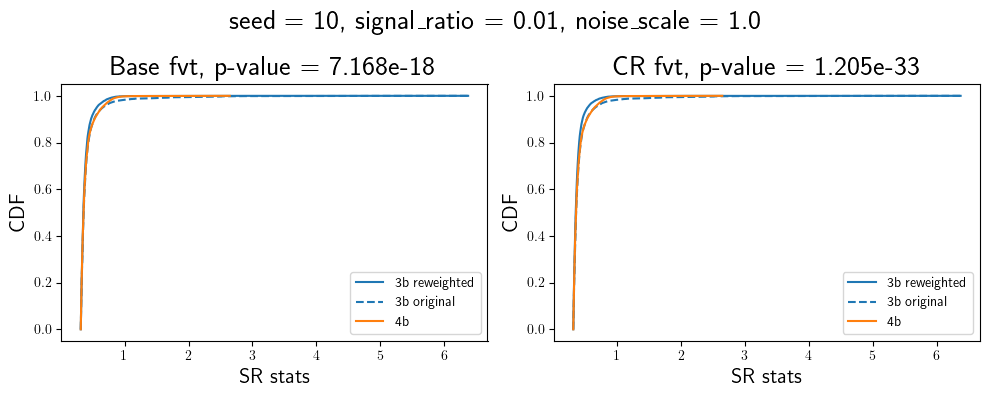

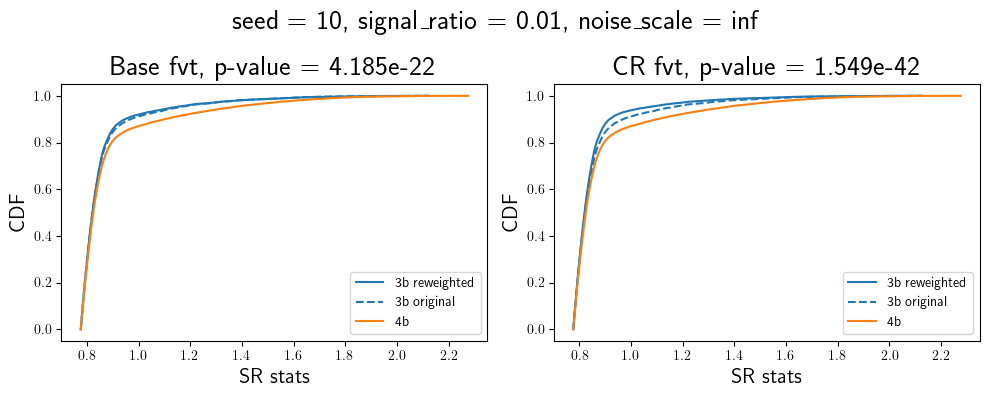

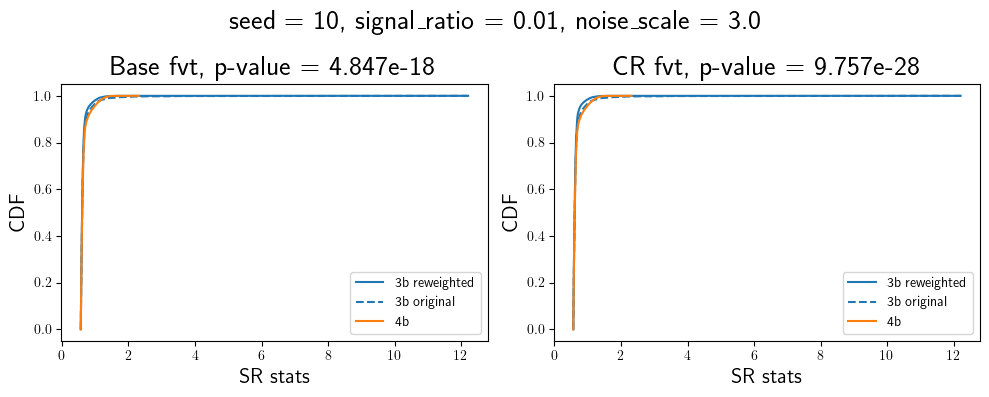

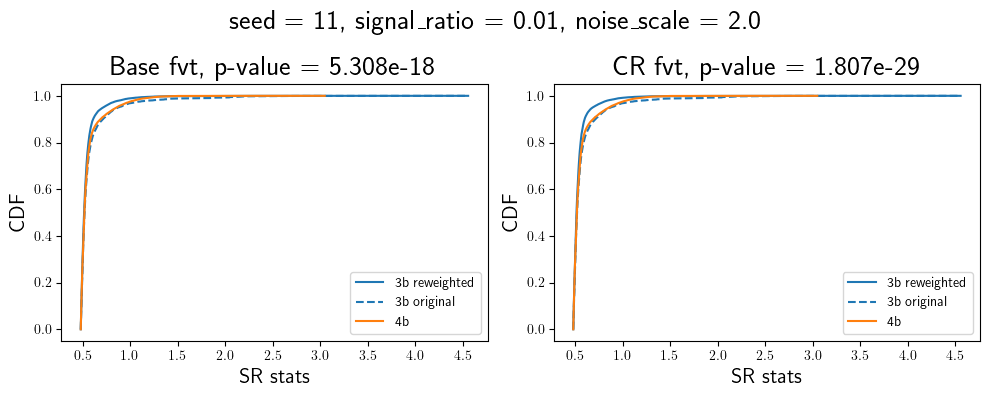

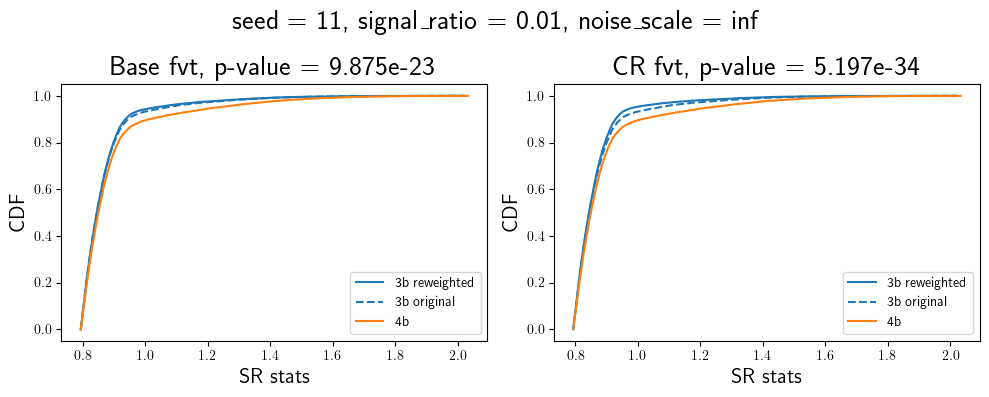

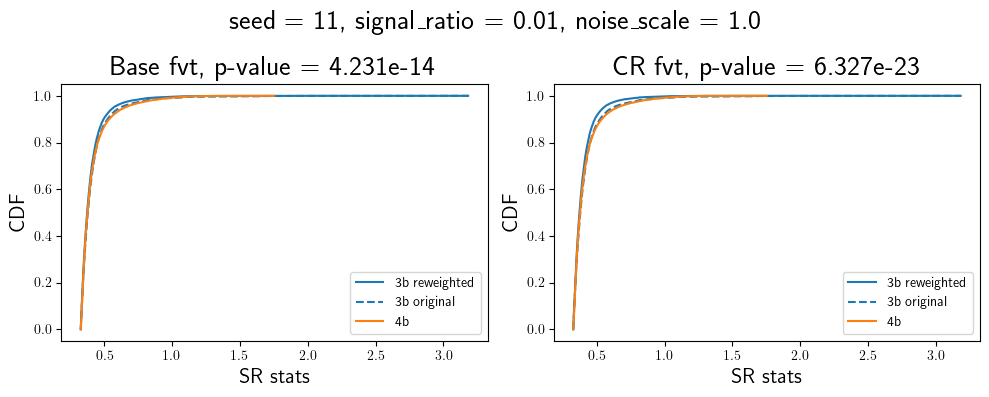

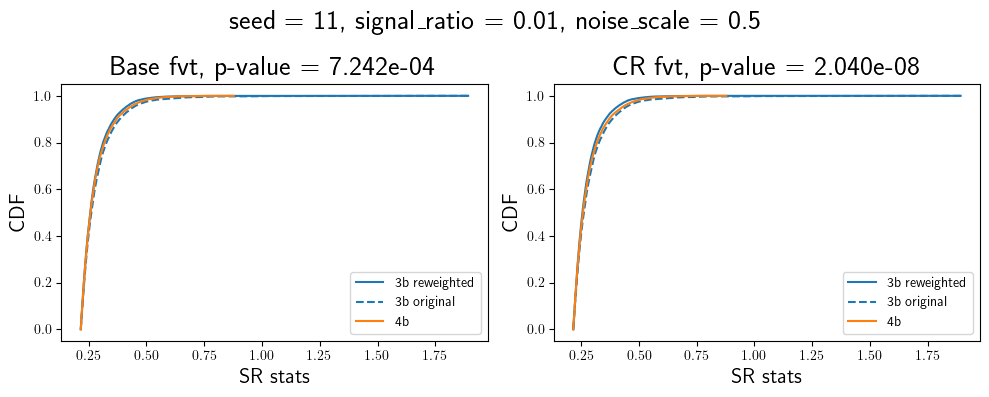

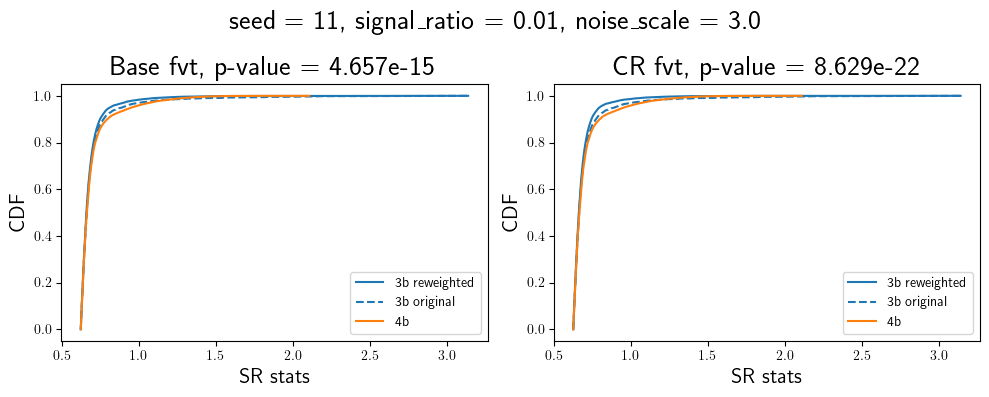

In [ ]:
from plots import plot_cdf
from ks_test import max_cdf_diff
from ancillary_features import get_m4j

signal_ratio = 0.01
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio, 
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

max_diff_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
tmp_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
p_value_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    base_fvt_score_tst_mean = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        "mean",
        "fvt",
    )[1]
    base_fvt_score_tst_mean = 1 - 1 / (1 + np.exp(base_fvt_score_tst_mean))
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    base_fvt_score_tst_SR = base_fvt_score_tst_mean[SR_idx]
    reweights_tst_SR_base = base_fvt_score_tst_SR / (1 - base_fvt_score_tst_SR)
    rw_tst_SR_base = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR_base * events_tst_SR.weights)
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    # x_stats_SR = get_m4j(events_tst_SR.X_torch)
    x_stats_SR = SR_stats_tst_SR
    
    max_diff_base = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR_base[is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR])
    max_diff = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    
    
    n_SR_4b = np.sum(is_4b_tst_SR)
    n_SR_3b = np.sum(~is_4b_tst_SR)
    tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
    p_value_base = min(1.0, 2 * np.exp(-2 * (max_diff_base / tmp)**2))
    
    # print("max CDF diff with base fvt (mean of 15 ensemble): ", max_diff_base)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value_base)
    
    p_value = min(1.0, 2 * np.exp(-2 * (max_diff / tmp)**2))
    
    # print("max CDF diff with CR fvt (1 ensemble): ", max_diff)
    # print("Threshold: ", c_alpha(sig_level) * tmp)
    # print("p-value: ", p_value) 
    
    if p_value < sig_level:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
        fig.suptitle(f"seed = {seed}, signal_ratio = {signal_ratio}, noise_scale = {noise_scale}")
        ax[0].set_title(f"Base fvt, p-value = {p_value_base:.3e}")
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], rw_tst_SR_base[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[0], x_stats_SR[is_4b_tst_SR], rw_tst_SR_base[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        
        ax[1].set_title(f"CR fvt, p-value = {p_value:.3e}")
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], label="3b reweighted", 
                color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
                linestyle="--", color=plt.cm.tab10(0))
        plot_cdf(ax[1], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
                color=plt.cm.tab10(1))
        for a in ax:
            a.legend(loc="lower right")
            a.set_xlabel("SR stats")
            a.set_ylabel("CDF")
            # xmin = np.min(x_stats_SR)
            # xmax = np.quantile(x_stats_SR, 0.95)
            # a.set_xlim(xmin, xmax)
        
        plt.tight_layout()
        plt.show()
    
    max_diff_list[noise_scale]["base"].append(max_diff_base)
    max_diff_list[noise_scale]["CR"].append(max_diff)
    tmp_list[noise_scale]["base"].append(tmp)
    tmp_list[noise_scale]["CR"].append(tmp)
    p_value_list[noise_scale]["base"].append(p_value_base)
    p_value_list[noise_scale]["CR"].append(p_value)
    


t = 3.382902145385742, active_i = 12803, slopes[active_i] = -0.02384740114212036, i_left = 0, i_right = 36881
t = 3.382902145385742, i_left = 12803, i_right = 36881, slopes[i_left] = -0.02384740114212036, slopes[i_right] = 0.04319202899932861, intercepts[i_left] = 0.11711645871400833, intercepts[i_right] = -0.14611788094043732
t = 3.9265599250793457, active_i = 27099, slopes[active_i] = 0.03213629871606827, i_left = 12803, i_right = 36881
t = 3.9265599250793457, i_left = 12803, i_right = 27099, slopes[i_left] = -0.02384740114212036, slopes[i_right] = 0.03213629871606827, intercepts[i_left] = 0.11711645871400833, intercepts[i_right] = -0.08582764863967896
t = 3.6250569820404053, active_i = 14995, slopes[active_i] = -0.016003459692001343, i_left = 12803, i_right = 27099
t = 3.6250569820404053, i_left = 14995, i_right = 27099, slopes[i_left] = -0.016003459692001343, slopes[i_right] = 0.03213629871606827, intercepts[i_left] = 0.08989790081977844, intercepts[i_right] = -0.08582764863967896


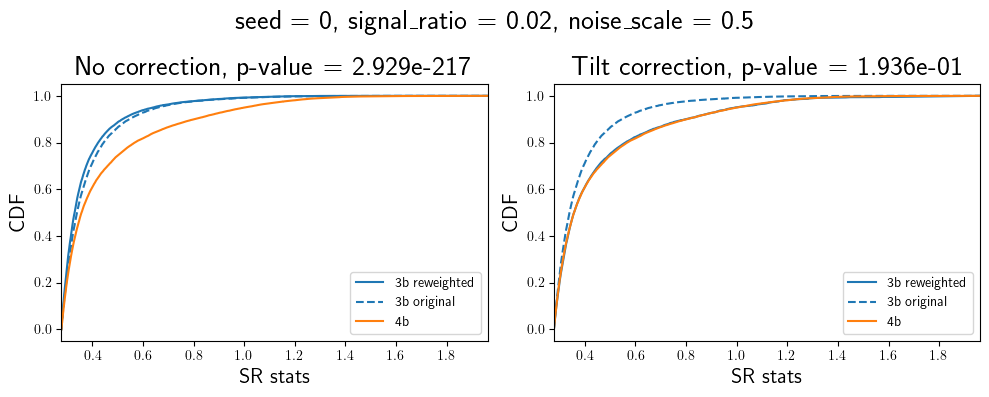

t = 1.7234272956848145, active_i = 8589, slopes[active_i] = -0.04012054204940796, i_left = 0, i_right = 22111
t = 1.7234272956848145, i_left = 8589, i_right = 22111, slopes[i_left] = -0.04012054204940796, slopes[i_right] = 0.12159556150436401, intercepts[i_left] = 0.10558906197547913, intercepts[i_right] = -0.20960277318954468
t = 1.9490442276000977, active_i = 19295, slopes[active_i] = 0.10895156860351562, i_left = 8589, i_right = 22111
t = 1.9490442276000977, i_left = 8589, i_right = 19295, slopes[i_left] = -0.04012054204940796, slopes[i_right] = 0.10895156860351562, intercepts[i_left] = 0.10558906197547913, intercepts[i_right] = -0.1768021136522293
t = 1.894326090812683, active_i = 9458, slopes[active_i] = -0.026672422885894775, i_left = 8589, i_right = 19295
t = 1.894326090812683, i_left = 9458, i_right = 19295, slopes[i_left] = -0.026672422885894775, slopes[i_right] = 0.10895156860351562, intercepts[i_left] = 0.08064590394496918, intercepts[i_right] = -0.1768021136522293
t = 1.898

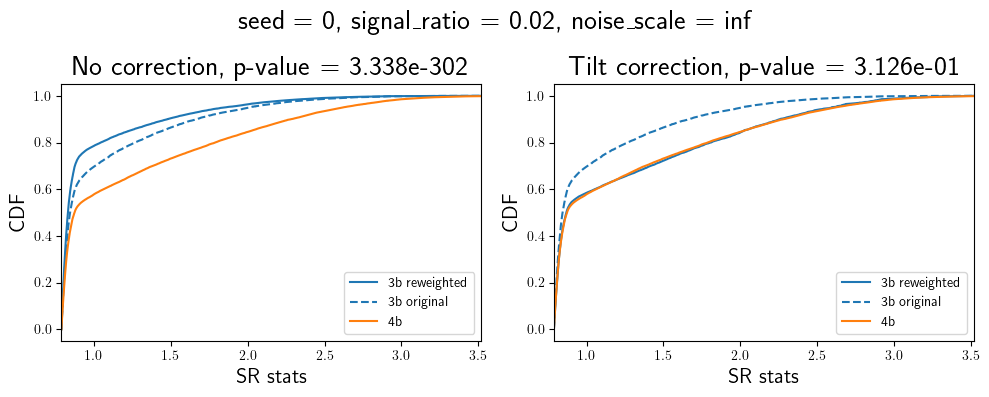

t = 1.837203025817871, active_i = 9534, slopes[active_i] = -0.027929306030273438, i_left = 0, i_right = 22729
t = 1.837203025817871, i_left = 9534, i_right = 22729, slopes[i_left] = -0.027929306030273438, slopes[i_right] = 0.1078459620475769, intercepts[i_left] = 0.08769381791353226, intercepts[i_right] = -0.19818107783794403
t = 2.1055004596710205, active_i = 21142, slopes[active_i] = 0.1053222119808197, i_left = 9534, i_right = 22729
t = 2.1055004596710205, i_left = 9534, i_right = 21142, slopes[i_left] = -0.027929306030273438, slopes[i_right] = 0.1053222119808197, intercepts[i_left] = 0.08769381791353226, intercepts[i_right] = -0.18592751026153564
t = 2.053419828414917, active_i = 9534, slopes[active_i] = -0.027929306030273438, i_left = 9534, i_right = 21142
Found minimum at t = 2.053419828414917, iteration 2
Iteration 0: [(0.0, 0.20126516), (0.5133549571037292, 0.13614325), (1.0267099142074585, 0.046946023), (1.5400648713111877, 0.08906462), (2.053419828414917, 0.2417279)]
Iteratio

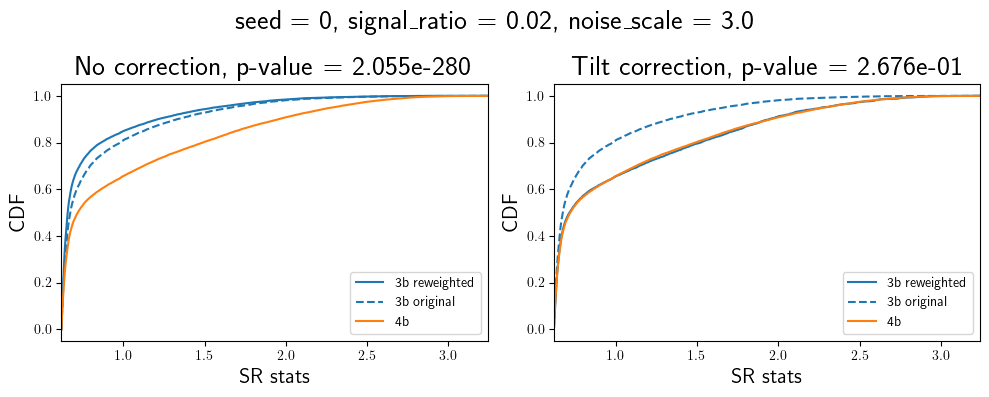

t = 2.0244457721710205, active_i = 10485, slopes[active_i] = -0.02775108814239502, i_left = 0, i_right = 24977
t = 2.0244457721710205, i_left = 10485, i_right = 24977, slopes[i_left] = -0.02775108814239502, slopes[i_right] = 0.09781476855278015, intercepts[i_left] = 0.09098619967699051, intercepts[i_right] = -0.19802069664001465
t = 2.301635980606079, active_i = 21177, slopes[active_i] = 0.08861124515533447, i_left = 10485, i_right = 24977
t = 2.301635980606079, i_left = 10485, i_right = 21177, slopes[i_left] = -0.02775108814239502, slopes[i_right] = 0.08861124515533447, intercepts[i_left] = 0.09098619967699051, intercepts[i_right] = -0.16044838726520538
t = 2.160790205001831, active_i = 21148, slopes[active_i] = 0.0884624719619751, i_left = 10485, i_right = 21177
t = 2.160790205001831, i_left = 10485, i_right = 21148, slopes[i_left] = -0.02775108814239502, slopes[i_right] = 0.0884624719619751, intercepts[i_left] = 0.09098619967699051, intercepts[i_right] = -0.16010858118534088
t = 2.1

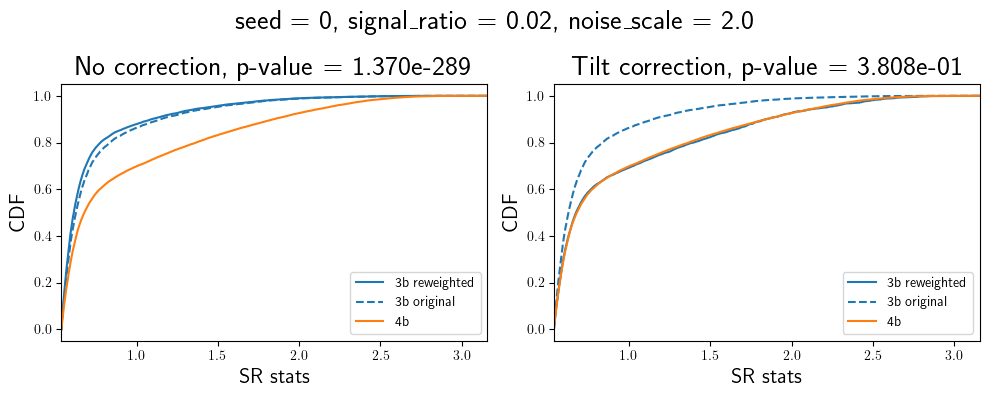

t = 2.0822665691375732, active_i = 12939, slopes[active_i] = -0.02078956365585327, i_left = 0, i_right = 29949
t = 2.0822665691375732, i_left = 12939, i_right = 29949, slopes[i_left] = -0.02078956365585327, slopes[i_right] = 0.08022245764732361, intercepts[i_left] = 0.0881788358092308, intercepts[i_right] = -0.16705532371997833
t = 2.5267701148986816, active_i = 24597, slopes[active_i] = 0.07084114849567413, i_left = 12939, i_right = 29949
t = 2.5267701148986816, i_left = 12939, i_right = 24597, slopes[i_left] = -0.02078956365585327, slopes[i_right] = 0.07084114849567413, intercepts[i_left] = 0.0881788358092308, intercepts[i_right] = -0.12618529796600342
t = 2.339435577392578, active_i = 24597, slopes[active_i] = 0.07084114849567413, i_left = 12939, i_right = 24597
Found minimum at t = 2.339435577392578, iteration 2
Iteration 0: [(0.0, 0.1786059), (0.5848588943481445, 0.12723695), (1.169717788696289, 0.060769707), (1.7545766830444336, 0.034346595), (2.339435577392578, 0.13709156)]
Iter

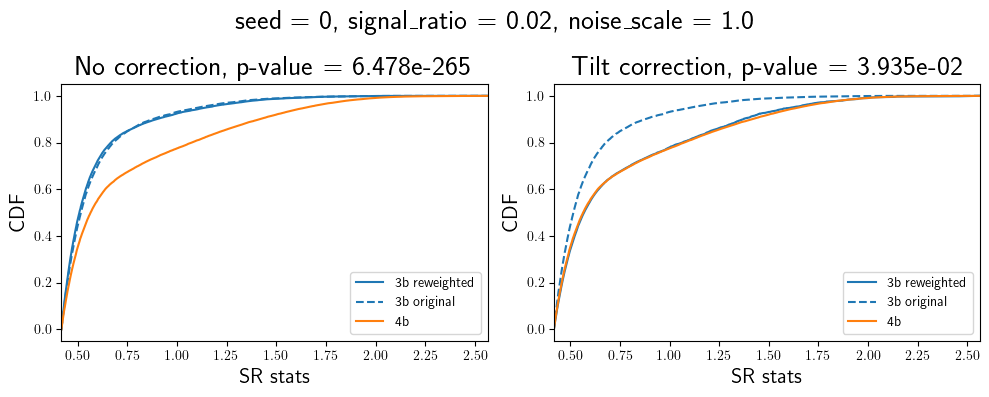

t = 2.85908842086792, active_i = 11261, slopes[active_i] = -0.03072783350944519, i_left = 0, i_right = 32627
t = 2.85908842086792, i_left = 11261, i_right = 32627, slopes[i_left] = -0.03072783350944519, slopes[i_right] = 0.05835755169391632, intercepts[i_left] = 0.11618875712156296, intercepts[i_right] = -0.16684940457344055
t = 3.1771559715270996, active_i = 26031, slopes[active_i] = 0.04878324270248413, i_left = 11261, i_right = 32627
t = 3.1771559715270996, i_left = 11261, i_right = 26031, slopes[i_left] = -0.03072783350944519, slopes[i_right] = 0.04878324270248413, intercepts[i_left] = 0.11618875712156296, intercepts[i_right] = -0.12327657639980316
t = 3.0117228031158447, active_i = 23397, slopes[active_i] = 0.03975752741098404, i_left = 11261, i_right = 26031
t = 3.0117228031158447, i_left = 11261, i_right = 23397, slopes[i_left] = -0.03072783350944519, slopes[i_right] = 0.03975752741098404, intercepts[i_left] = 0.11618875712156296, intercepts[i_right] = -0.09555792063474655
t = 3

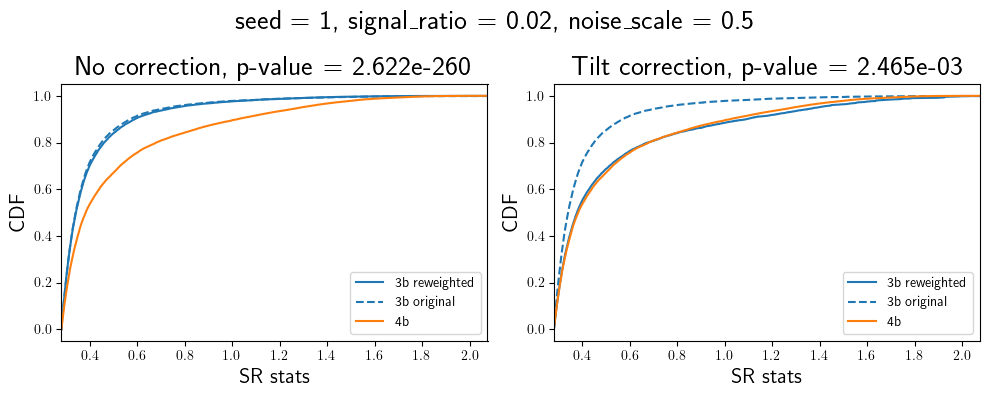

t = 1.9991753101348877, active_i = 12506, slopes[active_i] = -0.03666818141937256, i_left = 0, i_right = 32439
t = 1.9991753101348877, i_left = 12506, i_right = 32439, slopes[i_left] = -0.03666818141937256, slopes[i_right] = 0.08959031105041504, intercepts[i_left] = 0.10655799508094788, intercepts[i_right] = -0.17912492156028748
t = 2.2626826763153076, active_i = 25630, slopes[active_i] = 0.07411359250545502, i_left = 12506, i_right = 32439
t = 2.2626826763153076, i_left = 12506, i_right = 25630, slopes[i_left] = -0.03666818141937256, slopes[i_right] = 0.07411359250545502, intercepts[i_left] = 0.10655799508094788, intercepts[i_right] = -0.1326393187046051
t = 2.1591756343841553, active_i = 12506, slopes[active_i] = -0.03666818141937256, i_left = 12506, i_right = 25630
Found minimum at t = 2.1591756343841553, iteration 2
Iteration 0: [(0.0, 0.1823007), (0.5397939085960388, 0.12702946), (1.0795878171920776, 0.0543484), (1.6193817257881165, 0.056362927), (2.1591756343841553, 0.19074269)]


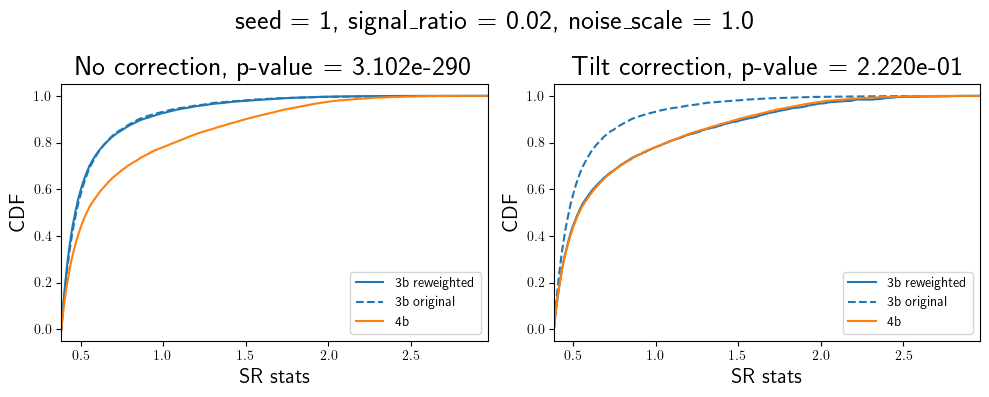

t = 1.8139971494674683, active_i = 8265, slopes[active_i] = -0.043646395206451416, i_left = 0, i_right = 22311
t = 1.8139971494674683, i_left = 8265, i_right = 22311, slopes[i_left] = -0.043646395206451416, slopes[i_right] = 0.11245608329772949, intercepts[i_left] = 0.10571778565645218, intercepts[i_right] = -0.20406273007392883
t = 1.9844688177108765, active_i = 16197, slopes[active_i] = 0.07061368227005005, i_left = 8265, i_right = 22311
t = 1.9844688177108765, i_left = 8265, i_right = 16197, slopes[i_left] = -0.043646395206451416, slopes[i_right] = 0.07061368227005005, intercepts[i_left] = 0.10571778565645218, intercepts[i_right] = -0.1068284884095192
t = 1.8601971864700317, active_i = 9916, slopes[active_i] = -0.019769608974456787, i_left = 8265, i_right = 16197
t = 1.8601971864700317, i_left = 9916, i_right = 16197, slopes[i_left] = -0.019769608974456787, slopes[i_right] = 0.07061368227005005, intercepts[i_left] = 0.0618688203394413, intercepts[i_right] = -0.1068284884095192
t = 1

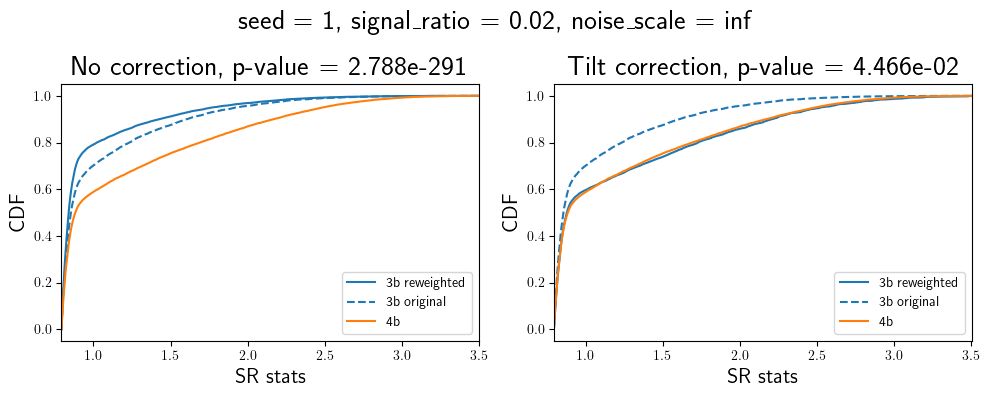

t = 1.9571468830108643, active_i = 8579, slopes[active_i] = -0.04500001668930054, i_left = 0, i_right = 24107
t = 1.9571468830108643, i_left = 8579, i_right = 24107, slopes[i_left] = -0.04500001668930054, slopes[i_right] = 0.09844163060188293, intercepts[i_left] = 0.11899003386497498, intercepts[i_right] = -0.1926647275686264
t = 2.1726934909820557, active_i = 21588, slopes[active_i] = 0.09340307116508484, i_left = 8579, i_right = 24107
t = 2.1726934909820557, i_left = 8579, i_right = 21588, slopes[i_left] = -0.04500001668930054, slopes[i_right] = 0.09340307116508484, intercepts[i_left] = 0.11899003386497498, intercepts[i_right] = -0.17429256439208984
t = 2.119046688079834, active_i = 9477, slopes[active_i] = -0.03435957431793213, i_left = 8579, i_right = 21588
t = 2.119046688079834, i_left = 9477, i_right = 21588, slopes[i_left] = -0.03435957431793213, slopes[i_right] = 0.09340307116508484, intercepts[i_left] = 0.09715141355991364, intercepts[i_right] = -0.17429256439208984
t = 2.1245

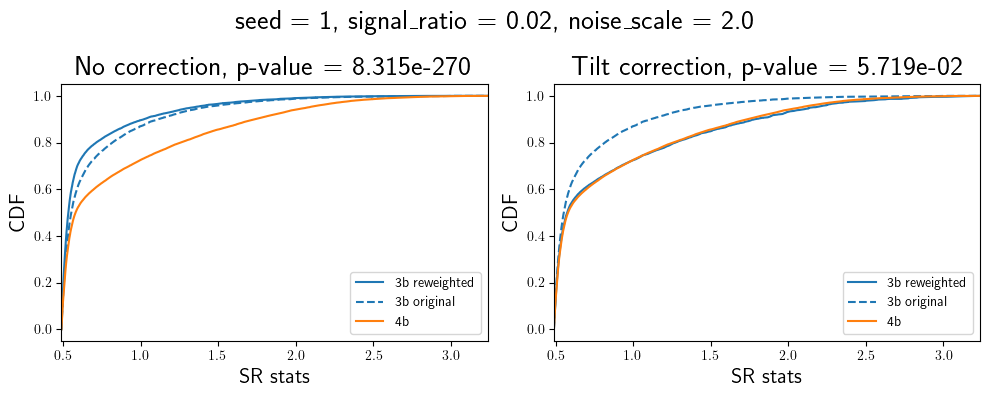

t = 2.324083089828491, active_i = 8276, slopes[active_i] = -0.03354203701019287, i_left = 0, i_right = 22397
t = 2.324083089828491, i_left = 8276, i_right = 22397, slopes[i_left] = -0.03354203701019287, slopes[i_right] = 0.0853380560874939, intercepts[i_left] = 0.09858561307191849, intercepts[i_right] = -0.19829872250556946
t = 2.497342586517334, active_i = 15921, slopes[active_i] = 0.05087749660015106, i_left = 8276, i_right = 22397
t = 2.497342586517334, i_left = 8276, i_right = 15921, slopes[i_left] = -0.03354203701019287, slopes[i_right] = 0.05087749660015106, intercepts[i_left] = 0.09858561307191849, intercepts[i_right] = -0.09896282106637955
t = 2.3400797843933105, active_i = 15620, slopes[active_i] = 0.04815953969955444, i_left = 8276, i_right = 15921
t = 2.3400797843933105, i_left = 8276, i_right = 15620, slopes[i_left] = -0.03354203701019287, slopes[i_right] = 0.04815953969955444, intercepts[i_left] = 0.09858561307191849, intercepts[i_right] = -0.09230558574199677
t = 2.336444

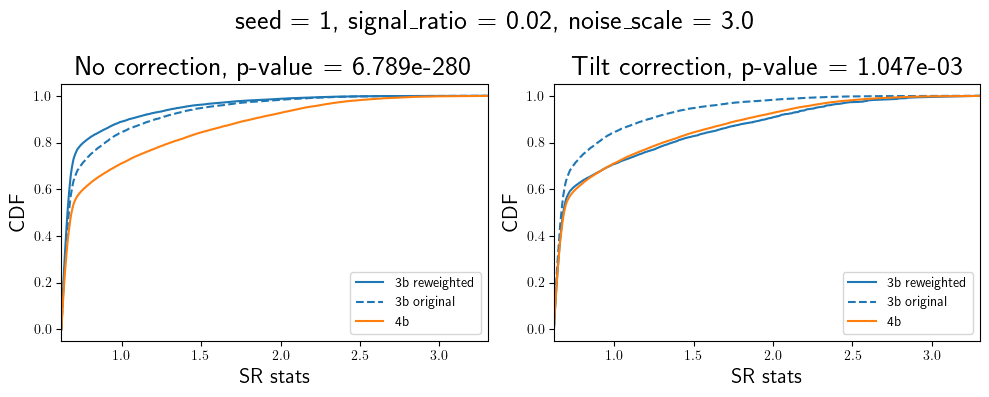

t = 2.7805473804473877, active_i = 24650, slopes[active_i] = 0.01838502287864685, i_left = 0, i_right = 34145
t = 2.7805473804473877, i_left = 0, i_right = 24650, slopes[i_left] = -0.02604810893535614, slopes[i_right] = 0.01838502287864685, intercepts[i_left] = 0.07240638136863708, intercepts[i_right] = -0.04271618649363518
t = 2.5909173488616943, active_i = 6200, slopes[active_i] = -0.022806115448474884, i_left = 0, i_right = 24650
t = 2.5909173488616943, i_left = 6200, i_right = 24650, slopes[i_left] = -0.022806115448474884, slopes[i_right] = 0.01838502287864685, intercepts[i_left] = 0.06783167272806168, intercepts[i_right] = -0.04271618649363518
t = 2.6837775707244873, active_i = 6200, slopes[active_i] = -0.022806115448474884, i_left = 6200, i_right = 24650
Found minimum at t = 2.6837775707244873, iteration 2
Iteration 0: [(0.0, 0.07403971), (0.6709443926811218, 0.05591908), (1.3418887853622437, 0.036336087), (2.0128331780433655, 0.017953947), (2.6837775707244873, 0.026088307)]
Iter

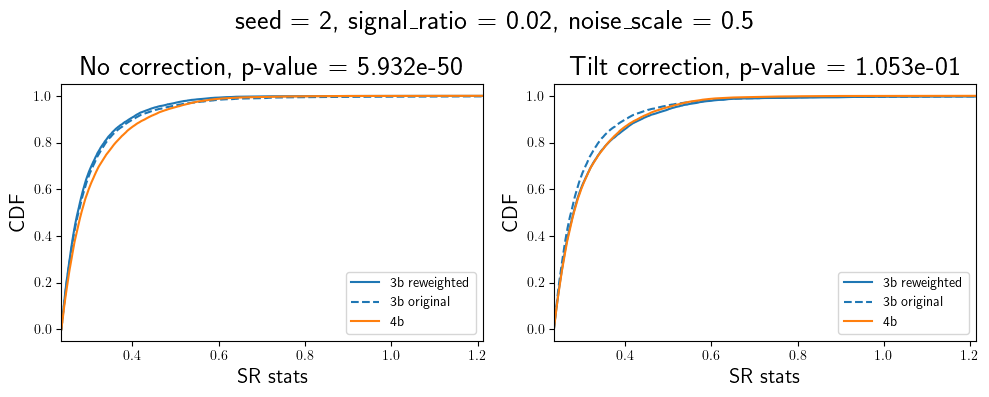

t = 1.8999615907669067, active_i = 8273, slopes[active_i] = -0.038878798484802246, i_left = 0, i_right = 21897
t = 1.8999615907669067, i_left = 8273, i_right = 21897, slopes[i_left] = -0.038878798484802246, slopes[i_right] = 0.10295724868774414, intercepts[i_left] = 0.09385888278484344, intercepts[i_right] = -0.19561481475830078
t = 2.0409038066864014, active_i = 14403, slopes[active_i] = 0.048767924308776855, i_left = 8273, i_right = 21897
t = 2.0409038066864014, i_left = 8273, i_right = 14403, slopes[i_left] = -0.038878798484802246, slopes[i_right] = 0.048767924308776855, intercepts[i_left] = 0.09385888278484344, intercepts[i_right] = -0.07375653833150864
t = 1.9123979806900024, active_i = 8273, slopes[active_i] = -0.038878798484802246, i_left = 8273, i_right = 14403
Found minimum at t = 1.9123979806900024, iteration 2
Iteration 0: [(0.0, 0.19677743), (0.4780994951725006, 0.13857698), (0.9561989903450012, 0.058165696), (1.4342984855175018, 0.09016008), (1.9123979806900024, 0.25332946

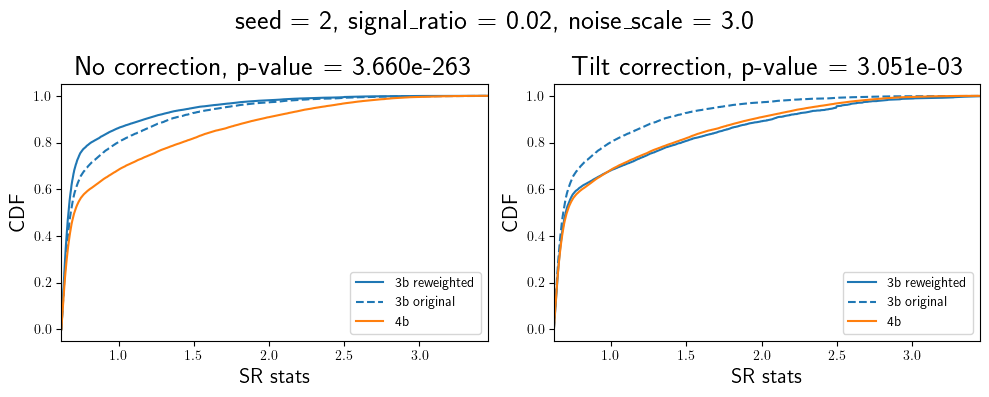

t = 2.2558958530426025, active_i = 12509, slopes[active_i] = -0.02952396869659424, i_left = 0, i_right = 31317
t = 2.2558958530426025, i_left = 12509, i_right = 31317, slopes[i_left] = -0.02952396869659424, slopes[i_right] = 0.08349791169166565, intercepts[i_left] = 0.09660153090953827, intercepts[i_right] = -0.18836258351802826
t = 2.521318197250366, active_i = 23706, slopes[active_i] = 0.06411786377429962, i_left = 12509, i_right = 31317
t = 2.521318197250366, i_left = 12509, i_right = 23706, slopes[i_left] = -0.02952396869659424, slopes[i_right] = 0.06411786377429962, intercepts[i_left] = 0.09660153090953827, intercepts[i_right] = -0.1268971860408783
t = 2.386740207672119, active_i = 23116, slopes[active_i] = 0.06077253818511963, i_left = 12509, i_right = 23706
t = 2.386740207672119, i_left = 12509, i_right = 23116, slopes[i_left] = -0.02952396869659424, slopes[i_right] = 0.06077253818511963, intercepts[i_left] = 0.09660153090953827, intercepts[i_right] = -0.11859999597072601
t = 2.

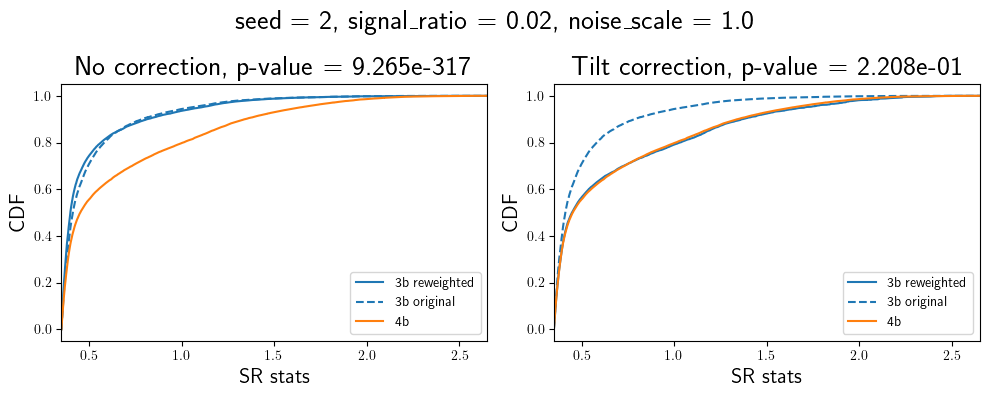

t = 1.6913777589797974, active_i = 8224, slopes[active_i] = -0.04374551773071289, i_left = 0, i_right = 21771
t = 1.6913777589797974, i_left = 8224, i_right = 21771, slopes[i_left] = -0.04374551773071289, slopes[i_right] = 0.11943960189819336, intercepts[i_left] = 0.10435006022453308, intercepts[i_right] = -0.20201748609542847
t = 1.8774232864379883, active_i = 15321, slopes[active_i] = 0.06855019927024841, i_left = 8224, i_right = 21771
t = 1.8774232864379883, i_left = 8224, i_right = 15321, slopes[i_left] = -0.04374551773071289, slopes[i_right] = 0.06855019927024841, intercepts[i_left] = 0.10435006022453308, intercepts[i_right] = -0.09696489572525024
t = 1.7927216291427612, active_i = 8601, slopes[active_i] = -0.03794580698013306, i_left = 8224, i_right = 15321
t = 1.7927216291427612, i_left = 8601, i_right = 15321, slopes[i_left] = -0.03794580698013306, slopes[i_right] = 0.06855019927024841, intercepts[i_left] = 0.0943511575460434, intercepts[i_right] = -0.09696489572525024
t = 1.79

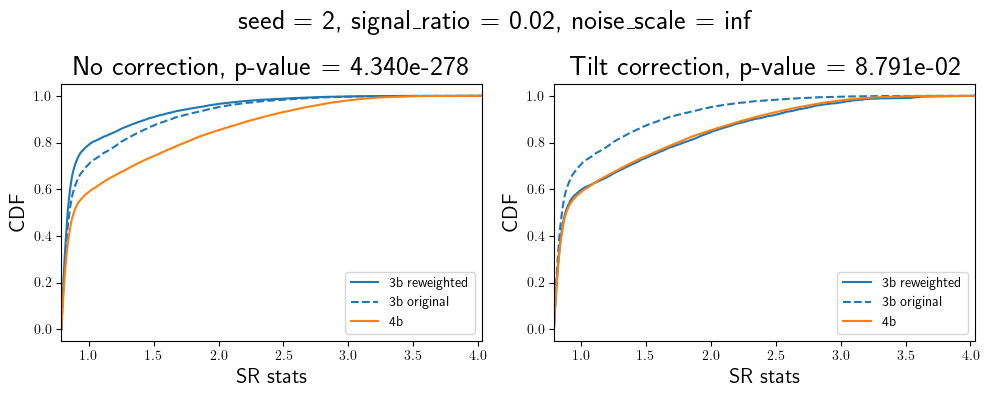

t = 2.1055185794830322, active_i = 15072, slopes[active_i] = 0.046809449791908264, i_left = 0, i_right = 22723
t = 2.1055185794830322, i_left = 0, i_right = 15072, slopes[i_left] = -0.09540137648582458, slopes[i_right] = 0.046809449791908264, intercepts[i_left] = 0.2008693814277649, intercepts[i_right] = -0.07687878608703613
t = 1.953073263168335, active_i = 8292, slopes[active_i] = -0.03945273160934448, i_left = 0, i_right = 15072
t = 1.953073263168335, i_left = 8292, i_right = 15072, slopes[i_left] = -0.03945273160934448, slopes[i_right] = 0.046809449791908264, intercepts[i_left] = 0.1034289225935936, intercepts[i_right] = -0.07687878608703613
t = 2.090229034423828, active_i = 9107, slopes[active_i] = -0.029801011085510254, i_left = 8292, i_right = 15072
t = 2.090229034423828, i_left = 9107, i_right = 15072, slopes[i_left] = -0.029801011085510254, slopes[i_right] = 0.046809449791908264, intercepts[i_left] = 0.08377080410718918, intercepts[i_right] = -0.07687878608703613
t = 2.0969667

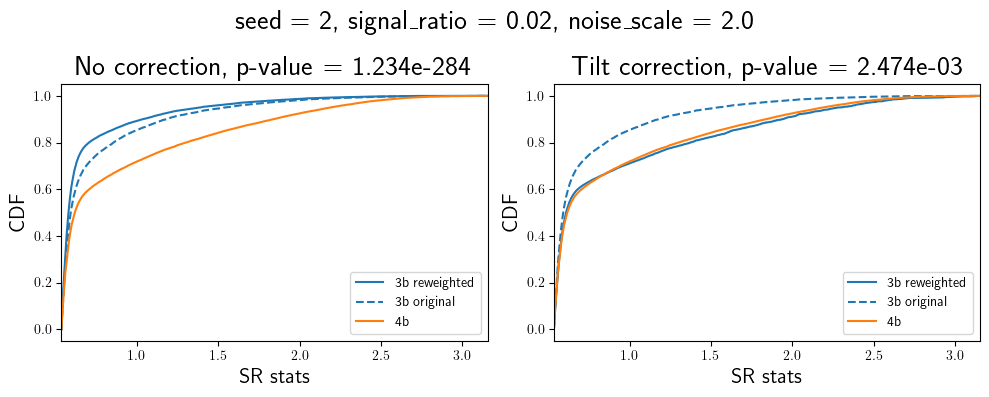

t = 1.677018642425537, active_i = 10231, slopes[active_i] = -0.04201817512512207, i_left = 0, i_right = 27227
t = 1.677018642425537, i_left = 10231, i_right = 27227, slopes[i_left] = -0.04201817512512207, slopes[i_right] = 0.107421875, intercepts[i_left] = 0.10723312944173813, intercepts[i_right] = -0.1801782250404358
t = 1.923255205154419, active_i = 25179, slopes[active_i] = 0.10427343845367432, i_left = 10231, i_right = 27227
t = 1.923255205154419, i_left = 10231, i_right = 25179, slopes[i_left] = -0.04201817512512207, slopes[i_right] = 0.10427343845367432, intercepts[i_left] = 0.10723312944173813, intercepts[i_right] = -0.16368281841278076
t = 1.8518898487091064, active_i = 10976, slopes[active_i] = -0.03357517719268799, i_left = 10231, i_right = 25179
t = 1.8518898487091064, i_left = 10976, i_right = 25179, slopes[i_left] = -0.03357517719268799, slopes[i_right] = 0.10427343845367432, intercepts[i_left] = 0.09222099184989929, intercepts[i_right] = -0.16368281841278076
t = 1.8564119

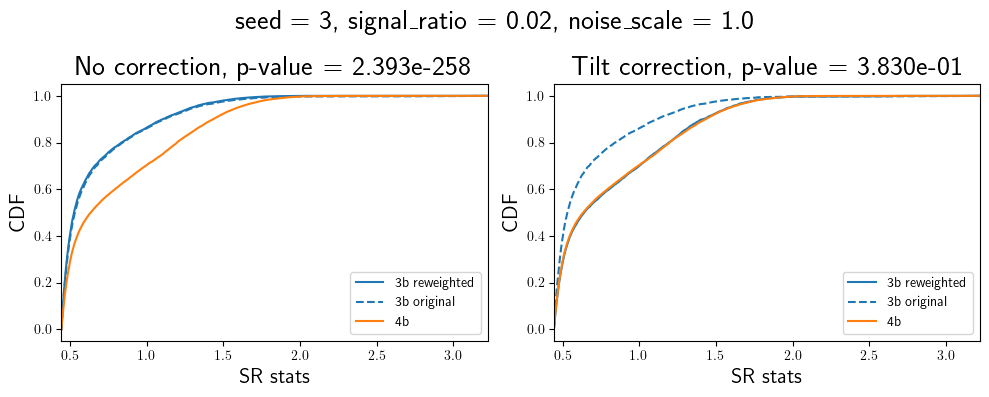

t = 1.243746280670166, active_i = 9076, slopes[active_i] = -0.06235790252685547, i_left = 0, i_right = 25117
t = 1.243746280670166, i_left = 9076, i_right = 25117, slopes[i_left] = -0.06235790252685547, slopes[i_right] = 0.14112427830696106, intercepts[i_left] = 0.11374911665916443, intercepts[i_right] = -0.17549443244934082
t = 1.421468734741211, active_i = 21882, slopes[active_i] = 0.13003069162368774, i_left = 9076, i_right = 25117
t = 1.421468734741211, i_left = 9076, i_right = 21882, slopes[i_left] = -0.06235790252685547, slopes[i_right] = 0.13003069162368774, intercepts[i_left] = 0.11374911665916443, intercepts[i_right] = -0.1513209044933319
t = 1.3777844905853271, active_i = 21882, slopes[active_i] = 0.13003069162368774, i_left = 9076, i_right = 21882
Found minimum at t = 1.3777844905853271, iteration 2
Iteration 0: [(0.0, 0.1780535), (0.3444461226463318, 0.12397317), (0.6888922452926636, 0.05913054), (1.0333383679389954, 0.031322688), (1.3777844905853271, 0.12920414)]
Iteration

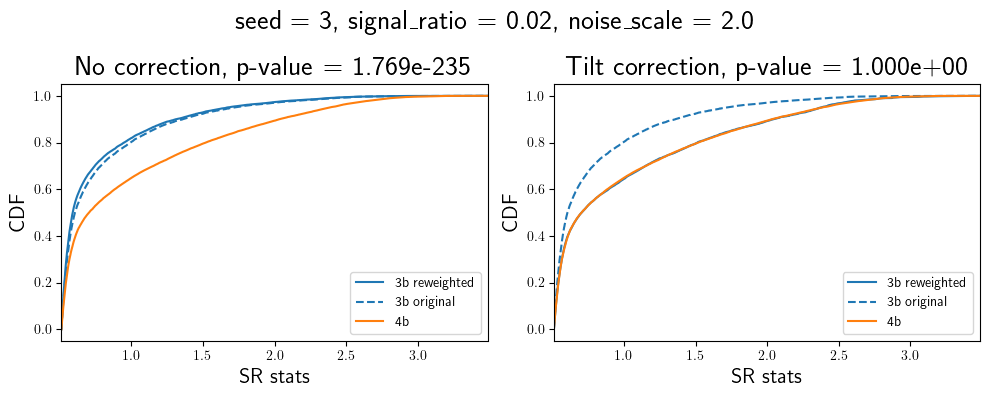

t = 1.4114145040512085, active_i = 8220, slopes[active_i] = -0.06179720163345337, i_left = 0, i_right = 23623
t = 1.4114145040512085, i_left = 8220, i_right = 23623, slopes[i_left] = -0.06179720163345337, slopes[i_right] = 0.13451847434043884, intercepts[i_left] = 0.11643312871456146, intercepts[i_right] = -0.18986132740974426
t = 1.5602139234542847, active_i = 23062, slopes[active_i] = 0.13411575555801392, i_left = 8220, i_right = 23623
t = 1.5602139234542847, i_left = 8220, i_right = 23062, slopes[i_left] = -0.06179720163345337, slopes[i_right] = 0.13411575555801392, intercepts[i_left] = 0.11643312871456146, intercepts[i_right] = -0.18428444862365723
t = 1.5349551439285278, active_i = 23062, slopes[active_i] = 0.13411575555801392, i_left = 8220, i_right = 23062
Found minimum at t = 1.5349551439285278, iteration 2
Iteration 0: [(0.0, 0.19023363), (0.38373878598213196, 0.1317001), (0.7674775719642639, 0.0579803), (1.1512163579463959, 0.051795263), (1.5349551439285278, 0.16941796)]
Iter

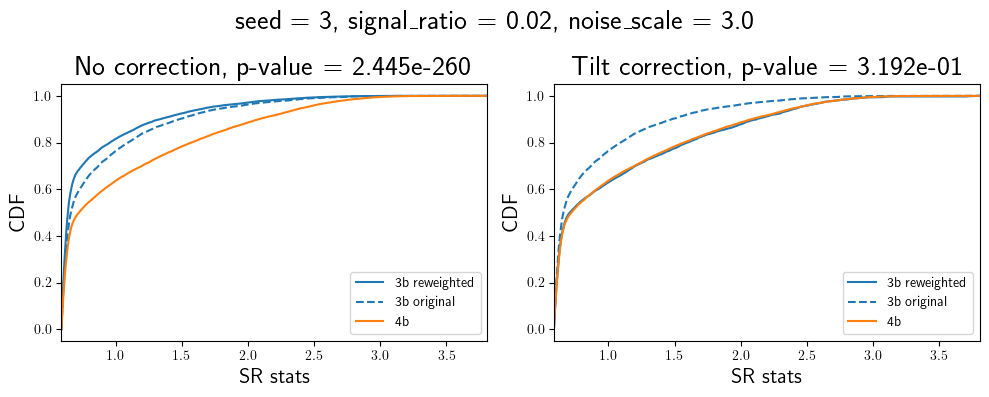

t = 1.6044684648513794, active_i = 7536, slopes[active_i] = -0.05790078639984131, i_left = 0, i_right = 22377
t = 1.6044684648513794, i_left = 7536, i_right = 22377, slopes[i_left] = -0.05790078639984131, slopes[i_right] = 0.12072092294692993, intercepts[i_left] = 0.12062645703554153, intercepts[i_right] = -0.19369766116142273
t = 1.7597194910049438, active_i = 16243, slopes[active_i] = 0.07619589567184448, i_left = 7536, i_right = 22377
t = 1.7597194910049438, i_left = 7536, i_right = 16243, slopes[i_left] = -0.05790078639984131, slopes[i_right] = 0.07619589567184448, intercepts[i_left] = 0.12062645703554153, intercepts[i_right] = -0.10268663614988327
t = 1.6653140783309937, active_i = 7536, slopes[active_i] = -0.05790078639984131, i_left = 7536, i_right = 16243
Found minimum at t = 1.6653140783309937, iteration 2
Iteration 0: [(0.0, 0.194845), (0.4163285195827484, 0.1374198), (0.8326570391654968, 0.063339055), (1.2489855587482452, 0.055394005), (1.6653140783309937, 0.18258835)]
Itera

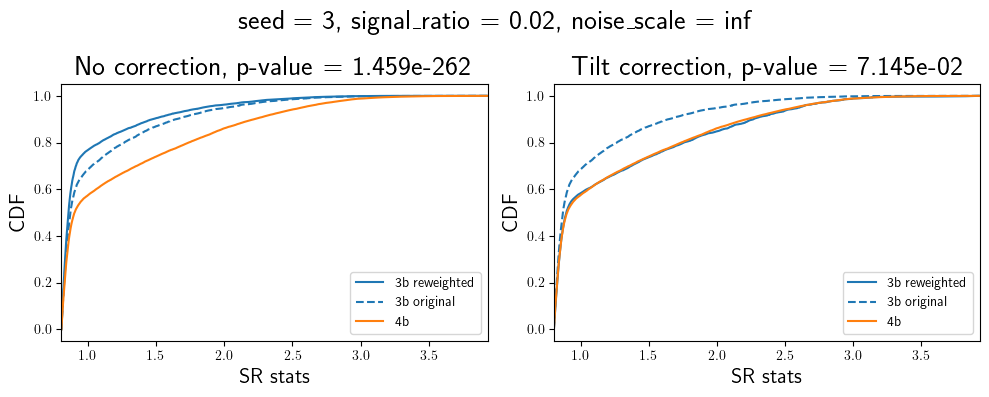

t = 1.8417354822158813, active_i = 22721, slopes[active_i] = 0.03550153970718384, i_left = 0, i_right = 31117
t = 1.8417354822158813, i_left = 0, i_right = 22721, slopes[i_left] = -0.0509161502122879, slopes[i_right] = 0.03550153970718384, intercepts[i_left] = 0.09377408027648926, intercepts[i_right] = -0.050336793065071106
t = 1.6676084995269775, active_i = 6695, slopes[active_i] = -0.041157305240631104, i_left = 0, i_right = 22721
t = 1.6676084995269775, i_left = 6695, i_right = 22721, slopes[i_left] = -0.041157305240631104, slopes[i_right] = 0.03550153970718384, intercepts[i_left] = 0.08070709556341171, intercepts[i_right] = -0.050336793065071106
t = 1.709442377090454, active_i = 6695, slopes[active_i] = -0.041157305240631104, i_left = 6695, i_right = 22721
Found minimum at t = 1.709442377090454, iteration 2
Iteration 0: [(0.0, 0.09558747), (0.4273605942726135, 0.07311543), (0.854721188545227, 0.049114175), (1.2820817828178406, 0.024919199), (1.709442377090454, 0.028277865)]
Iterati

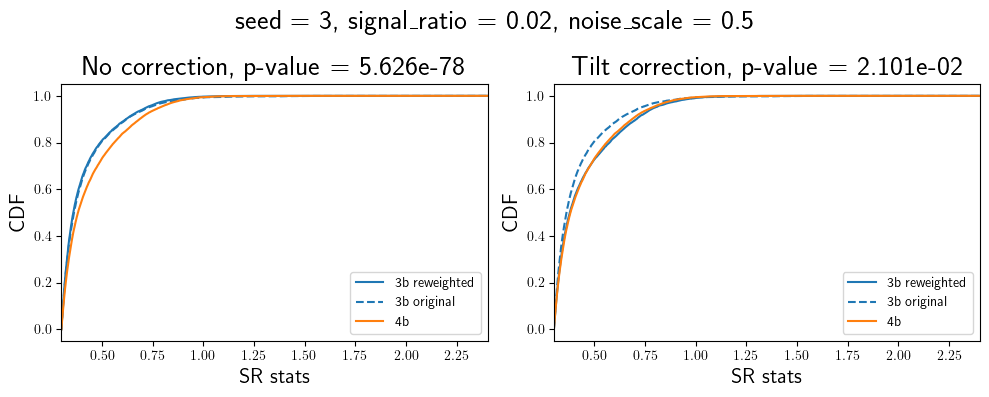

t = 1.9896563291549683, active_i = 8878, slopes[active_i] = -0.044899940490722656, i_left = 0, i_right = 24849
t = 1.9896563291549683, i_left = 8878, i_right = 24849, slopes[i_left] = -0.044899940490722656, slopes[i_right] = 0.10067993402481079, intercepts[i_left] = 0.12129323184490204, intercepts[i_right] = -0.20031847059726715
t = 2.209177017211914, active_i = 20644, slopes[active_i] = 0.08639606833457947, i_left = 8878, i_right = 24849
t = 2.209177017211914, i_left = 8878, i_right = 20644, slopes[i_left] = -0.044899940490722656, slopes[i_right] = 0.08639606833457947, intercepts[i_left] = 0.12129323184490204, intercepts[i_right] = -0.15479743480682373
t = 2.102810859680176, active_i = 8878, slopes[active_i] = -0.044899940490722656, i_left = 8878, i_right = 20644
Found minimum at t = 2.102810859680176, iteration 2
Iteration 0: [(0.0, 0.20127028), (0.525702714920044, 0.14115487), (1.051405429840088, 0.06515502), (1.5771081447601318, 0.047293253), (2.102810859680176, 0.16376542)]
Iterat

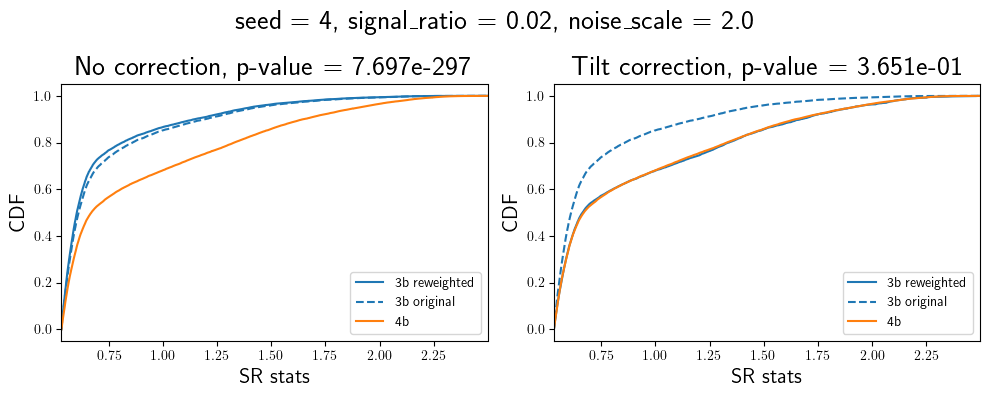

KeyboardInterrupt: 

In [12]:
from plots import plot_cdf
from ks_test import max_cdf_diff, max_cdf_diff_tilted, tilt_correction_via_first_order_approximation, tilt_correction_iterative
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_ratio = 0.02
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
correction_mode = "exponential"
max_correction_ratio = 1.5

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: (x["signal_ratio"] in [0.02]),
                                # and (x["seed"] in np.arange(10, 12)),  
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
signal_ratios = [metadata[hash_]["dataset"]["signal_ratio"] for hash_ in hashes]
hashes = [hashes[i] for i in np.lexsort((seeds, signal_ratios))]

max_diff_list = {"base": [], "CR": []}
tmp_list = {"base": [], "CR": []}
p_value_list = {"base": [], "CR": []}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    # if noise_scale != noise_scale_:
    #     continue
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    x_stats_SR = SR_stats_tst_SR
    
    max_diff = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    
    
    n_SR_4b = np.sum(is_4b_tst_SR)
    n_SR_3b = np.sum(~is_4b_tst_SR)
    tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
    
    theta = tilt_correction_iterative(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], verbose=True)
    # theta_max = np.log(max_correction_ratio) / (
    #     np.quantile(x_stats_SR[~is_4b_tst_SR], 0.99) - np.min(x_stats_SR[~is_4b_tst_SR]))
    # theta_min = -theta_max
    # print(f"theta_max = {theta_max:.4e}")
    # print(f"theta_min = {theta_min:.4e}")
    # theta = np.clip(theta, theta_min, theta_max)
    corrections = np.exp(theta * x_stats_SR) if correction_mode == "exponential" else theta * x_stats_SR + 1
    print(f"Threshold: {c_alpha(sig_level) * tmp:.4e}")
    print(f"Correction mode: {correction_mode}")
    
    print(f"theta = {theta:.4e}")
    max_diff_tilted = max_cdf_diff_tilted(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], theta, mode=correction_mode)
    p_value_tilted = min(1.0, 2 * np.exp(-2 * (max_diff_tilted / tmp)**2))
    print(f"max_diff_tilted = {max_diff_tilted:.4e}")
    print(f"p-value_tilted = {p_value_tilted:.4e}")
    
    p_value = min(1.0, 2 * np.exp(-2 * (max_diff / tmp)**2))
    print("max CDF diff with CR fvt (1 ensemble): ", max_diff)
    print("p-value: ", p_value) 
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    fig.suptitle(f"seed = {seed}, signal_ratio = {signal_ratio}, noise_scale = {noise_scale}")
    ax[0].set_title(f"No correction, p-value = {p_value:.3e}")
    plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], label="3b reweighted", 
             color=plt.cm.tab10(0))
    plot_cdf(ax[0], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
             linestyle="--", color=plt.cm.tab10(0))
    plot_cdf(ax[0], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
             color=plt.cm.tab10(1))
    
    ax[1].set_title(f"Tilt correction, p-value = {p_value_tilted:.3e}")
    plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR] * corrections[~is_4b_tst_SR], label="3b reweighted", 
             color=plt.cm.tab10(0))
    plot_cdf(ax[1], x_stats_SR[~is_4b_tst_SR], events_tst_SR.weights[~is_4b_tst_SR], label="3b original", 
             linestyle="--", color=plt.cm.tab10(0))
    plot_cdf(ax[1], x_stats_SR[is_4b_tst_SR], rw_tst_SR[is_4b_tst_SR], label="4b", 
             color=plt.cm.tab10(1))
    
    for a in ax:
        a.legend(loc="lower right")
        a.set_xlabel("SR stats")
        a.set_ylabel("CDF")
        xmin = np.min(x_stats_SR)
        xmax = min(np.max(x_stats_SR[~is_4b_tst_SR]), np.max(x_stats_SR[is_4b_tst_SR]))
        a.set_xlim(xmin, xmax)
    
    plt.tight_layout()
    plt.show()

In [9]:
from tqdm import tqdm
from plots import plot_cdf
from ks_test import max_cdf_diff, max_cdf_diff_tilted, tilt_correction_via_first_order_approximation
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_filename = "HH4b_picoAOD.h5"
sig_level = 0.05
noise_scale_ = np.inf
correction_mode = "exponential"
max_correction_ratio = 1.5

max_diff_list = {(signal_ratio, SR_size, noise_scale_): [] for
                  signal_ratio in [0.0, 0.0075, 0.01] for
                  SR_size in [0.05] for
                  noise_scale_ in [0.5, 1.0, 2.0, 3.0, np.inf]}
tmp_list = {(signal_ratio, SR_size, noise_scale_): [] for
            signal_ratio in [0.0, 0.0075, 0.01] for
            SR_size in [0.05] for
            noise_scale_ in [0.5, 1.0, 2.0, 3.0, np.inf]}
p_value_list = {(signal_ratio, SR_size, noise_scale_): [] for
                signal_ratio in [0.0, 0.0075, 0.01] for
                SR_size in [0.05] for
                noise_scale_ in [0.5, 1.0, 2.0, 3.0, np.inf]}

for signal_ratio in [0.01, 0.0, 0.0075]:
    for SR_size in [0.05]:
        hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio,  
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
        metadata = TrainingInfo.load_metadata()
        seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
        hashes = [hashes[i] for i in np.argsort(seeds)]

        
        for hash_ in tqdm(hashes):
            CR_fvt_tinfo = TrainingInfo.load(hash_)
            SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
            ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
            stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
            seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
            signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
            
            SR_stats_train, SR_stats_tst = compute_sr_stats(
                SR_stats_hashes,
                signal_filename,
                ensemble_mode,
                stats_type,
            )
            
            smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
            if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
                noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
            else:
                noise_scale = np.inf
                
            msamples = MotherSamples.load(smeared_tinfo.ms_hash)
            events_train = events_from_scdinfo(
                msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
            )
            events_tst = events_from_scdinfo(
                msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
            )
            SR_cut, CR_cut = get_SR_CR_cut(
                    SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
                )
            SR_idx = SR_stats_tst >= SR_cut
            
            SR_stats_tst_SR = SR_stats_tst[SR_idx]
            events_tst_SR = events_tst[SR_idx]
            
            fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
            reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
            rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
            is_4b_tst_SR = events_tst_SR.is_4b

            x_stats_SR = SR_stats_tst_SR
            
            n_SR_4b = np.sum(is_4b_tst_SR)
            n_SR_3b = np.sum(~is_4b_tst_SR)
            tmp = np.sqrt((n_SR_4b + n_SR_3b) / (n_SR_4b * n_SR_3b))
            
            # theta_max = np.log(max_correction_ratio) / (np.max(x_stats_SR[~is_4b_tst_SR]) - np.min(x_stats_SR[~is_4b_tst_SR]))
            # theta_min = -theta_max
            theta = tilt_correction_via_first_order_approximation(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                                    rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], verbose=False)
            # theta = np.clip(theta, theta_min, theta_max)
            corrections = np.exp(theta * x_stats_SR) if correction_mode == "exponential" else theta * x_stats_SR + 1
            max_diff_tilted = max_cdf_diff_tilted(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                                    rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], theta, mode=correction_mode)
            p_value_tilted = min(1.0, 2 * np.exp(-2 * (max_diff_tilted / tmp)**2))
            
            max_diff_list[(signal_ratio, SR_size, noise_scale)].append(max_diff_tilted)
            tmp_list[(signal_ratio, SR_size, noise_scale)].append(tmp)
            p_value_list[(signal_ratio, SR_size, noise_scale)].append(p_value_tilted)
            
    tmp_data = {"max_cdf_diff": max_diff_list, "tmp": tmp_list, "p_value": p_value_list}
    with open(f"./data/tmp/max_cdf_data_tilt_correction.pkl", "wb") as f:
        pickle.dump(tmp_data, f)

100%|██████████| 250/250 [18:34<00:00,  4.46s/it]


In [4]:
from tqdm import tqdm


def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

sig_level = 0.05

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max"}, return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = []

for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    results.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "SR_size": SR_size,
        "noise_scale": noise_scale,
        "max_cdf_diff": CR_fvt_tinfo.aux_info["max_cdf_diff"],
        "max_diff_tilted": min(CR_fvt_tinfo.aux_info["max_diff_tilted"], 
                                      CR_fvt_tinfo.aux_info["max_cdf_diff"]),
        "tilt_correction": CR_fvt_tinfo.aux_info["tilt_correction"],
        "max_cdf_diff_iterative": CR_fvt_tinfo.aux_info["max_diff_tilted_iterative"],
        "tilt_correction_iterative": CR_fvt_tinfo.aux_info["tilt_correction_iterative"],
        "N_4b_SR": CR_fvt_tinfo.aux_info["N_4b_SR"],
        "N_3b_SR": CR_fvt_tinfo.aux_info["N_3b_SR"],
        "W_4b_SR": CR_fvt_tinfo.aux_info["W_4b_SR"],
        "W_3b_SR": CR_fvt_tinfo.aux_info["W_3b_SR"],
        "W2_4b_SR": CR_fvt_tinfo.aux_info["W2_4b_SR"],
        "W2_3b_SR": CR_fvt_tinfo.aux_info["W2_3b_SR"],
    })

  2%|▏         | 117/5000 [00:00<00:25, 193.39it/s]

100%|██████████| 5000/5000 [00:26<00:00, 189.86it/s]


In [5]:
sig_level = 0.05

results_df = pd.DataFrame(results)
N_EFF_4b_SR = results_df["W_4b_SR"]**2 / results_df["W2_4b_SR"]
N_EFF_3b_SR = results_df["W_3b_SR"]**2 / results_df["W2_3b_SR"]
norm = np.sqrt((N_EFF_4b_SR + N_EFF_3b_SR) / (N_EFF_4b_SR * N_EFF_3b_SR))
results_df["normalized_max_cdf_diff"] = results_df["max_cdf_diff"] / norm
p_values = 2 * np.exp(-2 * (results_df["normalized_max_cdf_diff"])**2)
results_df["p_value"] = p_values
results_df["rejected"] = results_df["p_value"] < sig_level

results_df["normalized_max_cdf_diff_tilted"] = results_df["max_diff_tilted"] / norm
p_values = 2 * np.exp(-2 * (results_df["normalized_max_cdf_diff_tilted"])**2)
results_df["p_value_tilted"] = p_values
results_df["rejected_tilted"] = results_df["p_value_tilted"] < sig_level

results_df["normalized_max_cdf_diff_iterative"] = results_df["max_cdf_diff_iterative"] / norm
p_values = 2 * np.exp(-2 * (results_df["normalized_max_cdf_diff_iterative"])**2)
results_df["p_value_iterative"] = p_values
results_df["rejected_iterative"] = results_df["p_value_iterative"] < sig_level

results_df["tilt_correction_abs"] = np.abs(results_df["tilt_correction"])
results_df["tilt_correction_abs_iterative"] = np.abs(results_df["tilt_correction_iterative"])

In [6]:
from itertools import product

print("Without tilt correction")

for signal_ratio, SR_size in product([0.0, 0.0075, 0.01, 0.02], [0.05, 0.1, 0.15, 0.2]):
    print(f"signal_ratio = {signal_ratio}, SR_size = {SR_size}")
    display(results_df.groupby(["signal_ratio", "SR_size", "noise_scale"]).mean().loc[(signal_ratio, SR_size, )])
    print("-" * 100)

Without tilt correction
signal_ratio = 0.0, SR_size = 0.05


,seed,max_cdf_diff,max_diff_tilted,tilt_correction,max_cdf_diff_iterative,tilt_correction_iterative,N_4b_SR,N_3b_SR,W_4b_SR,W_3b_SR,...,p_value,rejected,normalized_max_cdf_diff_tilted,p_value_tilted,rejected_tilted,normalized_max_cdf_diff_iterative,p_value_iterative,rejected_iterative,tilt_correction_abs,tilt_correction_abs_iterative
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.009467,0.006238,-0.026705,0.006171,-0.031141,27201.82,24215.24,28462.730469,28365.160156,...,0.403636,0.18,0.663718,0.854364,0.00,0.656627,0.869676,0.0,0.230083,0.230557
1.0,24.5,0.010208,0.006270,0.093470,0.006191,0.088428,27384.80,19935.48,28422.267578,28140.998047,...,0.423956,0.18,0.644861,0.893520,0.00,0.636688,0.910642,0.0,0.257294,0.254845
2.0,24.5,0.009720,0.006456,-0.015624,0.006177,-0.033771,27730.44,15058.94,28426.857422,28349.005859,...,0.504821,0.10,0.626674,0.970027,0.02,0.599302,0.991451,0.0,0.284670,0.279518
3.0,24.5,0.009063,0.006477,0.071662,0.006211,0.056183,28068.34,13807.14,28452.376953,28250.800781,...,0.600849,0.10,0.619127,0.986229,0.02,0.593771,1.003152,0.0,0.304270,0.293641
inf,24.5,0.009873,0.006504,-0.098414,0.006489,-0.099733,28418.78,13546.04,28454.998047,28245.080078,...,0.451477,0.06,0.621202,0.940486,0.00,0.619822,0.943555,0.0,0.274682,0.275063


----------------------------------------------------------------------------------------------------
signal_ratio = 0.0, SR_size = 0.1


,seed,max_cdf_diff,max_diff_tilted,tilt_correction,max_cdf_diff_iterative,tilt_correction_iterative,N_4b_SR,N_3b_SR,W_4b_SR,W_3b_SR,...,p_value,rejected,normalized_max_cdf_diff_tilted,p_value_tilted,rejected_tilted,normalized_max_cdf_diff_iterative,p_value_iterative,rejected_iterative,tilt_correction_abs,tilt_correction_abs_iterative
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.007763,0.004039,0.028447,0.003992,0.025192,54398.18,46368.06,56916.394531,56492.968750,...,0.346185,0.30,0.606253,0.976048,0.0,0.599144,0.991866,0.0,0.236980,0.236444
1.0,24.5,0.007943,0.004509,0.101853,0.004462,0.098747,54792.56,38725.86,56924.460938,56109.386719,...,0.320129,0.24,0.640137,0.906928,0.0,0.634021,0.920493,0.0,0.198907,0.197988
2.0,24.5,0.006791,0.004370,0.042863,0.004351,0.040945,55338.48,30045.10,56887.191406,56421.984375,...,0.464011,0.06,0.601377,0.982067,0.0,0.598709,0.987997,0.0,0.189651,0.188897
3.0,24.5,0.008184,0.004248,0.114567,0.004212,0.111429,55850.06,28152.38,56955.136719,56300.871094,...,0.355370,0.28,0.577479,1.035611,0.0,0.572621,1.046129,0.0,0.298440,0.296256
inf,24.5,0.008628,0.004497,0.176513,0.004479,0.175300,56435.26,27842.70,57001.625000,55887.734375,...,0.316114,0.32,0.611984,0.961750,0.0,0.609491,0.967452,0.0,0.246871,0.245904


----------------------------------------------------------------------------------------------------
signal_ratio = 0.0, SR_size = 0.15


...

----------------------------------------------------------------------------------------------------
signal_ratio = 0.02, SR_size = 0.15


,seed,max_cdf_diff,max_diff_tilted,tilt_correction,max_cdf_diff_iterative,tilt_correction_iterative,N_4b_SR,N_3b_SR,W_4b_SR,W_3b_SR,...,p_value,rejected,normalized_max_cdf_diff_tilted,p_value_tilted,rejected_tilted,normalized_max_cdf_diff_iterative,p_value_iterative,rejected_iterative,tilt_correction_abs,tilt_correction_abs_iterative
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.062902,0.036225,2.196127,0.011316,1.710174,80568.88,60613.62,85168.007812,75866.781250,...,0.023486,0.98,6.410678,4.033061e-02,0.92,2.004512,0.088939,0.74,2.196127,1.710174
1.0,24.5,0.078722,0.058815,1.936365,0.013981,1.380861,80767.60,52812.42,85254.312500,75095.328125,...,0.000000,1.00,10.172673,2.629780e-07,1.00,2.416475,0.008858,0.96,1.936365,1.380861
2.0,24.5,0.083095,0.074885,1.760994,0.010596,1.140990,81902.08,43448.54,85398.882812,75478.593750,...,0.000000,1.00,12.416834,0.000000e+00,1.00,1.755837,0.050910,0.74,1.760994,1.140990
3.0,24.5,0.083598,0.075797,1.699507,0.011127,1.096843,82630.30,40840.42,85414.890625,76382.078125,...,0.000000,1.00,12.395724,0.000000e+00,1.00,1.818884,0.035227,0.82,1.699507,1.096843
inf,24.5,0.082867,0.071178,1.440458,0.011149,0.950602,83325.78,40268.68,85429.320312,75598.203125,...,0.000000,1.00,11.634962,0.000000e+00,1.00,1.822558,0.034131,0.88,1.440458,0.950602


----------------------------------------------------------------------------------------------------
signal_ratio = 0.02, SR_size = 0.2


,seed,max_cdf_diff,max_diff_tilted,tilt_correction,max_cdf_diff_iterative,tilt_correction_iterative,N_4b_SR,N_3b_SR,W_4b_SR,W_3b_SR,...,p_value,rejected,normalized_max_cdf_diff_tilted,p_value_tilted,rejected_tilted,normalized_max_cdf_diff_iterative,p_value_iterative,rejected_iterative,tilt_correction_abs,tilt_correction_abs_iterative
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.052112,0.027776,1.983212,0.010889,1.607674,107755.46,82641.46,113657.273438,103683.492188,...,6.111180e-09,1.0,5.729006,2.700430e-02,0.94,2.246276,0.080847,0.82,1.983212,1.607674
1.0,24.5,0.062341,0.043473,1.734905,0.013490,1.282112,108052.50,72141.82,113743.820312,103203.601562,...,0.000000e+00,1.0,8.760010,9.224721e-07,1.00,2.718840,0.001655,1.00,1.734905,1.282112
2.0,24.5,0.064625,0.053077,1.586806,0.010923,1.075763,109376.22,59717.70,113862.953125,103640.750000,...,0.000000e+00,1.0,10.274030,0.000000e+00,1.00,2.112741,0.020539,0.92,1.586806,1.075763
3.0,24.5,0.064406,0.049879,1.492927,0.011506,1.026137,110225.18,56465.24,113956.429688,103634.703125,...,0.000000e+00,1.0,9.547191,1.007534e-42,1.00,2.201395,0.034758,0.88,1.492927,1.026137
inf,24.5,0.063675,0.043795,1.242369,0.012001,0.877891,111033.98,55862.92,113971.992188,102450.867188,...,0.000000e+00,1.0,8.379903,1.727801e-42,1.00,2.296216,0.005855,1.00,1.242369,0.877891


----------------------------------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF diff", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        ax = axs.flatten()[i]
        
        # collect the data for each noise scale
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["SR_size"] == SR_size) &
                (results_df["noise_scale"] == ns),
                "normalized_max_cdf_diff"
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        # critical value line
        # ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(f"SR_size = {SR_size}", fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


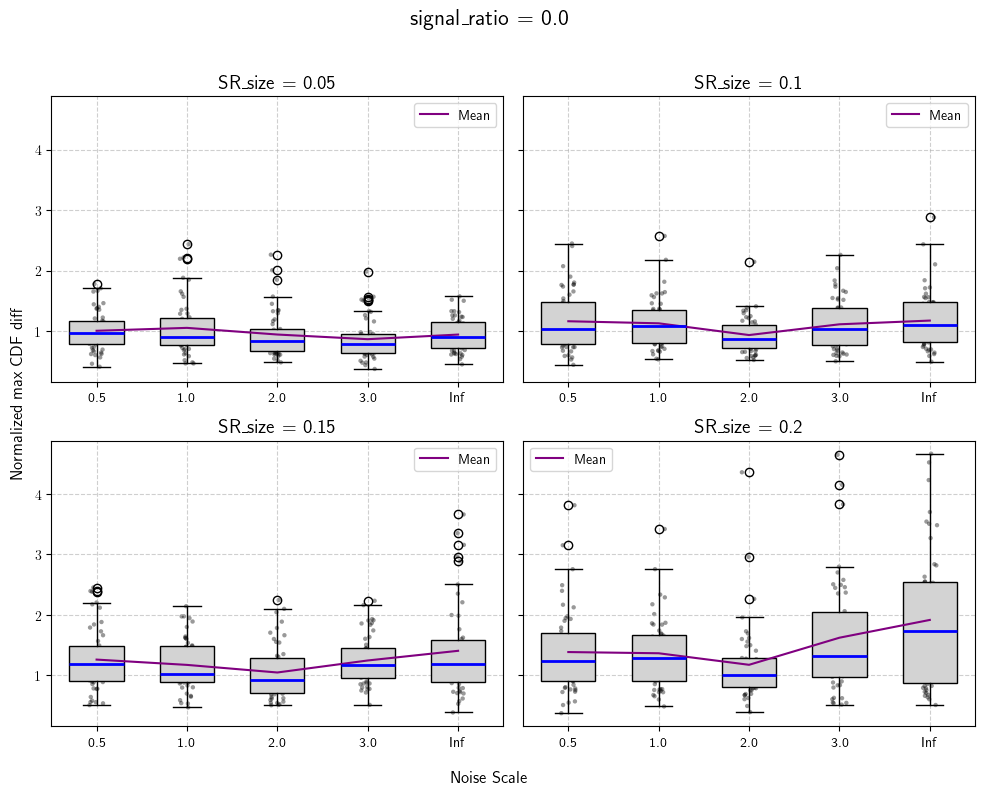

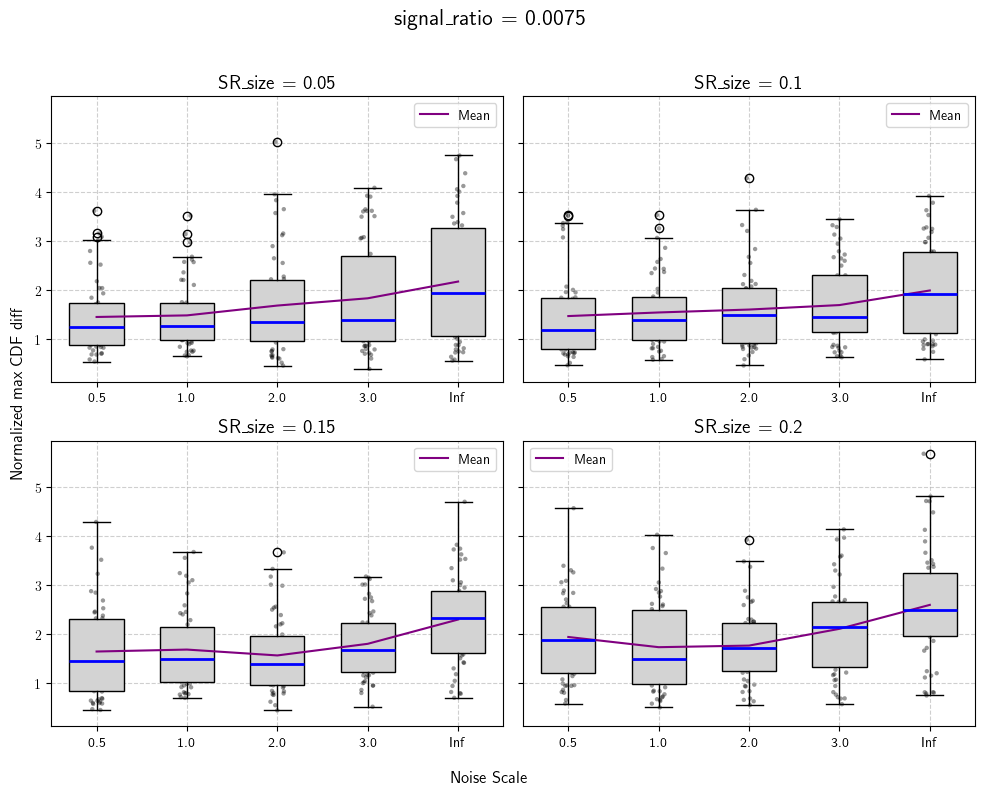

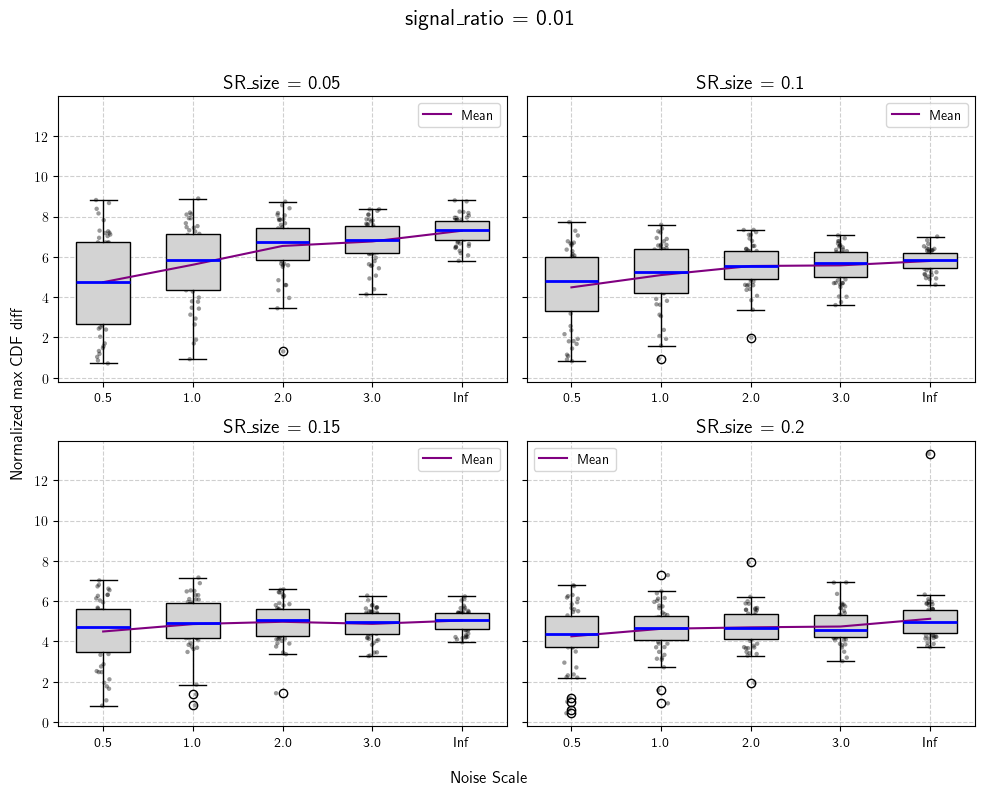

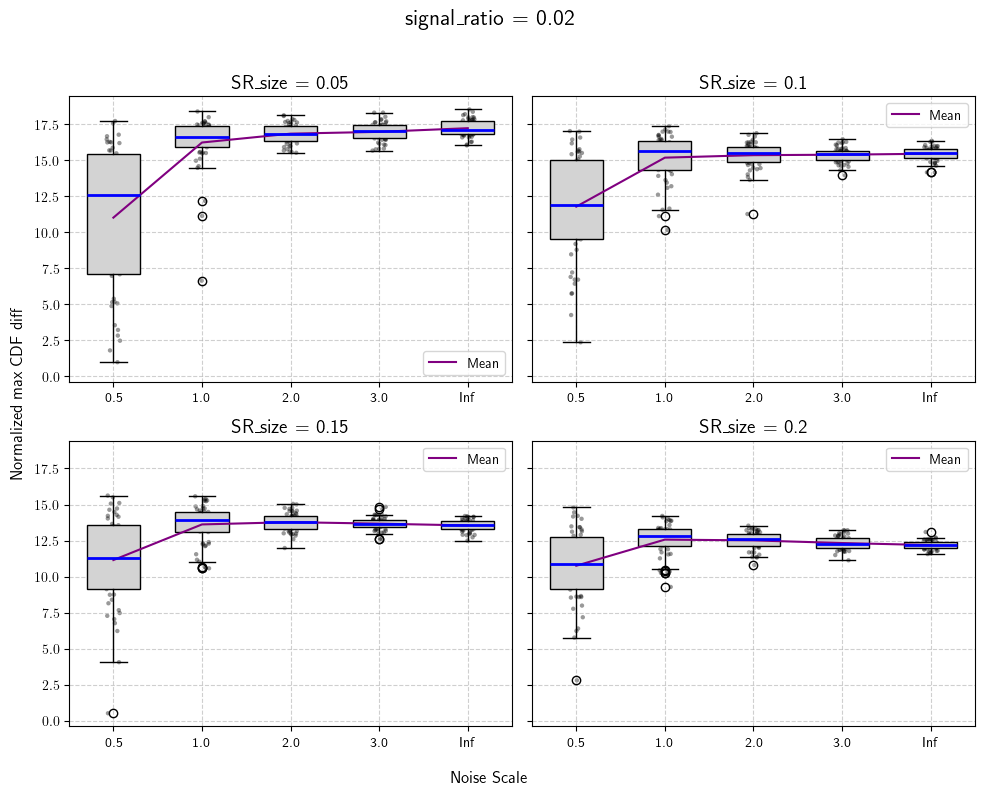

In [7]:
import numpy as np
import matplotlib.pyplot as plt

sig_level = 0.05

for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF diff", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        ax = axs.flatten()[i]
        
        # collect the data for each noise scale
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["SR_size"] == SR_size) &
                (results_df["noise_scale"] == ns),
                "normalized_max_cdf_diff"
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        # critical value line
        # ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(f"SR_size = {SR_size}", fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


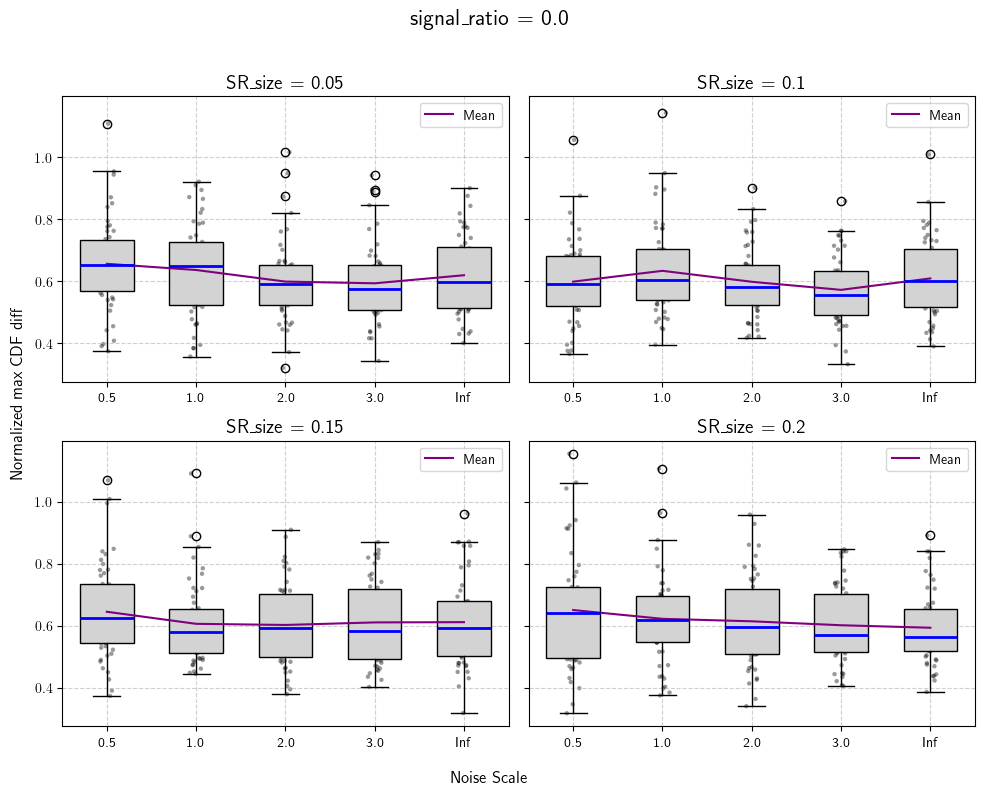

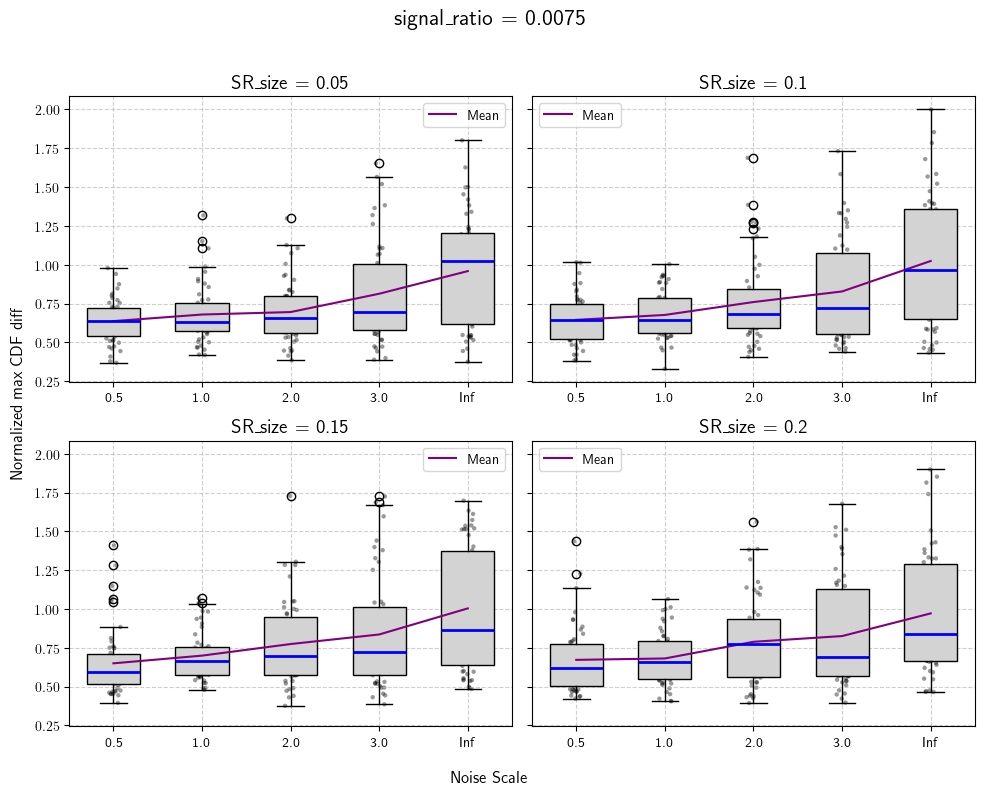

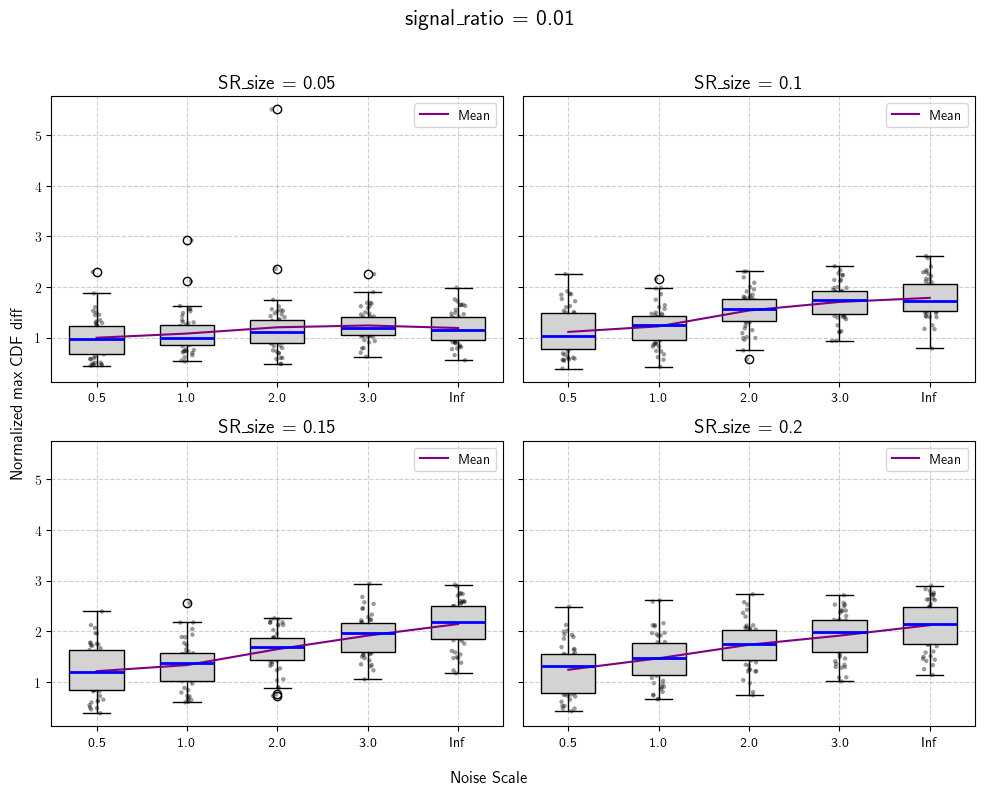

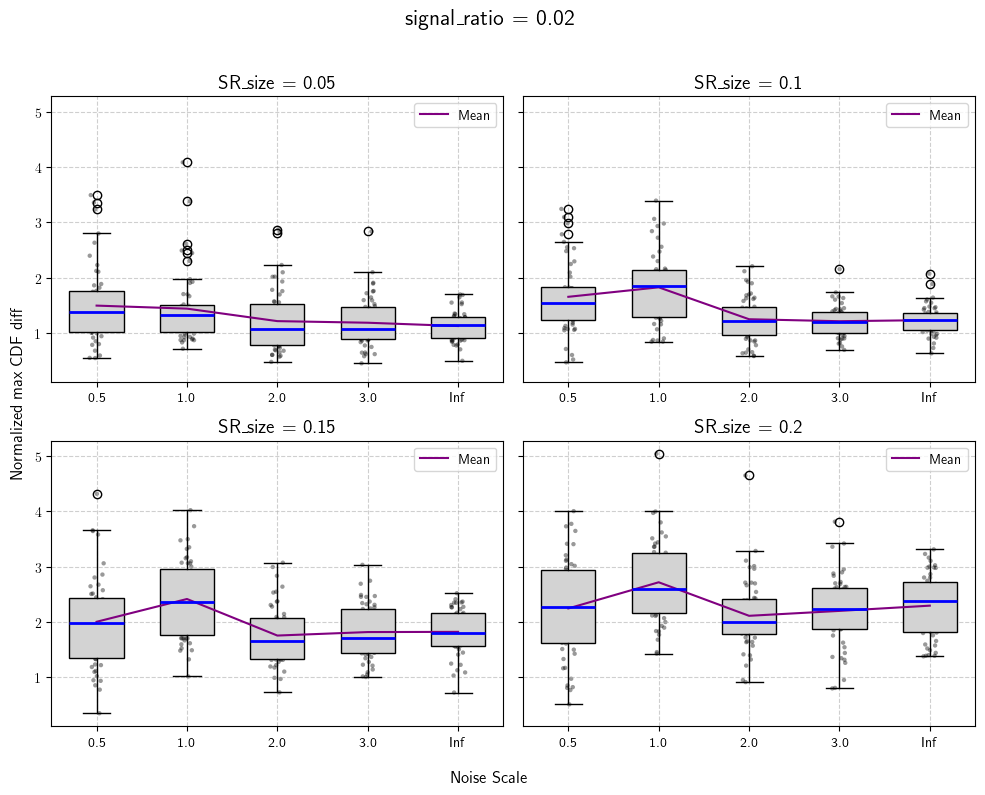

In [8]:
import numpy as np
import matplotlib.pyplot as plt

sig_level = 0.05

for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF diff", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        ax = axs.flatten()[i]
        
        # collect the data for each noise scale
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["SR_size"] == SR_size) &
                (results_df["noise_scale"] == ns),
                "normalized_max_cdf_diff_iterative"
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        # critical value line
        # ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(f"SR_size = {SR_size}", fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


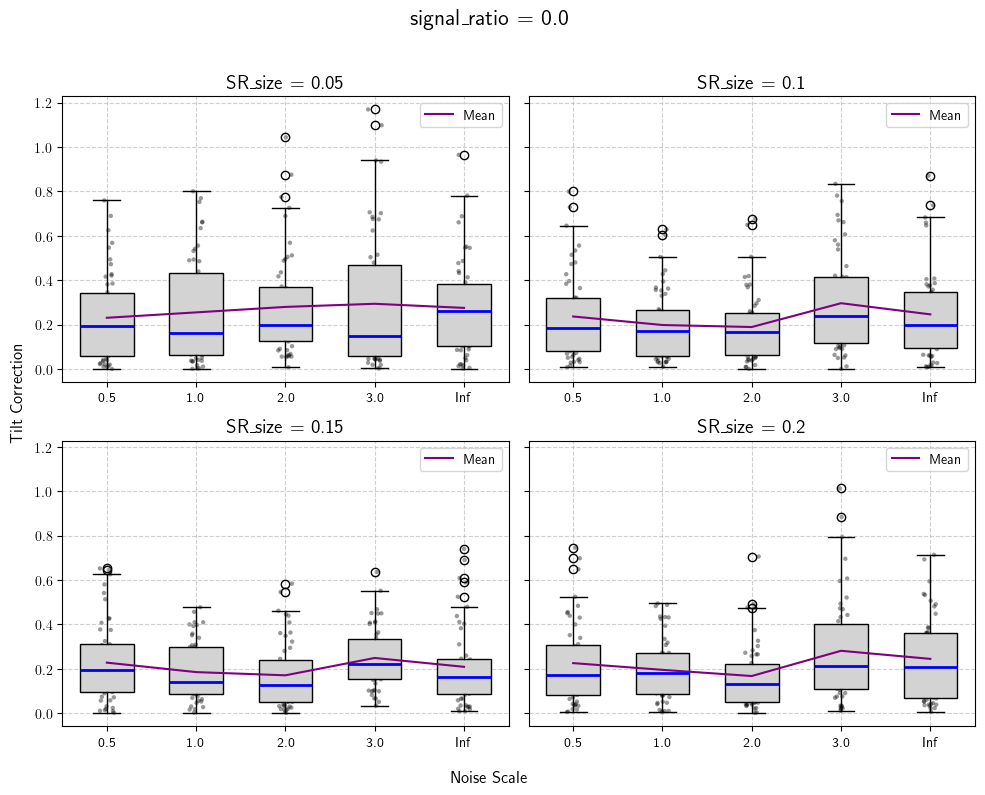

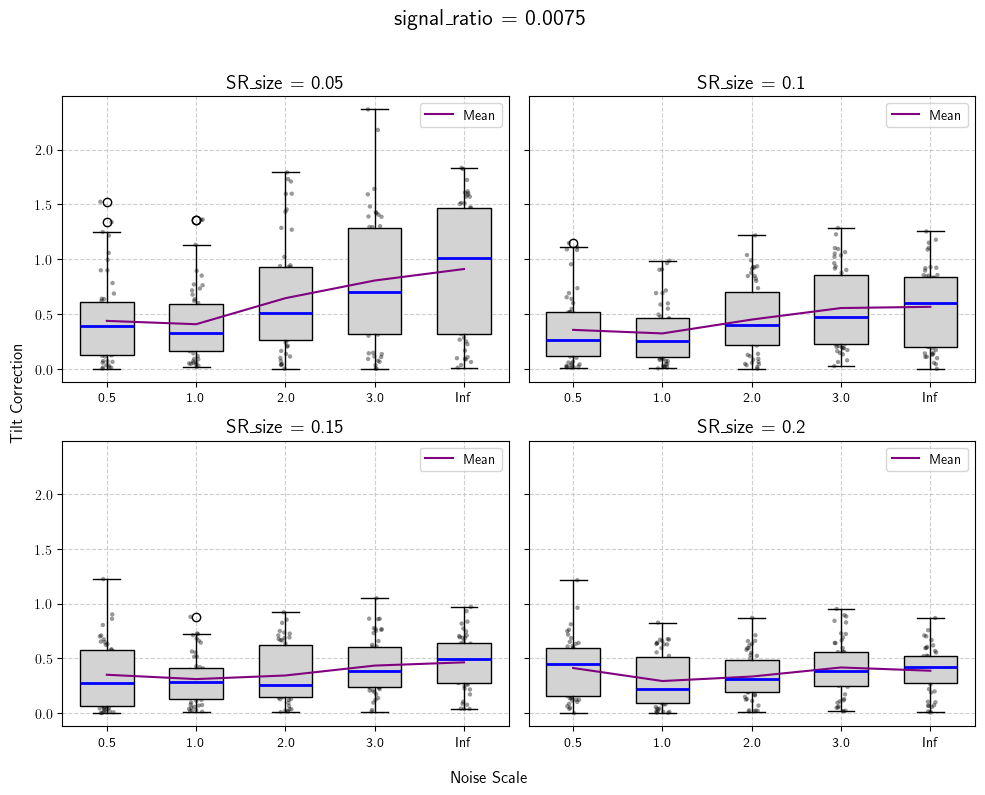

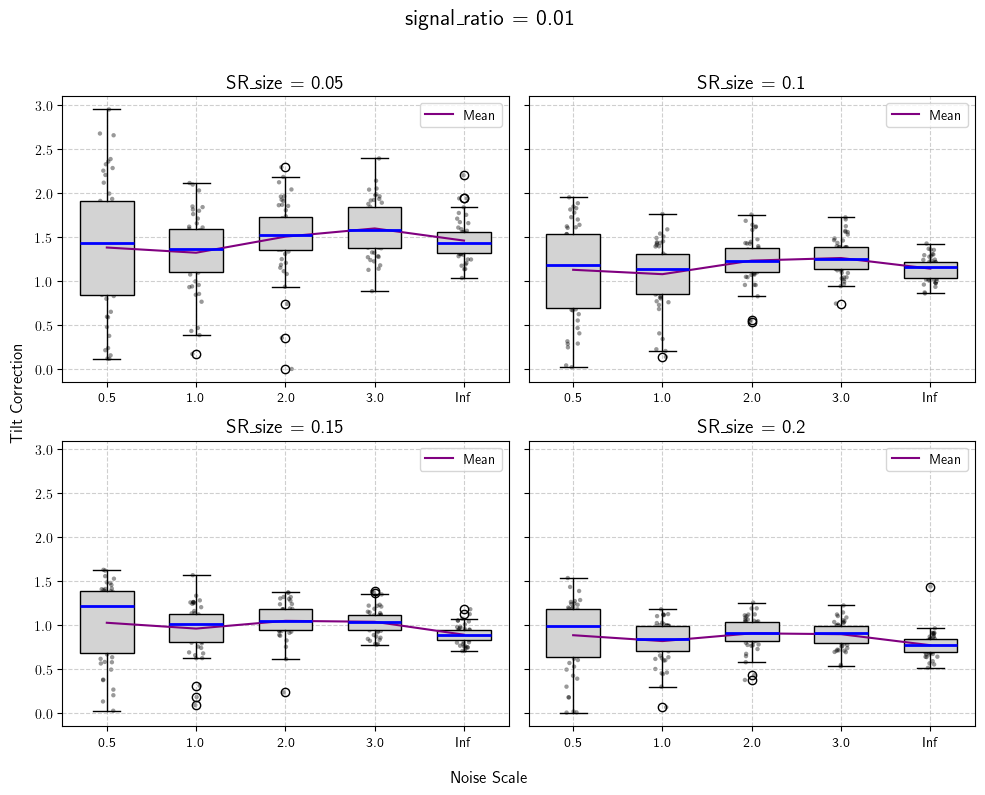

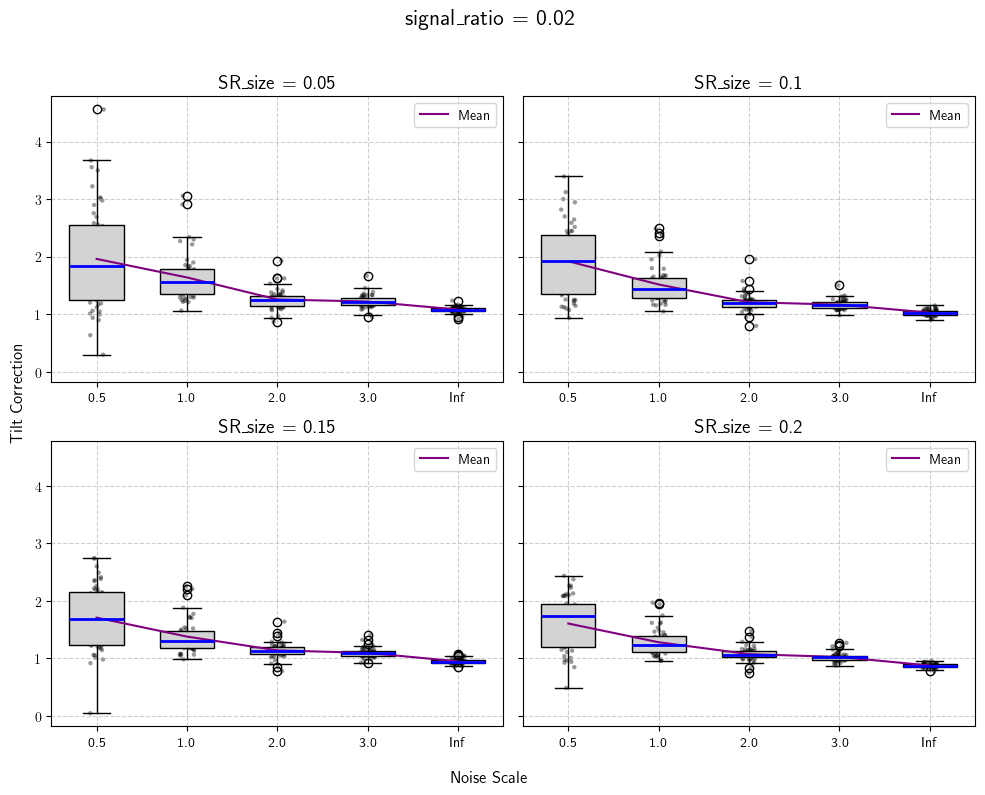

In [10]:
import numpy as np
import matplotlib.pyplot as plt

sig_level = 0.05

for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Tilt Correction", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        ax = axs.flatten()[i]
        
        # collect the data for each noise scale
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["SR_size"] == SR_size) &
                (results_df["noise_scale"] == ns),
                "tilt_correction_abs_iterative"
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        # critical value line
        # ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(f"SR_size = {SR_size}", fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Permutation test

100%|██████████| 1000/1000 [00:04<00:00, 234.92it/s]


Seed: 10, signal_ratio: 0.0, SR_size: 0.05, noise_scale: 2.0
p_value: 0.013


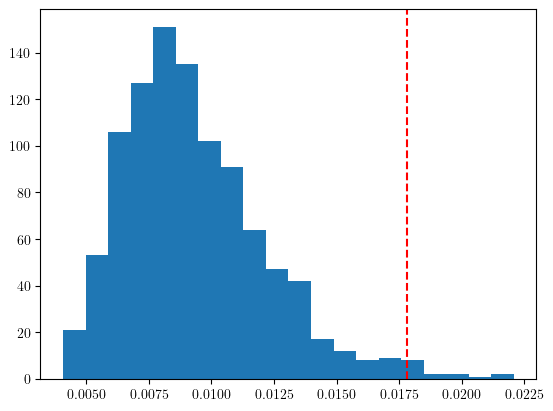

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 235.83it/s]


Seed: 10, signal_ratio: 0.0, SR_size: 0.05, noise_scale: inf
p_value: 0.058


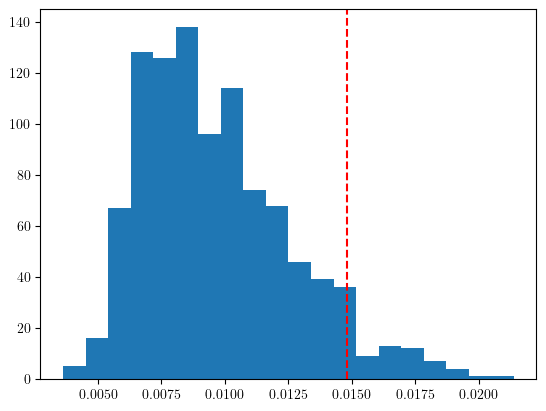

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 237.09it/s]


Seed: 11, signal_ratio: 0.0, SR_size: 0.05, noise_scale: inf
p_value: 0.242


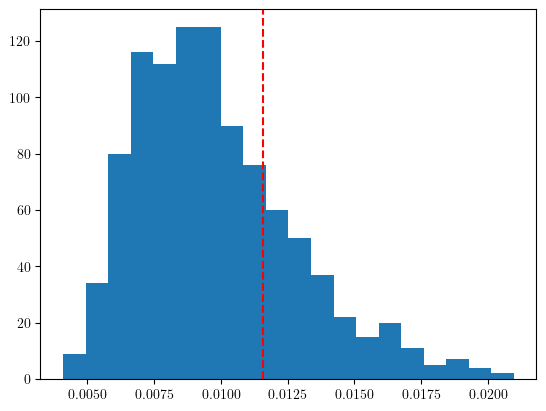

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 231.15it/s]


Seed: 11, signal_ratio: 0.0, SR_size: 0.05, noise_scale: 2.0
p_value: 0.004


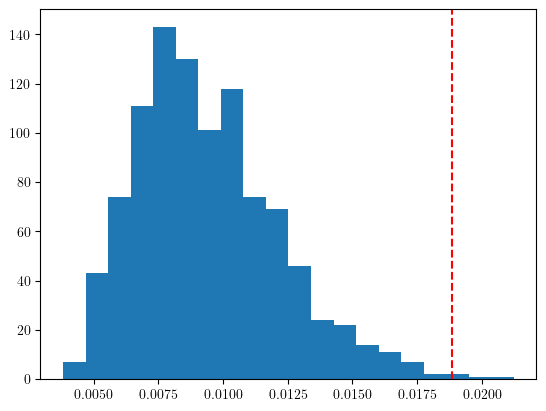

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 236.00it/s]


Seed: 12, signal_ratio: 0.0, SR_size: 0.05, noise_scale: inf
p_value: 0.002


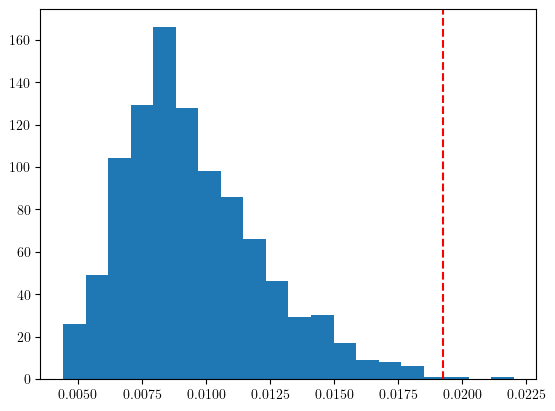

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 228.90it/s]


Seed: 12, signal_ratio: 0.0, SR_size: 0.05, noise_scale: 2.0
p_value: 0.607


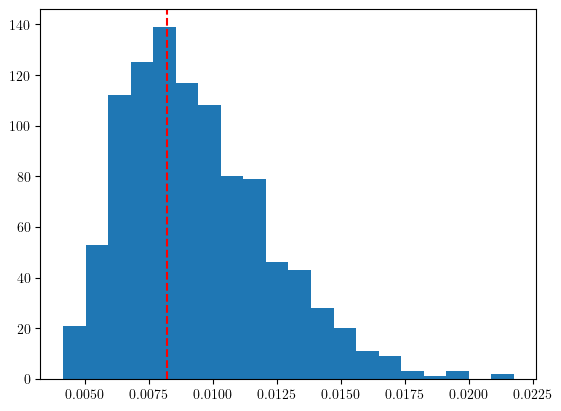

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 224.75it/s]


Seed: 13, signal_ratio: 0.0, SR_size: 0.05, noise_scale: 2.0
p_value: 0.138


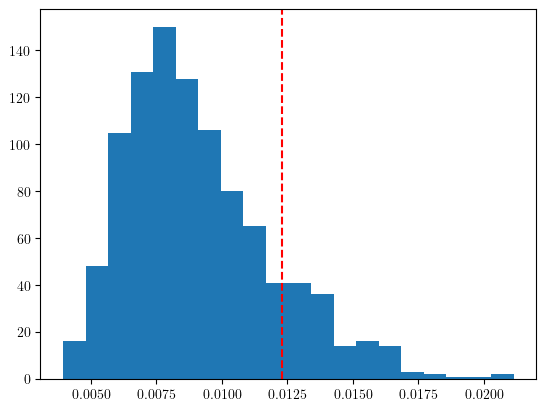

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 234.59it/s]


Seed: 13, signal_ratio: 0.0, SR_size: 0.05, noise_scale: inf
p_value: 0.027


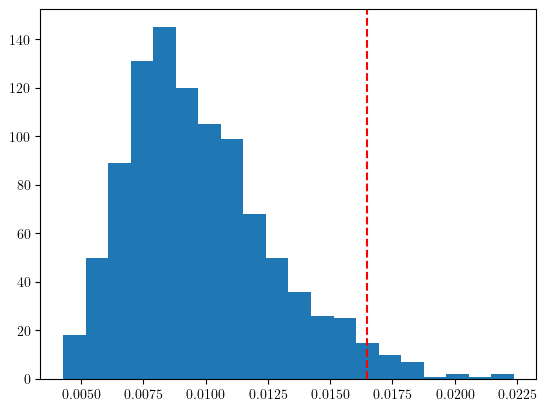

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 228.52it/s]


Seed: 14, signal_ratio: 0.0, SR_size: 0.05, noise_scale: 2.0
p_value: 0.327


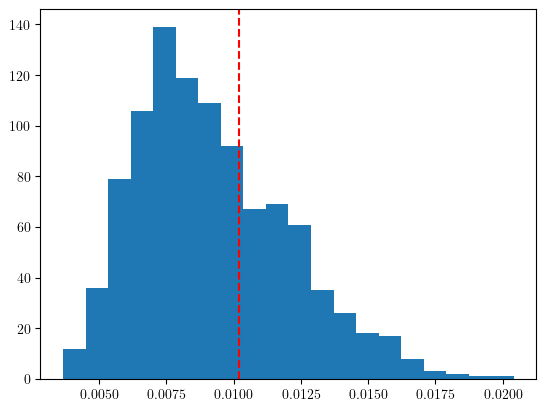

----------------------------------------------------------------------------------------------------


100%|██████████| 1000/1000 [00:04<00:00, 234.85it/s]


Seed: 14, signal_ratio: 0.0, SR_size: 0.05, noise_scale: inf
p_value: 0.527


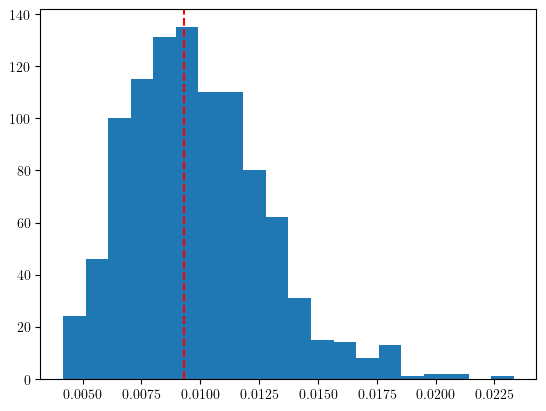

----------------------------------------------------------------------------------------------------


In [5]:
from plots import plot_cdf
from ks_test import max_cdf_diff, max_cdf_diff_permutation
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.05
sig_level = 0.05
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
seeds = [10, 11, 12, 13, 14]

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] in seeds,  
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                    return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

max_diff_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
tmp_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}
p_value_list = {noise_scale_: {"base": [], "CR": []} for noise_scale_ in noise_scales}

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    if noise_scale not in [2.0, np.inf]:
        continue
        
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
    SR_idx = SR_stats_tst >= SR_cut
    
    SR_stats_tst_SR = SR_stats_tst[SR_idx]
    events_tst_SR = events_tst[SR_idx]
    
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
    rw_tst_SR = np.where(events_tst_SR.is_4b, events_tst_SR.weights, reweights_tst_SR * events_tst_SR.weights)
    is_4b_tst_SR = events_tst_SR.is_4b
    
    x_stats_SR = SR_stats_tst_SR
    
    orig_max_diff, max_cdf_diffs, p_value = max_cdf_diff_permutation(
        x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
        rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR], do_tqdm=True, 
        resample=True, resample_ratio=1.0)
    
    print(f"Seed: {seed}, signal_ratio: {signal_ratio}, SR_size: {SR_size}, noise_scale: {noise_scale}")
    print(f"p_value: {p_value}")
    fig, ax = plt.subplots()
    ax.hist(max_cdf_diffs, bins=20)
    ax.axvline(x=orig_max_diff, color="red", linestyle="--")
    plt.show()
    print("-" * 100)